# Manuscript figures

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import seaborn as sns
import matplotlib.pyplot as plt
import pooch
import pandas as pd
from tqdm import tqdm
import numpy as np

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp
import src.analysis.distributions as db
import src.analysis.attributions as ab
import src.colabfold.colabfold as cf

import src.benchmark.clinvar as bcv

pd.set_option('display.max_columns', None)

utils.set_rcparams_nature()

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Figure 1

### Figure 1a

![](fig/fig1a.pdf)

### Figure 1b

![](fig/fig1b.pdf)

### Figure 1c

In [2]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = f"./results/data/vep_df_{model_name}.parquet"
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
else:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)
    vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"], 
                          vep_files=vep_files.loc[vep_files['model_location']==model_name]
                               )
    print(f"Saving {tmp_vep_path}")
    vep_df.to_parquet(tmp_vep_path)

vep_df.head() 

Loading ./results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:L1045F,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:D1003Y,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:N996I,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:E978K,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multip

  0%|          | 0/2525 [00:00<?, ?it/s]

Extracting ID columns.
Using default maps.
Simplifying annotations.
      ClinSig  Count       Source Variant Type   Variant Type (Source)
0      benign   2615  SpliceVarDB     Splicing  Splicing (SpliceVarDB)
1  pathogenic   3327  SpliceVarDB     Splicing  Splicing (SpliceVarDB)
2         vus   2548  SpliceVarDB     Splicing  Splicing (SpliceVarDB)
0      benign  11718      ClinVar          UTR           UTR (ClinVar)
1  pathogenic   2053      ClinVar          UTR           UTR (ClinVar)
0      benign  30727   ProteinGym     Missense   Missense (ProteinGym)
1  pathogenic  32000   ProteinGym     Missense   Missense (ProteinGym)


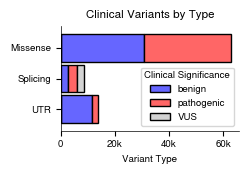

In [3]:
variant_count_by_source_barplot_out = va.variant_count_by_source_barplot(show_plot=True, 
                                            figsize=(2.5, 1.75), 
                                            flip_axes=False, 
                                            y_label=None,
                                            legend_loc="lower right")
variant_count_by_source_barplot_out["fig"].savefig("manuscript/fig/clinical_variants_by_type.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 1d

Superpopulation sample counts.

In [4]:
tx_ids_1kg = hs.list_haplotypes(cache = hs.DIR_DICT["haplotypes"])
tx_ids_hgdp = hs.list_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"])
print("tx_id union",len(set(tx_ids_1kg).union(tx_ids_hgdp)))
print("tx_id intersection",len(set(tx_ids_1kg).intersection(tx_ids_hgdp)))

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'
Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'
tx_id union 92863
tx_id intersection 39986


Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [5]:
proteins_df = pg.merge_resources(rows_per_id=None)

haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "union",
                                         use_deepcopy = True) 

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/2503 [00:00<?, ?it/s]

Using deepcopy
Merging 2847 tx_ids using union


Merging haplotype datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Merging haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Merged 132721 haplotypes across 2847 tx_ids.


Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

0 samples are missing superpopulation metadata


/home/schilder/projects/VEP_protein/src/haplosaurus.py:3458: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples_df['superpopulation_fullname'] = (


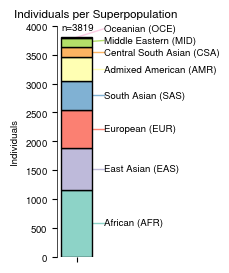

In [37]:
plot_superpopulation_bar_out = hs.plot_superpopulation_bar(haplotypes=haplotypes, figsize=(1, 3), title_y=1)
plot_superpopulation_bar_out["fig"].savefig("manuscript/fig/superpopulation_bar.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 1e

WT variants per haplotype: ESM

Plot the number of haplotypes per protein, as well as the number of WT variants per haplotype.

Adding reference haplotype:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to dataframe:   0%|          | 0/2847 [00:00<?, ?it/s]

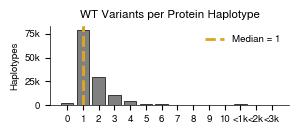

median number of variants per haplotype: 1.0
mean number of variants per haplotype: 7.615349261243342


In [18]:
n_variants_histogram_protein = hs.plot_haplotypes_summary(haplotypes, 
                                   show_median=True,
                                   show_mean=False,
                                   bar_linewidth=.5,
                                    figsize=(3, 1.35),
                                    gridspec_kw={'width_ratios': [0, 1]},
                                    bin_size=1000, 
                                     title=("Haplotypes per Protein", "WT Variants per Protein Haplotype"),
                                     xlabel=(None,None),
                                #    count_indels_as_one=True,
                                   show_subplots=(False, True),   
                                   show_bar_labels=False,
                                   save_path="manuscript/fig/wt_variants_per_haplotype_protein.pdf")

print(f"median number of variants per haplotype: {n_variants_histogram_protein['data']['hap_df']['edits'].median()}")
print(f"mean number of variants per haplotype: {n_variants_histogram_protein['data']['hap_df']['edits'].mean()}")

In [58]:
# hap_df = hs.haplotypes_to_df(haplotypes).reset_index()
# hap_df = utils.add_edits(hap_df)
# n_variants_histogram_protein = va.plot_n_variants_histogram(hap_df, 
#                                                             x="edits", 
#                                                             title="WT Variants per Protein Haplotype",
#                                                             save_path="manuscript/fig/wt_variants_per_haplotype_protein.pdf", 
#                                                             figsize=(7, 4),
#                                                             show_plot=True)

### Figure 1f

Number of WT variants per haplotype: SpliceAI

In [8]:
spliceai_n_variants_path = "results/data/spliceai_n_variants_df.parquet"
force = False

if not os.path.exists(spliceai_n_variants_path) or force:
    # NOTE: Must first activate a conda environment with genvarloader installed
    import src.GVL as GVL
    # List of GVL zip file paths
    gvl_zips = [
        os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/gvl_1kgp/1kgp_gvl.zip"),
        os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/gvl_hgdp/hgdp_gvl.zip"),
    ] 
    # Functionalized workflow
    datasets = GVL.load_gvl_datasets(gvl_zips)
    n_variants_spliceai = GVL.get_n_variants_df(datasets)
    n_variants_spliceai.to_parquet(spliceai_n_variants_path)
else:
    n_variants_spliceai = pd.read_parquet(spliceai_n_variants_path)

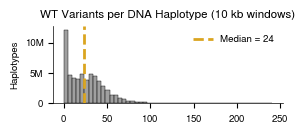

In [19]:
n_variants_histogram_spliceai = va.plot_n_variants_histogram(n_variants_spliceai, 
                                                            title="WT Variants per DNA Haplotype (10 kb windows)",
                                                            save_path="manuscript/fig/wt_variants_per_haplotype_spliceai.pdf", 
                                                            figsize=(3, 1.35),
                                                             x_label=None,
                                                             show_plot=True)

### Figure 1g

WT variants per haplotype: Flashzoi

In [11]:
flashzoi_n_variants_path = "results/data/flashzoi_n_variants_df.parquet"
force = False

if not os.path.exists(flashzoi_n_variants_path) or force:
    # NOTE: Must first activate a conda environment with genvarloader installed
    import src.GVL as GVL
    import glob
    gvl_zips = glob.glob(os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/*.gvl"))

    datasets = GVL.load_gvl_datasets(gvl_zips)
    n_variants_flashzoi = GVL.get_n_variants_df(datasets)
    n_variants_flashzoi.to_parquet(flashzoi_n_variants_path)
else:
    n_variants_flashzoi = pd.read_parquet(flashzoi_n_variants_path)

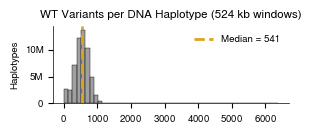

In [38]:
n_variants_histogram_flashzoi = va.plot_n_variants_histogram(n_variants_flashzoi, 
                                                            title="WT Variants per DNA Haplotype (524 kb windows)",
                                                            x_label=None,
                                                            save_path="manuscript/fig/wt_variants_per_haplotype_flashzoi.pdf", 
                                                             figsize=(3, 1.35),
                                                            show_plot=True)

## Figure 2

### Figure 2a

In [5]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"
model_name_display="ESM2-650M"

force = False
tmp_vep_path = f"./results/data/vep_df_{model_name}.parquet"
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
else:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)
    vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"], 
                          vep_files=vep_files.loc[vep_files['model_location']==model_name]
                               )
    print(f"Saving {tmp_vep_path}")
    vep_df.to_parquet(tmp_vep_path)

vep_df.head() 

Loading ./results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:L1045F,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:D1003Y,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:N996I,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:E978K,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multip

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


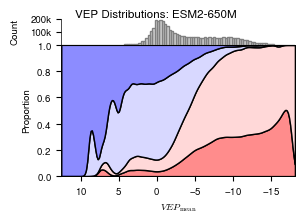

In [6]:
# vep_dist_plot_esm2 = db.plot_vep_histogram_with_arrows(vep_df,  
#                                         #   model_name=model_name,  
#                                           arrow_y= -0.35,
#                                           arrow_head_length=0.047,
#                                           arrow_length=.19,
#                                           figsize=(8, 4),
#                                           arrow_text_fontsize=9,
#                                            format_k=True,
#                                            k_precision=1,
#                                            suffix=None,
#                                            legend_loc="upper right",
#                                          title=f"VEP Distributions: {model_name}",
#                                           external_legend_annotation=False)
# vep_dist_plot_esm2["fig"].savefig("manuscript/fig/fig1h.png", **utils.FIG_SAVE_KWARGS)

import src.analysis.distributions as db
vep_dist_plot_esm2 = db.plot_vep_kde_with_arrows(
    vep_df=vep_df, 
    figsize=(3, 2.5),
    flip_xaxis=True,
    add_histogram=True,
    format_k=True, 
    title_y=.82,
    height_ratios=(.2,1), 
    hist_kwargs={"bins":100,"edgecolor":"grey"},
    vline_kwargs=None,
    legend_loc=None,
    # arrow_kwargs={"y_arrow_offset":0.22, "y_label_offset":0.04},
    arrow_kwargs=None,
    title=f"VEP Distributions: {model_name_display}",
    save_path="manuscript/fig/vep_kde_esm2.pdf"
)

### Normality tests

In [51]:
groupby_cols = ['model_location','protein','clinsig','mutant','site','scoring_strategy']
normality_results = db.test_normality(vep_df,
                                      min_n=20,
                                      groupby_cols=groupby_cols,
                                      save_path='results/normality_results.parquet')
normality_results.head()

Loading cached normality results


metric,model_location,protein,clinsig,mutant,site,scoring_strategy,n_samples,pvalue,statistic
0,esm2_t33_650M_UR50D,NP_000007.1,benign,C159W,NP_000007.1:C159W,masked-marginals,26.0,0.288377,2.486977
1,esm2_t33_650M_UR50D,NP_000007.1,likely_benign,M87I,NP_000007.1:M87I,masked-marginals,26.0,0.000002,25.841743
2,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A113T,NP_000007.1:A113T,masked-marginals,26.0,0.008392,9.560975
3,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A165T,NP_000007.1:A165T,masked-marginals,26.0,0.000017,21.954090
4,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A81T,NP_000007.1:A81T,masked-marginals,26.0,0.001276,13.327450


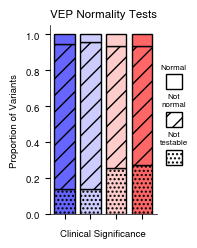

Total proteins: 2250
Total sites: 56364
Sites with normal distribution (Testable): 45089.03316213845 (80.00%)
Sites with normal distribution (True): 3178.2121221624743 (5.64%)
Sites with non-normal distribution: 41910.82103997596 (74.36%)


In [52]:
# Legend configuration: 'top' for horizontal legend at top, 'right' for vertical legend on right
LEGEND_POSITION = 'right'  # Change to 'right' for vertical legend on the right

fig_normality = db.plot_test_normality(normality_results, 
                                title=f"VEP Normality Tests",
                                legend_position=LEGEND_POSITION,
                                legend_title=None, 
                                show_xticklabels=False,
                                figsize=(2, 2.5),  
                                legend_left=True,
                                xtick_rotation=45,
                                )
fig_normality['fig'].savefig("manuscript/fig/normality_tests.pdf", **utils.FIG_SAVE_KWARGS)

### Modality tests

Estimate the modallity for each VEP distribution.

In [53]:
vep_ecdf = db.estimate_modality(
    vep_df=vep_df,  
    save_path='results/data/vep_ecdf.parquet',
    # save_path=None,
    min_haplotypes=20, 
    bgm_kwargs = {
            # "weight_concentration_prior_type": "dirichlet_process",
            # "weight_concentration_prior": 0.8,
            "max_iter": 1000,
            # "covariance_type": "spherical",
            "init_params": "k-means++",
            },
    error=True,
    # force=True
    )  

# fig_modality = db.plot_estimate_modality(vep_ecdf,
#                                     title=f"VEP Modality: {model_name}",
#                                     min_haplotypes=20, 
#                                     figsize=(6, 4))

vep_ecdf["n_peaks"].min(),  vep_ecdf["n_peaks"].max(), vep_ecdf["n_peaks"].median()

Loading cached ECDF data
(4595700, 21)


(np.int64(1), np.int64(6), np.float64(2.0))

Remaining sites @ n_haplotypes >= 20: 43710 / 45957 = 95.1106469091%


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  fig.canvas.print_figure(bytes_io, **kw)


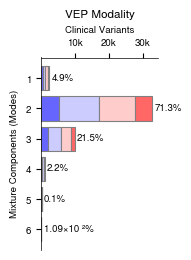

/home/schilder/.cache/tmp/ipykernel_588332/2393408993.py:8: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  fig_modality['fig'].savefig("manuscript/fig/modality_estimates.pdf", **utils.FIG_SAVE_KWARGS)


clinsig,n_peaks,benign,likely benign,likely pathogenic,pathogenic,total
0,1,328,635,882,402,2247
1,2,5185,11799,10868,4935,32787
2,3,1813,4133,2713,1202,9861
3,4,179,447,247,126,999
4,5,11,32,11,4,58
5,6,2,2,1,0,5


In [54]:
fig_modality = db.plot_estimate_modality(vep_ecdf,
                                    title=f"VEP Modality",
                                    min_haplotypes=20,  
                                    flip_axes=True,
                                    show_percentages=True, 
                                    show_legend=False,
                                    figsize=(1.5, 2.5))
fig_modality['fig'].savefig("manuscript/fig/modality_estimates.pdf", **utils.FIG_SAVE_KWARGS)
peak_counts = fig_modality['data'].reset_index()
peak_counts

In [110]:
peak_counts.loc[peak_counts['n_peaks']>1]['total'].sum()

np.int64(43710)

In [111]:
# Proportion of variants with >1 peak
100-peak_counts.loc[peak_counts['n_peaks']==1]['total'].sum() / peak_counts['total'].sum()*100

np.float64(95.11064690906717)

In [112]:
# Proportion of all variants tested for modality
fig_modality['data']['total'].sum()/vep_df['site'].nunique()*100

np.float64(81.53608686395572)

### Figure 2b

Compute Median Absolute Deviation (MAD).

In [7]:
from statsmodels import robust

tqdm.pandas()
vep_df["GENE"] = vep_df["GENEINFO"].str.split(":").str[0]
mad_df = vep_df.groupby(["model_location", "scoring_strategy", "protein","GENE", "mutant", "site","clinsig"], observed=True).progress_apply(
    lambda x: robust.mad(x["VEP"], c=1)
).reset_index().rename(columns={0:"MAD"}).sort_values(by="MAD", ascending=False)

100%|█████████▉| 56244/56364 [00:08<00:00, 9191.98it/s]/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 56364/56364 [00:08<00:00, 6829.47it/s]


In [8]:
top_n=50
mad_df_top_n = mad_df[:top_n]
print(len(mad_df_top_n.loc[mad_df_top_n["GENE"]=="VHL"]))
print(len(mad_df_top_n.loc[mad_df_top_n["GENE"]=="VHL"]) / len(mad_df_top_n))
# vhl_df = va.compute_representativeness_stats(vep_df.loc[(vep_df["GENE"]=="VHL")].copy(), is_ref=False)
# vhl_df["VEP_REF_ratio"] = vhl_df["VEP_REF"] / vhl_df["VEP_mean"]

41
0.82


In [9]:
n_facets_final = 20
n_facets_init = n_facets_final*2
top_n_mad_genes = 20
gene_col = "protein"

# Add number of haplotypes per protein/mutant
if "n_haplotypes" not in vep_df.columns:
    vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy","protein", "mutant"])["haplotype"].transform("nunique")



# Filter to sites with sufficient haplotypes and not in VHL
no_no_genes  = ["RPGRIP1","PRNP"] 
pos_diff_sites = vep_df.loc[(vep_df["n_haplotypes"] > 10) & (~vep_df["GENE"].isin(no_no_genes)), 'site'].unique()

# Subset mad_df to those sites
filtered_mad_df = mad_df.loc[(mad_df["site"].isin(pos_diff_sites))]

# For each gene, select the variant (site) with the highest MAD
top_mad_per_gene = (
    filtered_mad_df.sort_values("MAD", ascending=False)
    .drop_duplicates(subset=gene_col, keep="first")
)
top_genes = top_mad_per_gene[gene_col][:top_n_mad_genes]

# Select up to n_facets top variants (one per gene)
target_sites = top_mad_per_gene.iloc[:n_facets_init]["site"]
plot_df = vep_df.loc[vep_df[gene_col].isin(top_genes)].copy()

if "VEP_REF" not in plot_df.columns:
    plot_df["is_ref"] = plot_df["haplotype"].str.endswith(":REF")
    plot_df = va.compute_representativeness_stats(plot_df, is_ref=False)

import src.analysis.vep_gmm as gmm
gmm_df = gmm.train_vep_gmm(plot_df)
boundary_crossing_df = gmm.get_decision_boundaries(gmm_df, plot_df, plot=False)
boundary_crossing_df["site"] = boundary_crossing_df["protein"]+":"+boundary_crossing_df["mutant"]

plot_df = plot_df.loc[plot_df[gene_col].isin(boundary_crossing_df[gene_col].unique())]
plot_df = plot_df.loc[plot_df["site"].isin(top_mad_per_gene["site"].unique())]

final_site_selection = plot_df["site"].unique()[:n_facets_final] 

Computing representativeness stats for VEP_percentile


Training GMMs: 100%|██████████| 20/20 [00:00<00:00, 51.45it/s]


Total model-protein-scoring combinations with GMM models: 20
Average accuracy: 0.3027
Average AUC: 0.8483
Error plotting ('esm2_t33_650M_UR50D', 'NP_954986.2', 'masked-marginals'): 'model'


Finding boundary-crossing variants: 100%|██████████| 542/542 [00:00<00:00, 10228.31it/s]

Adding crossing proportion
No variants found that cross decision boundaries in different haplotypes


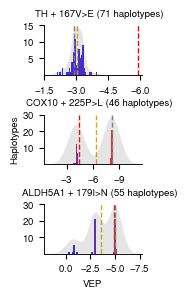

In [10]:

top_mad_sites = gmm.plot_vep_histograms_with_boundaries(vep_df=plot_df,
                                                        boundary_crossing_df=boundary_crossing_df,
                                                        target_sites=final_site_selection[[2,5,1]],  
                                                        facet_height= 1,
                                                        facet_aspect=1.6,
                                                         facet_title_x=0.57,
                                                        show_twinx_labels=False,

                                                        show_superpops=False,
                                                        superpop_height_ratio=0.2,  # Make superpop bars 20% of main plot height
                                                        superpop_default_bins=20,
                                                        superpop_legend_row=1,
                                                        facet_row_spacing=.8,#0.6, 
                                                        
                                                        format_variant_p_notation=True,
                                                        show_superpop_legend_title=False,
                                                        superpop_legend_border=True,
                                                        superpop_legend_border_padding=(0.01, 0.01, 0.0001, 0.01), 
                                                        title=None,

                                                        sharex=False,
                                                        sharey=False,
                                                          col_wrap=1, 
                                                          flip_xaxis=True,
                                                          palette=["red","blue"],
                                                        bins=30,
                                                        n_xticks=4,
                                                        n_yticks=4,
                                                        show_vertical_lines=True,
                                                        show_vertical_line_labels=False,
                                                        shared_yaxis_label=True
                                                        )
top_mad_sites["fig"].savefig("manuscript/fig/esm2_boundaries_top_mad.pdf", **utils.FIG_SAVE_KWARGS)

VHL examples only

Adding haplotype frequencies to extract superpopulation data...


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using all 3 cohorts.
Using 38 populations
Adding haplotype frequencies per population
Adding top superpopulation
0 samples are missing superpopulation metadata
0 samples are missing superpopulation metadata

Number of variants specific to each population:
specific_population
1000GENOMES:phase_3:LWK    2
1000GENOMES:phase_3:GBR    1
GGVP:GWF                   1
1000GENOMES:phase_3:CHS    1
1000GENOMES:phase_3:YRI    1
1000GENOMES:phase_3:ACB    1
1000GENOMES:phase_3:CLM    1
1000GENOMES:phase_3:IBS    1
Name: count, dtype: int64

Percentage of population-specific haplotypes: 69.23%
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
1000GENOMES:phase_3:AFR    5
1000GENOMES:phase_3:EUR    2
1000GENOMES:phase_3:EAS    1
1000GENOMES:phase_3:AMR    1
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 69.23%


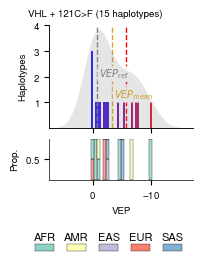

In [16]:
superpop_height_ratio=0.5
top_mad_sites = gmm.plot_vep_histograms_with_boundaries(vep_df=plot_df,
                                                        boundary_crossing_df=boundary_crossing_df,
                                                        target_sites=target_sites[:1],  
                                                        facet_height= 3.5*superpop_height_ratio,
                                                        facet_aspect=1,
                                                         show_twinx_labels=False,
                                                         facet_title_x=0.32,
                                                         superpop_legend_bottom=True,

                                                        show_superpops=True,
                                                        superpop_height_ratio=superpop_height_ratio,  
                                                        superpop_default_bins=20,
                                                        superpop_legend_row=5,
                                                        superpop_legend_x=.3,
                                                        superpop_legend_y=-0.35,
                                                        facet_row_spacing=0.6,
                                                        
                                                        format_variant_p_notation=True,
                                                        show_superpop_legend_title=False,
                                                        superpop_legend_border=False,
                                                        label_yspacing=0.2,
                                                        # superpop_legend_border_padding=(0.02, 0.01, 0.0001, 0.01),
                                                        title=None,

                                                        sharex=False,
                                                        sharey=False,
                                                          col_wrap=2, 
                                                          flip_xaxis=True,
                                                          palette=["red","blue"],
                                                        bins=30
                                                        )
top_mad_sites["fig"].savefig("manuscript/fig/esm2_boundaries_VHL.pdf", **utils.FIG_SAVE_KWARGS)

Cartoon distributions for inset

In [408]:
top_n_variants = 5000

# Add number of haplotypes per protein/mutant
if "n_haplotypes" not in vep_df.columns:
    vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy","protein", "mutant"])["haplotype"].transform("nunique")


n_peaks = vep_ecdf[["protein","mutant","site","n_peaks"]].drop_duplicates()

mad_peaks = vep_df.loc[vep_df["site"].isin(mad_df.head(top_n_variants)["site"])].merge(n_peaks, on=["protein","mutant","site"])

if "VEP_REF" not in mad_peaks.columns:
    mad_peaks["is_ref"] = mad_peaks["haplotype"].str.endswith(":REF")
    mad_peaks = va.compute_representativeness_stats(mad_peaks, is_ref=False)

import src.analysis.vep_gmm as gmm
gmm_df = gmm.train_vep_gmm(mad_peaks)
boundary_crossing_df = gmm.get_decision_boundaries(gmm_df, mad_peaks, plot=False)
boundary_crossing_df["site"] = boundary_crossing_df["protein"]+":"+boundary_crossing_df["mutant"]
boundary_crossing_df = boundary_crossing_df.merge(n_peaks, on=["protein","mutant","site"])


NameError: name 'vep_ecdf' is not defined

In [25]:
boundary_crossing_df.sort_values("n_peaks").groupby("n_peaks").head(2)

,protein,mutant,clinsig,decision_boundary,min_vep,max_vep,vep_range,haplotype_count,scores_above_boundary,scores_below_boundary,crossing_proportion,site,n_peaks
5,NP_000039.2,R146W,path,-6.358387,-6.652295,-6.329348,0.322947,26,3,23,0.115385,NP_000039.2:R146W,1
9,NP_000068.1,R87P,path,-6.510664,-6.915729,-6.345154,0.570575,24,4,20,0.166667,NP_000068.1:R87P,1
4,NP_000017.1,R396C,likely_path,-8.575534,-8.671629,-7.873710,0.797919,25,23,2,0.080000,NP_000017.1:R396C,2
3,NP_000017.1,R303C,likely_path,-8.575534,-8.721643,-8.097470,0.624173,25,11,14,0.440000,NP_000017.1:R303C,2
124,NP_000503.1,T206P,likely_path,-4.639877,-8.891619,-4.468173,4.423446,71,1,70,0.014085,NP_000503.1:T206P,3
123,NP_000503.1,H142L,likely_path,-4.639877,-6.150982,-4.354972,1.796010,71,1,70,0.014085,NP_000503.1:H142L,3


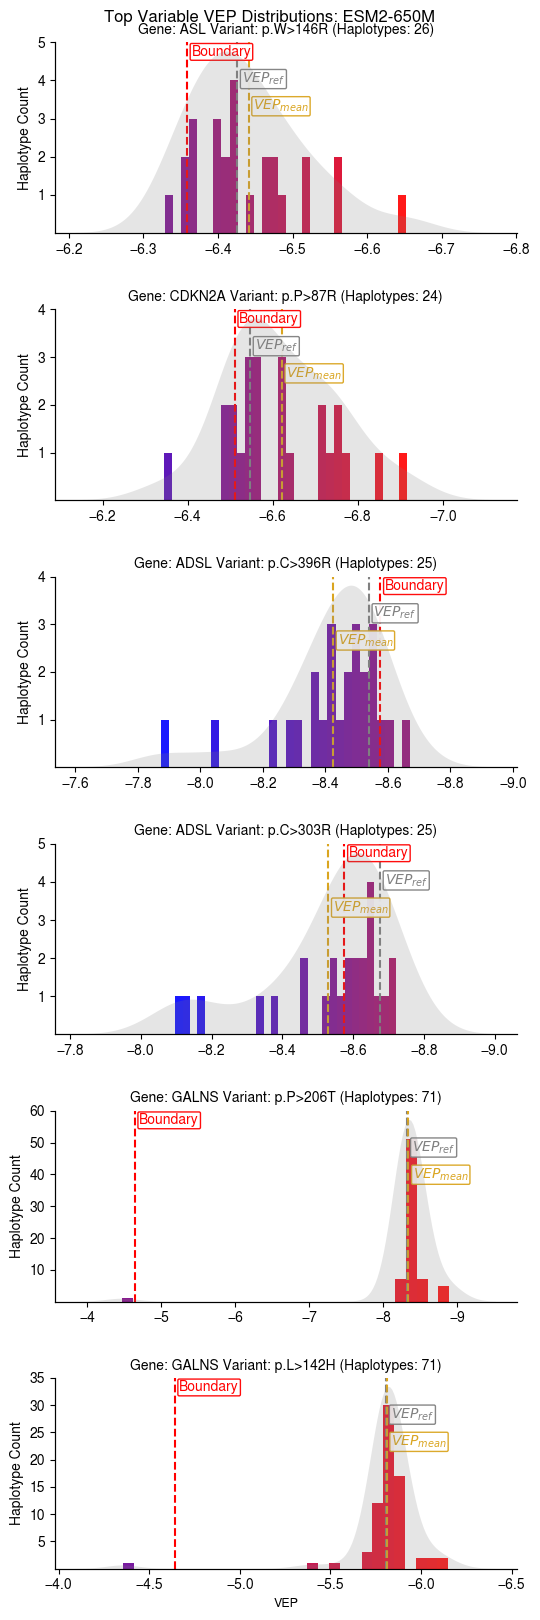

In [31]:
top_mad_sites = gmm.plot_vep_histograms_with_boundaries(vep_df=mad_peaks,
                                                        boundary_crossing_df=boundary_crossing_df,
                                                        target_sites=boundary_crossing_df.sort_values("n_peaks").groupby("n_peaks")["site"].head(2).tolist(),  
                                                        facet_height= 2.75,
                                                        facet_aspect=2,
                                                        show_twinx_labels=False, 
                                                        x_offset=.01,

                                                        show_superpops=False,
                                                        # superpop_height_ratio=0.2,  # Make superpop bars 20% of main plot height
                                                        # superpop_default_bins=20,
                                                        # superpop_legend_row=1,
                                                        # facet_row_spacing=0.6,
                                                        
                                                        format_variant_p_notation=True,
                                                        show_superpop_legend_title=False,
                                                        superpop_legend_border=True,
                                                        superpop_legend_border_padding=(0.02, 0.01, 0.0001, 0.01),
                                                        title="Top Variable VEP Distributions: ESM2-650M",

                                                        sharex=False,
                                                        sharey=False,
                                                          col_wrap=1, 
                                                          flip_xaxis=True,
                                                          palette=["red","blue"],
                                                        bins=30
                                                        )
top_mad_sites["fig"].savefig("manuscript/fig/esm2_boundaries_top_mad.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 2c

Toy schematic of variant sensitization maps methodology (ridge regression method).

In [68]:
uniprot_ids = {"BRCA1":"P38398", 
               "DYPD":"Q12882"}
tx_ids = {"BRCA1":"ENST00000357654", 
          "DYPD":"ENST00000370192"}
refseq_ids = {"BRCA1": 'NP_009225.1',
              "DYPD": 'NP_000101.2'}

# Get specific instance of the protein
target_gene = "BRCA1" # DYPD
uniprot_id = uniprot_ids[target_gene]
refseq_id = refseq_ids[target_gene]
tx_id = tx_ids[target_gene] 

In [69]:
#### Import directly from AlphaFoldDB ####
# structure = cf.import_mmcif(protein_id = uniprot_id)[0]
# contact_map = cf.get_contact_map(structure, 
#                                  max_distance=8.0, 
#                                  continuous=True, 
#                                  return_distance_map=True )


#### Import from local AlphaFold files that I generated myself ####
pdb_files_ref = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1,
                            ref_only = True) 

# contact_map_ref = cf.import_contact_maps(pdb_files,
#                                         return_distance_map=True,
#                                         continuous=True,
#                                         as_dict=False)  


distance_map_ref = cf.import_contact_maps(pdb_files_ref,
                                            return_raw_distance_map=True,
                                            as_dict=False)  


/home/schilder/projects/VEP_protein/src/colabfold/colabfold.py:1566: UserWarning: Multiple keys found in contact_maps with pattern 'REF' in basename: ['/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_REF_unrelaxed_rank_002_alphafold2_ptm_model_1_seed_000.pdb.gz', '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_REF_unrelaxed_rank_002_alphafold2_ptm_model_1_seed_000.pdb']. Using the last match.
  warnings.warn(


1 PDB files found


100%|██████████| 1/1 [00:00<00:00,  4.95it/s]


Contact enrichment for BRCA1 WT vs. Clinical variant interactions.

In [70]:
contact_map_binary_ref = cf.import_contact_maps(pdb_files_ref,
                                                max_distance=8.0, 
                                                continuous=False, 
                                                return_distance_map=False,
                                                as_dict=False ) 

100%|██████████| 1/1 [00:00<00:00,  5.06it/s]


In [71]:
model_name = "esm2_t33_650M_UR50D"
force = False

if 'vep_files' not in globals() or force:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)

vep_prot = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']==model_name) & 
                            (vep_files['protein']==refseq_id)]
    )
print("n_haplotypes: ", vep_prot["haplotype"].nunique())
vep_prot["HGNC"] = vep_prot["GENEINFO"].str.split(":").str[0]  


No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 202449 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 1
scoring_strategy: 3
variant_set: 1
haplotype: 111378
protein: 2250
No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 144 masked-marginals parquet files


Reading files:   0%|          | 0/144 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 4.54GB/s]


VEP dataframe shape: (65664, 73)
n_haplotypes:  144


Use ridge regression to find WT-Clinical variant interactions.

In [72]:
wtvariants_to_vep_linear_model_save_path = f"results/data/wtvariants_to_vep_linear_model_out_{target_gene}.pkl"
if os.path.exists(wtvariants_to_vep_linear_model_save_path):
        print(f"Loading {wtvariants_to_vep_linear_model_save_path}")
        wtvariants_to_vep_linear_model_out = utils.load_pickle(wtvariants_to_vep_linear_model_save_path)
else:
        wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(
                vep_df=vep_prot,
                test_epistasis=True,     
                alpha=1)  
        utils.save_pickle(wtvariants_to_vep_linear_model_out, 
                wtvariants_to_vep_linear_model_save_path
                )

ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]
print(wtvariants_to_vep_linear_model_out["epistasis_results"])
wtvariants_to_vep_linear_model_out["metrics"]

Loading results/data/wtvariants_to_vep_linear_model_out_BRCA1.pkl
Loading ==> results/data/wtvariants_to_vep_linear_model_out_BRCA1.pkl


Loading 'results/data/wtvariants_to_vep_linear_model_out_BRCA1.pkl': 100%|██████████| 14.6M/14.6M [00:00<00:00, 2.29GB/s]

{'n_tested': 59280, 'n_epistatic': 652, 'n_additive': 58628, 'epistasis_rate': 0.010998650472334682, 'mean_delta_r2_epistatic': np.float64(0.07319226018037023), 'mean_delta_r2_additive': np.float64(0.0008702463248580554), 'mean_epistasis_coefficient': np.float64(0.0)}


,R2,Explained Variance,MSE,RMSE,MAE
0,0.829539,0.829539,0.000164,0.01282,0.003973


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Found 4x5 submatrix at rows 0-4, cols 125-130 with 25.0% 1s


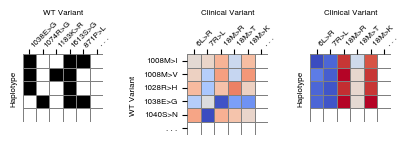

<Figure size 330x250 with 0 Axes>

In [141]:
surrogate_model_schematic = ab.plot_variant_sensitization_schematic(
    wtvariants_to_vep_linear_model_out,
    
    # --- Figure/layout options ---
    figsize=(3.5, 1.5),
    subplot_space_x=(0.24, .12),
    ticklabel_fontsize='small',
    xlabel_fontsize='small',
    ylabel_fontsize='small',
    xlabel_pad=0.01,
    heatmap_aspect=(1, 1, 1),
    rotate_x_labels=True,
    title_y_position=0.95,
    add_grey_box=False, 
    
    # --- Data/sample configuration ---
    n_clinical_variants=5,
    n_haplotypes=4,
    n_wt_variants=5,
    
    # --- Plot presentation options ---
    plot_order=[0, 2, 1],
    plot1_title=None,
    plot2_title=None,
    plot3_title=None,
    plot1_kwargs={"yticklabels": []},
    plot2_kwargs={"yticklabels": []},  
    
    show_text_labels=(False, False, False),
    show_wt_labels_plot3=True,
    noise_scale=0.40,
    
    # --- Arrow/annotation controls ---
    show_train_predictor_arrow=False,              # Hide "Train Predictor" arrows
    show_extract_coefficients_arrow=False,         # Hide "Extract Coefficients" arrows

    # --- Table/label inclusion options ---
    as_formula=False,
    include_haplotype_suffix=False,
    replace_haplotype_prefix=True,
    include_any_1_col=True,
    include_any_1_row=False
)

surrogate_model_schematic['fig'].savefig(
    "manuscript/fig/surrogate_model_schematic.pdf", **utils.FIG_SAVE_KWARGS
)
surrogate_model_schematic['fig']

/home/schilder/projects/VEP_protein/src/analysis/attributions.py:4692: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_kde.legend().remove()
/home/schilder/projects/VEP_protein/src/analysis/attributions.py:4909: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


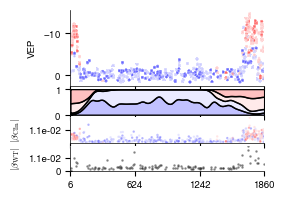

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [133]:
plot_vep_scatter_kde_out = ab.plot_vep_scatter_kde(
    vep_prot, 
    s=3,
    # title_y=0.92,
    bottom_x_label=None,
    ridge_df=ridge_df, 
    figsize=(2.5, 2.1),
    title=None,
    show_legend=False
)

fig = utils.rasterize_figure(plot_vep_scatter_kde_out['fig'])
fig.savefig("manuscript/fig/brca1_vep_position_scatter_kde.pdf", **utils.FIG_SAVE_KWARGS)

Visualize interactions in 3D

In [42]:
import src.colabfold.nglview as nv 

ngl_view_widget = nv.visualize_interactions_on_structure(
    pdb_files_ref,
    ridge_df,#.loc[ridge_df["is_epistatic"]],
    vep_prot,
    label_pos=[1684,1687,1706, 1710, 1729,1722],
    n_top_pairs=100,
    include_all_labeled_pairs=True,
    filter_interactions=lambda df: df["is_epistatic"] == True,
    sort_interactions="abs(deviation_from_additive)",  # Sort by absolute magnitude
    struct_label="protein"
)

# Save to HTML file for GitHub Pages hosting
nv.write_html(ngl_view_widget, "app/sensitization_maps/BRCA1_AF2.html", frame_range=None)

# Show
ngl_view_widget

Interaction Visualization Report
Total WT variants:        106
Total clinical variants:  364
Total interactions:       652
Filtering applied:        Yes
Original interactions:    60192
Filtered interactions:    652 (1.1%)
Include labeled pairs:     Yes (label_pos: 6 positions)


/home/schilder/projects/VEP_protein/src/colabfold/nglview.py:314: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled_pairs['_pair_id'] = (


Pairs being visualized:    101
  - Top pairs:             100
  - Labeled pairs added:   1


NGLWidget()

### Figure 2B

BRCA1 AlphaFold contact map (reference sequence).

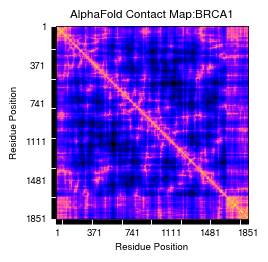

In [16]:
plot_contact_map_out = cf.plot_contact_map(contact_map=distance_map_ref, 
                            title=f"AlphaFold Contact Map:{target_gene}",  
                            bin_size=10,   
                            cmap="gnuplot2_r", 
                            pow=1/2, 
                            agg_func=np.nanmax)

distance_map_ref_binned = plot_contact_map_out["data"]["contact_map_binned"]
distance_map_ref_binned = cf.mc.expand_matrix(distance_map_ref_binned, 
                                      target_size=distance_map_ref.shape) 
plot_contact_map_out['fig'].savefig("manuscript/fig/brca1_distance_map.pdf", **utils.FIG_SAVE_KWARGS)

In [73]:
#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1 ) 

contact_maps = cf.import_contact_maps(pdb_files,
                                        return_raw_distance_map=True
                                        )  

128 PDB files found


  0%|          | 0/128 [00:00<?, ?it/s]

100%|██████████| 128/128 [00:30<00:00,  4.21it/s]


In [74]:
top_wt_variants = ridge_df.groupby("wt_variant")["interaction_strength"].mean().sort_values(ascending=False)
contact_maps_wt = {k:v for k,v in contact_maps.items() if top_wt_variants.index[0].replace(">","_") in k or k==cf.get_ref_key(contact_maps)}
top_wt_variants.head()

/home/schilder/projects/VEP_protein/src/colabfold/colabfold.py:1566: UserWarning: Multiple keys found in contact_maps with pattern 'REF' in basename: ['/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_REF_unrelaxed_rank_002_alphafold2_ptm_model_1_seed_000.pdb.gz', '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_REF_unrelaxed_rank_002_alphafold2_ptm_model_1_seed_000.pdb']. Using the last match.
  warnings.warn(


wt_variant
1710G>R    0.022135
1706G>A    0.018714
1783M>T    0.017807
616delS    0.016924
1652M>I    0.013827
Name: interaction_strength, dtype: float64

<string>:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


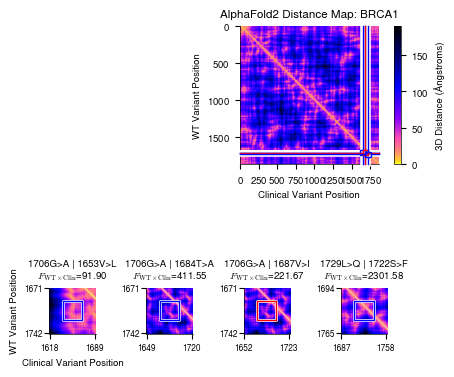

In [90]:
distance_map_zooms = cf.plot_contact_map_and_zooms(
    # Core (data) arguments
    contact_maps_wt,
    ridge_df.loc[ridge_df["is_epistatic"]],
    
    # --- Highlight/zoom configuration ---
    max_highlights=4,
    highlight_size=70,                         # Reduced from 100 (smaller highlights)
    zoom_effect_label_prefix=r"$F_{\text{WT} \times \text{Clin}}$",
    zoom_value_col="epistasis_fstat",
    zoom_color_col="interaction_strength_signed",
    zoom_sort_col="interaction_strength",
    pow=1/2,

    # --- Zoom plot arguments ---
    zoom_nrows=1,
    zoom_ncols=None,
    zoom_subplot_size=2,                       # Reduced from default (smaller zoom plots)
    zoom_show_xlabel=[True, False, False],
    zoom_show_ylabel=[True, False, False],
    zoom_show_ticks=True,
    zoom_tick_density=2,                       # Reduced from 3 (fewer ticks for cleaner look)
    zoom_highlight_marker_scale=1,
    zoom_highlight_linewidth=1,                # Reduced from 3
    zoom_highlight_white_linewidth=2,          # Reduced from 5
    zoom_rect_white_outline_width=0.25,
    zoom_rect_white_outline=False,
    zoom_hspace=1,                           # Increased from 0.5 (more vertical spacing)
    zoom_wspace=0.01,                          # Reduced from 0.1

    # --- Main plot arguments ---
    main_nrows=1,
    main_ncols=3,
    main_plot_above=True,
    main_padding_v=0,                       # Reduced from 0.05
    main_padding_h=0,                          # Was 1; now more compact
    linewidth=1,
    title=f"AlphaFold2 Distance Map: {target_gene}",

    # --- Style / figure layout ---
    white_border=True,
    white_border_width=0.1,
    figsize=(5, 4),
    save_path="manuscript/fig/brca1_distance_map_zooms.pdf"
)

### Figure 2C

BRCA1 sensitization map (aligned) +  BRCA1 AlphaFold contact map (reference sequence).

Choose a threshold for the interaction strength and compute the contact enrichment at that specific threshold.  
Then plot the contact map and the sensitization map.

In [75]:
interaction_threshold = 0.05

top_interactions = ridge_df.loc[ridge_df["interaction_strength"] > interaction_threshold]    

ridge_enrichment_at_threshold = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[interaction_threshold],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

print()
print(f"Number of top interactions: {top_interactions.shape[0]}" + \
      f" ({top_interactions.shape[0] / ridge_df.shape[0]*100:.2f}% of all WT-Clinical variant pairs)")
print(f"Enrichment at threshold {interaction_threshold}: {ridge_enrichment_at_threshold['enrichment'].values[0]:.2f}x" )

100%|██████████| 1/1 [00:00<00:00, 24.90it/s]


Number of top interactions: 518 (0.86% of all WT-Clinical variant pairs)
Enrichment at threshold 0.05: 58.58x


In [76]:
vep_prot.loc[(vep_prot["site"].isin(top_interactions["site"].head(10)))].groupby("site")["VEP"].mean().sort_values(ascending=False)
# vep_prot.loc[vep_prot["site"]=="NP_009225.1:V1687I"]["VEP"].hist(bins=50)

Series([], Name: VEP, dtype: float64)

Adding rectangles


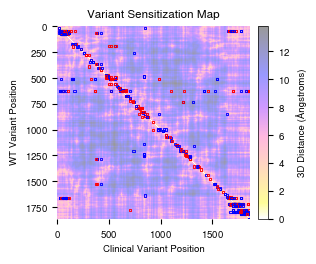

In [47]:
fig2c = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=distance_map_ref,
    # contact_map_binned=(distance_map_ref_binned >= 8).astype(int),
    # outlier_sig=top_interactions.loc[top_interactions["is_epistatic"]],
    outlier_sig=ridge_df.loc[ridge_df["is_epistatic"]],
    cmap=("gnuplot2_r", "gnuplot2_r"),
    pow2=1/2,
    heatmap_alpha=0.4,
     rectangles_alpha=.9,
     rectangles_linewidth=.75,
    masking_percentile2=None,
    invert_mask=True,
    rectangles_cmap={"more pathogenic": "red", "more benign": "blue", "neutral": "grey"},
    title=rf"Variant Sensitization Map",# +"\n"+rf"(Interaction Strength $\geq$ {interaction_threshold})",
    show_plot=(False, True),
    figsize=(2.76, 2.5)
)

fig2c["fig"]["subplot2"].savefig("manuscript/fig/brca1_sensitization_map.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 2D

Contact enrichment: ridge regression method

In [77]:
ridge_enrichment = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    num_thresholds=50,
    linear_sampling=False,  
    # interaction_col="interaction_strength"
    interaction_col="epistasis_fstat"
)

100%|██████████| 50/50 [00:02<00:00, 17.76it/s]


### Figure 2E

Mean interaction strength per clinical variant.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


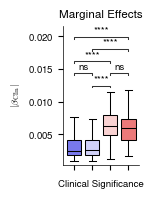

In [89]:
fig2e = ab.plot_clinsig_interaction_strength(
    ridge_df, vep_prot, 
    # y="epistasis_fstat",
    title="Marginal Effects",
    # xlabel=None,
    ylabel=r"$|\beta_{\text{Clin}}|$", 
    text_format="star",
    figsize=(1.5, 2),
    xtick_rotation=45,
    break_xtick_labels=True,
    hide_xtick_labels=True,
    show_legend=False,
)
fig2e["fig"].savefig("manuscript/fig/brca1_marginal_effects_per_clinical_variant.pdf", **utils.FIG_SAVE_KWARGS)

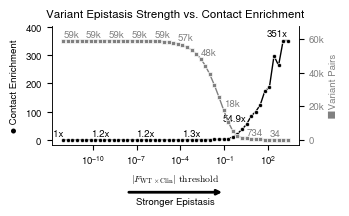

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [80]:
fig2d = ab.plot_enrichment_vs_interactions(ridge_enrichment,   
                                           figsize=(3.5, 2.5),
                                           title="Variant Epistasis Strength vs. Contact Enrichment",
                                           arrow_label="Stronger Epistasis",
                                           arrow_label_bold=False,
                                          #  arrow_right_of_xlabel=True,
                                          
                                          log_x_axis=True, 
                                          x_axis_label=r"$|F_{\text{WT} \times \text{Clin}}|\ \text{threshold}$",
                                          arrow_title_padding=0.4,
                                          arrow_label_padding=0.04,
                                          # log_y1_axis=True,
                                          # log_y2_axis=True,
                                          y1_first_label=False,
                                          y1_last_label=True,
                                          y2_first_label=True,
                                          y2_last_label=True, )
fig2d["fig"].savefig("manuscript/fig/brca1_contact_map_enrichment.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 2F

Interaction strength vs. Angstroms.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


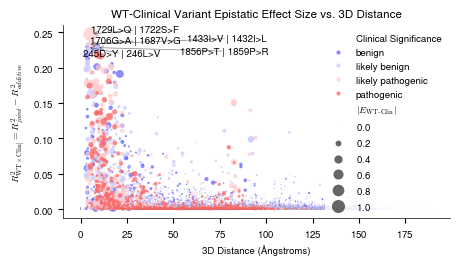

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [87]:
# Use a lambda to pass contact_map_ref as a closure variable, avoiding the error
ridge_df["mutant"] = ridge_df["clinical_variant"]
ridge_df["position_distance"] = (ridge_df["wt_position"] - ridge_df["clinical_position"]).abs()
ridge_df["Angstroms"] = ridge_df.apply(lambda x: ab.get_contact_score(x, distance_map_ref), axis=1)
ridge_df["is_contact"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_binary_ref)==1, axis=1) 
ridge_df["clinical_variant_fmt"] = ridge_df["clinical_variant"].apply(
    lambda x: (
        f"{x[1:-1]}{x[0]}>{x[-1]}"
        if isinstance(x, str) and len(x) >= 3 and x[1:-1].isdigit()
        else x
    )
)
ridge_df['protein'] = ridge_df['site'].str.split(":").str[0]
ridge_df = utils.add_hgvsp_id(ridge_df)


fig2f = ab.plot_wt_clinical_interaction_vs_angstroms(ridge_df,#.loc[ridge_df["interaction_strength"] > 0.01], 
                                                    vep_prot, 
                                                    N=5, style_var=None,
                                                    y_var="delta_r2",
                                                    size_var="interaction_strength",
                                                    figsize=(5,2.5),
                                                    y_title=r"$R^2_{\text{WT} \times \text{Clin}]} = R^2_{joint} - R^2_{additive}$",
                                                    title="WT-Clinical Variant Epistatic Effect Size vs. 3D Distance", 
                                                    rasterize_scatter=True,
                                                    label_fontsize="medium",
                                                    adjust_text_kwargs={"min_arrow_len": 0}
)

fig2f["fig"].savefig("manuscript/fig/brca1_interaction_strength_vs_angstroms.pdf", **utils.FIG_SAVE_KWARGS)

Check the baseline enrichment of all interactions with the top WT variant.

In [462]:
ridge_enrichment_at_threshold_1729LQ = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df.loc[(ridge_df["wt_variant"]=='1729L>Q')],
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[0,],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)
ridge_enrichment_at_threshold_1729LQ

100%|██████████| 1/1 [00:00<00:00, 19.78it/s]


,observed_prob,expected_prob,binom_test,enrichment,interaction_threshold,n_interactions
0,0.008571,0.002852,"BinomTestResult(k=3, n=350, alternative='two-s...",3.004995,0,456


### Figure 2h

Create population-weighted contact maps

For each superpopulation, weight the contacts maps according to their frequency in those populations.

In [62]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

100%|██████████| 128/128 [00:30<00:00,  4.17it/s]


In [63]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

# Get a merged FASTA file
merged_fasta = hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                        tx_ids=[tx_id],
                        save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                        split_subdir="",
                        # force=True,
                        compress=False) 

# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps_binary = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps_binary, 
                                                     msa=msa) 


Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


...

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 144 haplotypes across 1 tx_ids.


Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Padding contact maps to MSA: 100%|██████████| 126/126 [00:03<00:00, 39.47it/s]


In [64]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )

freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
freq_df.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (7860, 16)
>> haplotype(s): 144
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    41
EAS    20
SAS    16
AMR    14
EUR    13
MID     8
OCE     4
CSA     2
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 81.94%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000350283:1028R>H,0.000000,0.004902,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,AMR,0.004902,1,AMR,4.0
1,"ENSP00000350283:1038E>G,1183K>R,1613S>G",0.000000,0.000000,0.0,0.0,0.000000,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,0.003289,1,MID,1.0
2,"ENSP00000350283:1038E>G,1613S>G",0.000000,0.000000,0.0,0.0,0.003012,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,MID,0.003289,2,None,NaN
3,ENSP00000350283:1040S>N,0.000791,0.017157,0.0,0.0,0.020331,0.006579,0.0,0.000992,2.0,14.0,0.0,0.0,27.0,2.0,0.0,1.0,EUR,0.020331,5,None,NaN
4,ENSP00000350283:1099P>L,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.002976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,SAS,0.002976,1,SAS,3.0


In [65]:
pop_contact_maps = cf.compute_population_specific_contact_maps(
    contact_maps=contact_maps,
    contact_maps_binary=contact_maps_binary,
    freq_df=freq_df, 
    superpopulation_specific_only=False,
    exclude_ref_from_weights=True,
    weight_binary_maps=True,
)
specific_maps = pop_contact_maps["specific_maps"]
specific_diff_maps = pop_contact_maps["specific_diff_maps"]
specific_binary_diff_maps = pop_contact_maps["specific_binary_diff_maps"]
specific_binary_diff_figs = pop_contact_maps["specific_binary_diff_figs"]

/home/schilder/projects/VEP_protein/src/colabfold/colabfold.py:1566: UserWarning: Multiple keys found in contact_maps with pattern 'REF' in basename: ['/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_REF_unrelaxed_rank_002_alphafold2_ptm_model_1_seed_000.pdb.gz', '/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA/ENSP00000350283_REF_unrelaxed_rank_002_alphafold2_ptm_model_1_seed_000.pdb']. Using the last match.
  warnings.warn(
  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:20<00:00,  2.50s/it]


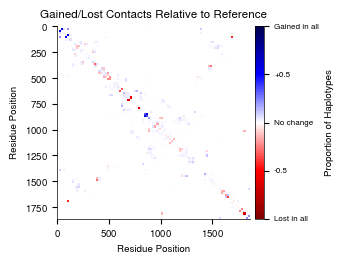

In [76]:
fig1g = cf.plot_contact_map_diff(contact_maps_binary,  
                                 figsize=(3.8, 2.65),
                                 title=f"Gained/Lost Contacts Relative to Reference",
                                 legend_title=r"Proportion of Haplotypes",
                                 weights=None,
                                 show_plot=True,
                                 verbose=False)
fig1g["fig"].savefig("manuscript/fig/brca1_gained_lost_contact_proportions.pdf", **utils.FIG_SAVE_KWARGS)

In [67]:
print(f"{(fig1g['data']>0).sum()} ({(fig1g['data']> 0).sum() / fig1g['data'].size*100:.2f}%) of contacts were gained in at least 1 haplotype")
print(f"{(fig1g['data']<0).sum()} ({(fig1g['data']< 0).sum() / fig1g['data'].size*100:.2f}%) of contacts were lost in at least 1 haplotype")

14072 (0.41%) of contacts were gained in at least 1 haplotype
994 (0.03%) of contacts were lost in at least 1 haplotype


### Figure 2I

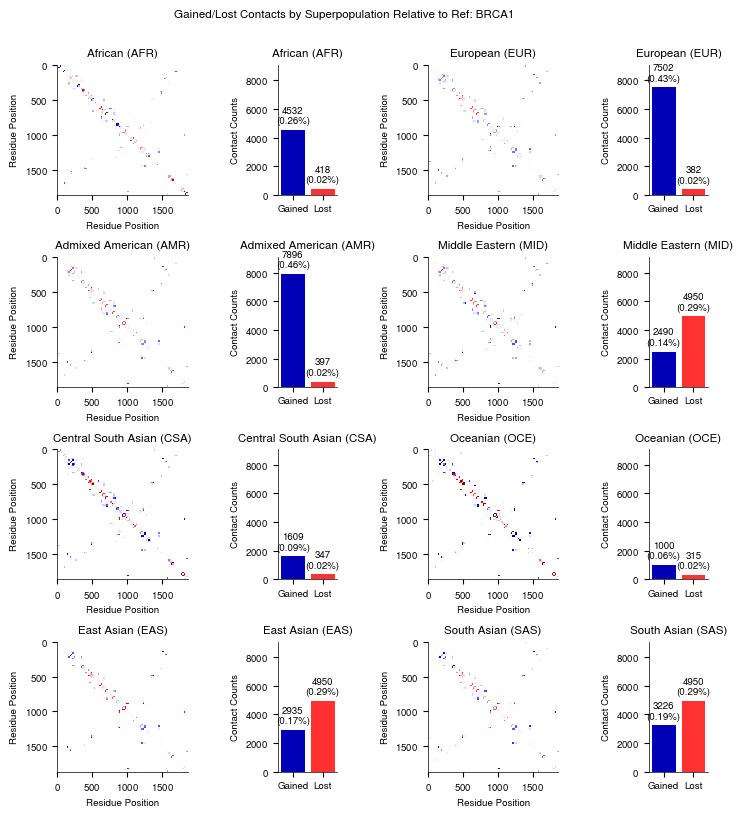

In [71]:
# %%capture

fig_superop_diff = cf.plot_superpopulation_contact_diff(
    specific_binary_diff_figs,
    specific_binary_diff_maps, 
    figsize=(3.8, 2),
    suptitle=f"Gained/Lost Contacts by Superpopulation Relative to Ref: {target_gene}",
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True,
    show_plot=False
)
# Remove top and right spines from all axes
for ax in fig_superop_diff['fig'].get_axes():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig_superop_diff['fig'].savefig("manuscript/fig/brca1_superpopulation_contact_diff.pdf", **utils.FIG_SAVE_KWARGS)

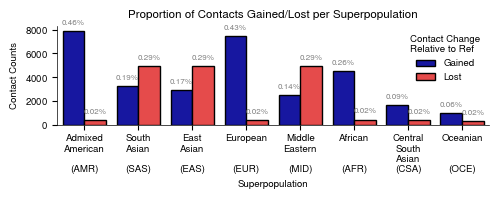

In [85]:
fig2h = cf.plot_contact_map_diff_barplot_grouped(
    bar_df=fig_superop_diff['data'],
    figsize=(5, 2),
    text_label_info=["percent"],
    group_by="superpopulation", 
    title=f"Proportion of Contacts Gained/Lost per Superpopulation",
    # text_label_rotation=90,
    # split_percent_sign=True,
    )
fig2h['fig'].savefig("manuscript/fig/brca1_superpopulation_contact_diff_barplot.pdf", **utils.FIG_SAVE_KWARGS)


## Figure 3

### Figure 3a

VEP distributions: SpliceAI

In [2]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
spliceai_df = pd.read_parquet(spliceai_df_path)

# Standardise clinical significance labels
spliceai_df["clinsig"] = spliceai_df["CLNSIG_simplified"].astype(str)
likely_mask = spliceai_df["CLNSIG"].str.lower().str.contains("likely").fillna(False)
spliceai_df.loc[likely_mask, "clinsig"] = "likely_"+spliceai_df.loc[likely_mask, "clinsig"]
spliceai_df.replace({"clinsig": {"vus": "VUS"}}, inplace=True)
spliceai_df = spliceai_df[~spliceai_df["clinsig"].isin([np.str_('nan'), 'nan'])]
spliceai_df["clinsig_simple"] = spliceai_df["clinsig"].str.replace("likely_", "")

/home/schilder/.cache/tmp/ipykernel_1648488/2931141490.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  likely_mask = spliceai_df["CLNSIG"].str.lower().str.contains("likely").fillna(False)


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


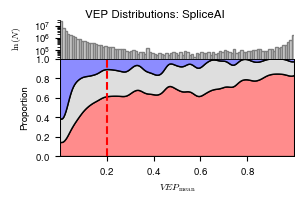

In [53]:
import src.analysis.distributions as db

vep_dist_plot_spliceai = db.plot_vep_kde_with_arrows(vep_df=spliceai_df, 
                                    figsize=(3, 2.25),
                                     title_y=.82,
                                      height_ratios=(.4,1), 
                                    add_histogram=True,
                                    hist_log_y=True,
                                    hist_y_label=r"$\ln(N)$",
                                    clinsig_col="clinsig_simple",
                                    legend_loc=None,
                                    # arrow_kwargs={"y_arrow_offset":0.22, "y_label_offset":0.04},
                                    arrow_kwargs=None,
                                    vline_kwargs={"x": 0.2, "color": "red", "linewidth": 1.5, "alpha": 1, "linestyle": "--"},
                                    format_k=True,
                                    title="VEP Distributions: SpliceAI",
                                    save_path="manuscript/fig/vep_kde_spliceai.pdf")

In [9]:
vep_agg = spliceai_df.groupby(["clinsig_simple","site"])["VEP"].mean().reset_index()    

/home/schilder/projects/VEP_protein/src/vep_analysis.py:4025: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

benign vs. VUS: t-test independent samples with Bonferroni correction, P_val:2.937e-45 t=-1.434e+01
VUS vs. pathogenic: t-test independent samples with Bonferroni correction, P_val:3.580e-109 t=-2.273e+01
benign vs. pathogenic: t-test independent samples with Bonferroni correction, P_val:6.988e-234 t=-3.422e+01


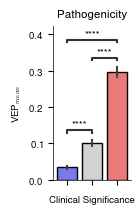

In [ ]:
va.plot_variant_type_and_clinsig(
    vep_agg,
    legend=False, 
    figsize=(1, 2),
    title = r"Pathogenicity",
    x_label="Clinical Significance",
    hue_var = "clinsig_simple",
    x_var = "clinsig_simple",
    hide_xtick_labels=True,
    save_path="manuscript/fig/spliceai_vep_mean_by_clinsig.pdf")

### Figure 3C

Dataset summary statistics.

- WT variants per person (can get from VCFs)
- WT variants per haplotype in the SpliceAI/Flashzoi regions used (can get from GVL datasets with `.n_variants`)
- Number of clinical variants per gene
- Proportion of SpliceAI VEPs that were of each score type (stratified by pathogenicity/splicegenicity)
- Proportion of Flashzoi VEPs that were of each 5' or 3' UTR

/home/schilder/projects/VEP_protein/src/vep_analysis.py:4251: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
/home/schilder/projects/VEP_protein/src/vep_analysis.py:4258: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


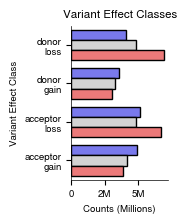

In [4]:
plot_score_type_by_clinsig_out = va.plot_score_type_by_clinsig(spliceai_df, 
    figsize=(1.25, 2), legend_bbox_to_anchor=(-.5, 1.1),
    legend_loc=None,
    title = "Variant Effect Classes",
    x_label="Variant Effect Class",
    flip_axes=True,
    wrap_labels=True,
    show_legend=False,
    save_path="manuscript/fig/spliceai_score_type_by_clinsig.pdf")

### Figure 3D

/home/schilder/projects/VEP_protein/src/vep_analysis.py:4425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  entropy_df = df.groupby([groupby_cat, subgroupby], observed=True).apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

benign vs. VUS: t-test independent samples with Bonferroni correction, P_val:1.089e-07 t=5.516e+00
VUS vs. pathogenic: t-test independent samples with Bonferroni correction, P_val:1.997e-15 t=8.099e+00
benign vs. pathogenic: t-test independent samples with Bonferroni correction, P_val:1.845e-45 t=1.435e+01


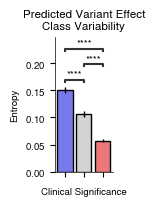

In [3]:
plot_entropy_by_category_out = va.plot_categorical_entropy(
    df=spliceai_df,
    groupby_cat="clinsig_simple",
    subgroupby="site",
    categorical_col="max_delta_score_type", 
    figsize=(.75, 1.75),
    xlabel="Clinical Significance",
    ylabel="Entropy",
    title="Predicted Variant Effect\nClass Variability",
    save_path="manuscript/fig/spliceai_entropy_by_clinsig.pdf",
    show_xticklabels=False,
    errorbar_capsize=0,
)

### SpliceAI VEP distributions

In [8]:
import src.analysis.vep_gmm as gmm

n_facets_init = 10
 
target_sites = ["chr17:2981247-2981248_A_G", "chr17:43115788-43115789_G_C"]
plot_df = spliceai_df.loc[spliceai_df["site"].isin(target_sites)].copy()

import re
def simplify_site(site):
    # Convert "chr17:3655058-3655059_C_T" --> "chr17:3655058 C>T"
    m = re.match(r"([^:]+):(\d+)-\d+_([ACGT])_([ACGT])", site)
    if m:
        return f"{m.group(1)}:{m.group(2)} {m.group(3)}>{m.group(4)}"
    return site

plot_df.loc[:,"site_simple"] = plot_df["site"].apply(simplify_site)
plot_df.loc[:,"facet_label"] = "Gene: " + plot_df["GENE"].astype(str)+\
  "\nVariant: " + plot_df["site_simple"]+\
  " ("+plot_df["clinsig_simple"]+")"

if "VEP_REF" not in plot_df.columns:
    plot_df["is_ref"] = plot_df["sample"]=="REF"
    plot_df = va.compute_representativeness_stats(plot_df, is_ref=False, groupby_cols=['GENE', 'site','clinsig_simple'],)

### Compute decision boundaries
import src.analysis.vep_gmm as gmm
gmm_df = gmm.train_vep_gmm(spliceai_df.loc[spliceai_df["GENE"].isin(plot_df["GENE"].unique())], 
                            groupby_cols=["GENE"], clinsig_col="clinsig_simple",)
boundary_crossing_df = gmm.get_decision_boundaries(gmm_df, plot_df, gene_col="GENE", mutant_col="site", clinsig_col="clinsig_simple", plot=False)

Computing representativeness stats for VEP_percentile


Training GMMs: 100%|██████████| 2/2 [00:09<00:00,  4.78s/it]
/home/schilder/projects/VEP_protein/src/analysis/vep_gmm.py:433: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variant_groups = vep_df.groupby([gene_col, mutant_col])


Total model-protein-scoring combinations with GMM models: 1
Average accuracy: 0.2469
Average AUC: 0.7762
Error plotting ('RAP1GAP2',): 'protein'


Finding boundary-crossing variants: 100%|██████████| 2/2 [00:00<00:00, 398.91it/s]

Adding crossing proportion
No variants found that cross decision boundaries in different haplotypes


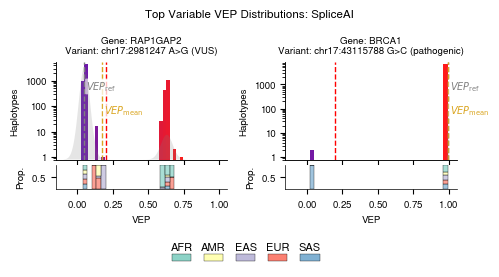

In [29]:
target_sites = ["chr17:2981247-2981248_A_G", "chr17:43115788-43115789_G_C"]
top_spliceai_sites = gmm.plot_vep_histograms_with_boundaries(vep_df=plot_df,
                                                        boundary_crossing_df=0.2,
                                                        target_sites=target_sites, 


                                                        facet_height=2,
                                                        facet_aspect=1.25,
                                                        
                                                        show_twinx_labels=False,
                                                        # show_vertical_line_labels=False,
                                                        n_xticks=5,
                                                        n_yticks=5,
                                                        show_superpops=True,
                                                        superpop_legend_bottom=False,
                                                        superpop_height_ratio=0.3,
                                                        superpop_bins=30,
                                                        facet_row_spacing=1.2,
                                                        y_offset_factor=1,
                                                        label_yspacing=0.25,
                                                        log_yaxis=True,
                                                        superpop_legend_y=-.2,

                                                        facet_col="facet_label",
                                                        title="Top Variable VEP Distributions: SpliceAI",
                                                        gene_col="GENE",    
                                                        mutant_col="site",
                                                        palette=["blue","red"],
                                                        show_vertical_line_labels=[True, True, False],
                                                        vertical_line_label_fontsize="medium",
                                                        show_vertical_line_label_edges=False,
                                                        vertical_line_label_bbox_alpha=0.75,

                                                        sharex=True,
                                                        sharey=False, 
                                                        col_wrap=2,
                                                      # x_offset = 0.01,
                                                        bins=30
                                                        )
top_spliceai_sites["fig"].savefig("manuscript/fig/spliceai_boundaries_top_mad.pdf", **utils.FIG_SAVE_KWARGS)

## Figure 4

Flashzoi UTR.

### Figure 1a

VEP distributions: Flashzoi

In [60]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
) 
pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")

flashzoi_df = pd.read_parquet(pq_file)
if "VEP" not in flashzoi_df.columns:
    flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"] 
if "site" not in flashzoi_df.columns:
    flashzoi_df.rename(columns={"site_x": "site"}, inplace=True)
flashzoi_df["protein"] = flashzoi_df["GENE"] 

# Normalize the values before mapping
clnsig_map = {"likely_path": "likely pathogenic",
                    "path": "pathogenic", 
                    "benign": "benign",
                    "vus": "VUS",
                    "likely_benign": "likely benign"} 
flashzoi_df.rename(columns={"site_x":"site"}, inplace=True)
flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"]
flashzoi_df["clinsig"] = flashzoi_df["CLNSIG_simple"].map(clnsig_map)
flashzoi_df["clinsig_simple"] = flashzoi_df["clinsig"].str.replace("likely ", "")

In [61]:
flashzoi_df.groupby(["CLNSIG_simple"])["site"].nunique()

CLNSIG_simple
benign           3903
likely_benign    1800
likely_path       572
path              374
Name: site, dtype: int64

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


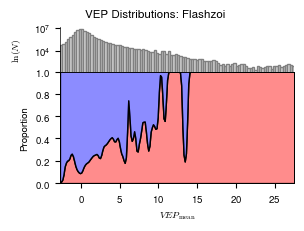

In [64]:
import src.analysis.distributions as db

vep_dist_plot_flashzoi = db.plot_vep_kde_with_arrows(vep_df=flashzoi_df, 
                                    figsize=(3, 2.5), 
                                     title_y=.85,
                                     extend_kde_to_outliers=False,
                                      height_ratios=(.4,1), 
                                    add_histogram=True,
                                    hist_log_y=True,
                                    hist_y_format="m",
                                    hist_y_label=r"$\ln(N)$",
                                    clinsig_col="clinsig_simple",
                                    # legend_loc="upper right",
                                    legend_loc=None,
                                    # arrow_kwargs={"y_arrow_offset":0.23, "y_label_offset":0.04},
                                    arrow_kwargs=None,
                                    vline_kwargs=None,
                                    format_k=True,
                                    title="VEP Distributions: Flashzoi",
                                    save_path="manuscript/fig/vep_kde_flashzoi.pdf")

### Figure 4B

Mean VEP by clinsig and 5'/3' UTR

In [140]:
flashzoi_vep_mean = flashzoi_df.groupby(["clinsig_simple","MC_term","site"])["VEP"].mean().reset_index()
flashzoi_vep_mean["MC_term_label"] = flashzoi_vep_mean["MC_term"].map(
    {"3_prime_UTR_variant": r"3 $'$ UTR", "5_prime_UTR_variant": r"5 $'$ UTR"}
)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

5 $'$ UTR_benign vs. 5 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:1.271e-09 t=-6.320e+00
3 $'$ UTR_benign vs. 3 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:2.379e-09 t=-6.205e+00
3 $'$ UTR_benign vs. 5 $'$ UTR_benign: t-test independent samples with Bonferroni correction, P_val:1.636e-03 t=-3.536e+00
3 $'$ UTR_pathogenic vs. 5 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:1.000e+00 t=-5.136e-01


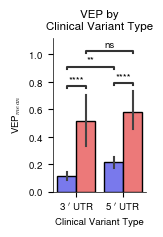

In [145]:
va.plot_variant_type_and_clinsig(
    flashzoi_vep_mean,
    figsize=(1.2, 2),
    title = "VEP by\nClinical Variant Type",
    legend=False, 
    save_path="manuscript/fig/flashzoi_vep_mean_by_variant_type_and_clinsig.pdf"
    )

Compute Mean Absolute Deviation per clinical variant.

In [146]:
from statsmodels import robust

tqdm.pandas()
flashzoi_vep_mad = flashzoi_df.groupby(["GENE","clinsig_simple","MC_term","site"], observed=True).progress_apply(
    lambda x: robust.mad(x["VEP"], c=1)
).reset_index().rename(columns={0:"MAD"}).sort_values(by="MAD", ascending=False)

flashzoi_vep_mad["MC_term_label"] = flashzoi_vep_mad["MC_term"].map(
    {"3_prime_UTR_variant": r"3 $'$ UTR", "5_prime_UTR_variant": r"5 $'$ UTR"}
)


 96%|█████████▌| 6394/6649 [00:14<00:00, 3515.86it/s]/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 6649/6649 [00:18<00:00, 364.11it/s] 


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

5 $'$ UTR_benign vs. 5 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:5.907e-01 t=1.448e+00
3 $'$ UTR_benign vs. 3 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:1.000e+00 t=-8.717e-01
3 $'$ UTR_benign vs. 5 $'$ UTR_benign: t-test independent samples with Bonferroni correction, P_val:2.123e-14 t=-7.841e+00
3 $'$ UTR_pathogenic vs. 5 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:1.000e+00 t=-1.098e+00


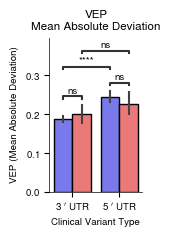

In [148]:
va.plot_variant_type_and_clinsig(flashzoi_vep_mad, y_var="MAD", y_label="VEP (Mean Absolute Deviation)",
                                figsize=(1.2, 2),
                                legend=False,
                                title="VEP\nMean Absolute Deviation",
                                save_path="manuscript/fig/flashzoi_vep_mad_by_variant_type_and_clinsig.pdf")

In [149]:
import src.analysis.vep_gmm as gmm

n_facets_init = 10

# Get unique clinsig_simple values, sorted for reproducibility
clinsig_groups = sorted(flashzoi_vep_mad["clinsig_simple"].dropna().unique(),   reverse=True)
variants_per_group = n_facets_init // len(clinsig_groups)
selected_variant_sites = []

for clinsig in clinsig_groups:
    group_variants = (
        flashzoi_vep_mad[flashzoi_vep_mad["clinsig_simple"] == clinsig]
        .sort_values("MAD", ascending=False)
    )
    # Ensure only one per gene (highest MAD per gene, by clinsig group)
    group_variants = group_variants.drop_duplicates(subset="GENE", keep="first")
    selected_variant_sites.extend(group_variants.iloc[:variants_per_group]["site"].tolist())

target_sites = selected_variant_sites
plot_df = flashzoi_df.loc[flashzoi_df["site"].isin(target_sites)].copy()

import re
def simplify_site(site):
    # Convert "chr17:3655058-3655059_C_T" --> "chr17:3655058 C>T"
    m = re.match(r"([^:]+):(\d+)-\d+_([ACGT])_([ACGT])", site)
    if m:
        return f"{m.group(1)}:{m.group(2)} {m.group(3)}>{m.group(4)}"
    return site

plot_df.loc[:,"site_simple"] = plot_df["site"].apply(simplify_site)
plot_df.loc[:,"facet_label"] = "Gene: " + plot_df["GENE"]+\
  "\nVariant: " + plot_df["site_simple"]+\
  " ("+plot_df["MC_term"].map({"3_prime_UTR_variant": r"3 $'$ UTR", "5_prime_UTR_variant": r"5 $'$ UTR"})+\
  ", "+plot_df["clinsig_simple"]+")"

if "VEP_REF" not in plot_df.columns:
    plot_df["is_ref"] = plot_df["sample"]=="REF"
    plot_df = va.compute_representativeness_stats(plot_df, is_ref=False, groupby_cols=['GENE', 'site', 'MC_term', 'clinsig_simple'],)

### Add superpopulation information
import src.onekg as og
meta = og.get_sample_metadata()
plot_df = plot_df.merge(meta, on="sample", how="left")

### Compute decision boundaries
import src.analysis.vep_gmm as gmm
gmm_df = gmm.train_vep_gmm(flashzoi_df.loc[flashzoi_df["GENE"].isin(plot_df["GENE"].unique())], 
                            groupby_cols=["GENE"], clinsig_col="clinsig_simple",)
boundary_crossing_df = gmm.get_decision_boundaries(gmm_df, plot_df, gene_col="GENE", mutant_col="site", clinsig_col="clinsig_simple", plot=False)


# Only plot sites whose gene has a decision boundary
n_facets_final = 4
final_site_selection = plot_df.loc[plot_df["GENE"].isin(boundary_crossing_df['GENE'].unique())]["site"].unique()[:n_facets_final]



Computing representativeness stats for VEP_percentile
0 samples are missing superpopulation metadata


Training GMMs: 100%|██████████| 10/10 [00:06<00:00,  1.52it/s]


Total model-protein-scoring combinations with GMM models: 7
Average accuracy: 0.3907
Average AUC: 0.6652
Error plotting ('TP53',): 'protein'


Finding boundary-crossing variants: 100%|██████████| 10/10 [00:00<00:00, 171.00it/s]

Adding crossing proportion
No variants found that cross decision boundaries in different haplotypes


In [150]:
plot_df_stats = plot_df.loc[plot_df["site"].isin(final_site_selection)].groupby(["site"])["VEP"].describe()
plot_df_stats["min_max_ratio"] = plot_df_stats["max"]/plot_df_stats["min"]
plot_df_stats

,count,mean,std,min,25%,50%,75%,max,min_max_ratio
site,,,,,,,,,
chr12:32645731-32645732_G_A,10196.0,1.960148,3.309634,-1.310135,-1.310135,2.902550,4.326844,9.005821,-6.873964
chr17:3655058-3655059_C_T,10196.0,9.184518,4.761267,0.845234,4.898693,9.313030,13.712652,18.173982,21.501709
chr22:50623794-50623795_G_C,10196.0,1.356015,2.417928,-1.090062,-1.090062,2.098117,3.703467,8.168441,-7.493557
chr3:37004474-37004475_G_C,10196.0,5.036322,1.848855,0.703652,3.449145,5.579763,6.326197,9.094745,12.925061


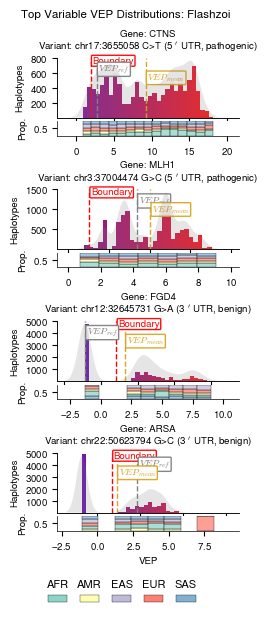

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [176]:

top_mad_sites = gmm.plot_vep_histograms_with_boundaries(vep_df=plot_df.loc[plot_df["site"].isin(final_site_selection)],
                                                        boundary_crossing_df=boundary_crossing_df,
                                                        target_sites=target_sites, 


                                                        facet_height=1.4,
                                                        facet_aspect=1.8,
                                                        
                                                        show_twinx_labels=False,
                                                        n_xticks=5,
                                                        n_yticks=5,
                                                        show_superpops=True,
                                                        superpop_legend_bottom=False,
                                                        superpop_height_ratio=0.3,
                                                        superpop_bins=15,
                                                        facet_row_spacing=1.2,
                                                        y_offset_factor=1,
                                                        # superpop_legend_y=0,

                                                        facet_col="facet_label",
                                                        title="Top Variable VEP Distributions: Flashzoi",
                                                        gene_col="GENE",    
                                                        mutant_col="site",
                                                        palette=["blue", "red"],
                                                        sharex=False,
                                                        sharey=False, 
                                                          col_wrap=1,
                                                      # x_offset = 0.01,
                                                        bins=30
                                                        )
top_mad_sites["fig"].savefig("manuscript/fig/flashzoi_boundaries_top_mad.pdf", **utils.FIG_SAVE_KWARGS)

---

---

## Supplementary Figure: protein

In [25]:
if "freq_df" not in globals():
    haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                            as_df=True,
                                            add_sample_metadata=True,
                                            return_seqs=False, 
                                            add_ref=False, 
                                            duplicate_ref=False,
                                            verbose=True,
                                            )

    freq_df = hs.calculate_haplotype_frequency_per_superpop(
        haps_to_samples,
        cast=True, 
        verbose=True,
        add_specificity_cols=True
    )

Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 2847


Processing sample to haplotype name maps:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (19262867, 16)
>> haplotype(s): 132721
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    35540
EAS    22458
EUR    14917
SAS    13574
AMR     9224
CSA     5134
MID     4439
OCE     1850
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 80.72%


### Subfigure A

In [26]:
haplotypes_per_protein = haps_to_samples.groupby("ENST_haplosaurus")["haplotype"].nunique()

In [27]:
len(haplotypes_per_protein)

2847

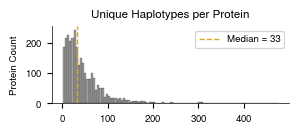

In [35]:
fig = plt.figure(figsize=(3, 1.35)) 

ax = sns.histplot(haplotypes_per_protein, bins=100, color="grey")
median_haplotypes = haplotypes_per_protein.median()
plt.axvline(median_haplotypes, color="goldenrod", linestyle="--", linewidth=1, label=f"Median = {int(median_haplotypes)}")
plt.title("Unique Haplotypes per Protein")
plt.xlabel(None)
plt.ylabel("Protein Count")
plt.legend()
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("manuscript/fig/haplotypes_per_protein.pdf", **utils.FIG_SAVE_KWARGS)


### Subfigure B


Superopulation upset plot.

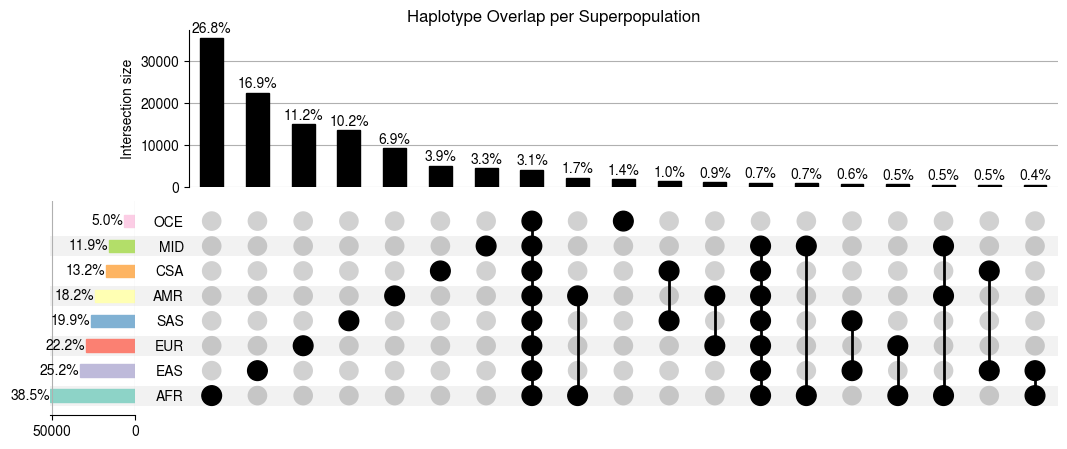

In [123]:
plot_superpop_upset_out = hs.plot_superpop_upset(freq_df)
plot_superpop_upset_out['fig'].savefig("manuscript/fig/superpopulation_upset.pdf", **utils.FIG_SAVE_KWARGS)

#### Subfigure C

Protein sequence model VEP distributions.

In [175]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = f"./results/data/vep_df_{model_name}.parquet"
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
else:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)
    vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"], 
                          vep_files=vep_files.loc[vep_files['model_location']==model_name]
                               )
    print(f"Saving {tmp_vep_path}")
    vep_df.to_parquet(tmp_vep_path)

vep_df.head() 

Loading ./results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:L1045F,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:D1003Y,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:N996I,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:E978K,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multip

In [133]:
force = False
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy'] 
vep_agg =[]
vep_counts = []
for model_location in va.list_all_models():

    print(f"Processing {model_location}")
    save_path = os.path.join("results/data/","vep_df_"+model_location+".parquet")
    
    if os.path.exists(save_path) and not force:
        print(f"Loading {save_path}")
        vep_tmp = pd.read_parquet(save_path)
    else:
        vep_files_model = va.list_vep_files(model_location=model_location, as_df=True)
        vep_tmp = va.merge_vep(add_metadata=True, 
                                scoring_strategy=["masked-marginals"], 
                                vep_files=vep_files_model
                                )
        print(f"Saving {save_path}")
        vep_tmp.to_parquet(save_path)
    vep_counts.append(vep_tmp.shape[0])
    vep_agg.append(vep_tmp.groupby(groupby_cols, observed=True)["VEP"].mean().reset_index())
     

vep_agg = pd.concat(vep_agg)
print("Total VEP results:",sum(vep_counts))
vep_agg.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Processing esm2_t12_35M_UR50D
Loading results/data/vep_df_esm2_t12_35M_UR50D.parquet
Processing esm1b_t33_650M_UR50S
Loading results/data/vep_df_esm1b_t33_650M_UR50S.parquet
Processing esm2_t33_650M_UR50D
Loading results/data/vep_df_esm2_t33_650M_UR50D.parquet
Processing esm1_t34_670M_UR50D
Loading results/data/vep_df_esm1_t34_670M_UR50D.parquet
Processing esm1_t6_43M_UR50S
Loading results/data/vep_df_esm1_t6_43M_UR50S.parquet
Processing esm1v_t33_650M_UR90S_1
Loading results/data/vep_df_esm1v_t33_650M_UR90S_1.parquet
Processing esm2_t48_15B_UR50D
Loading results/data/vep_df_esm2_t48_15B_UR50D.parquet
Processing esm3_sm_open_v1
Loading results/data/vep_df_esm3_sm_open_v1.parquet
Processing esmc_600m
Loading results/data/vep_df_esmc_600m.parquet
Total VEP results: 21709189


,model_location,protein,clinsig,mutant,scoring_strategy,VEP
0,esm2_t12_35M_UR50D,NP_000007.1,benign,C159W,masked-marginals,-4.259397
1,esm2_t12_35M_UR50D,NP_000007.1,likely_benign,M87I,masked-marginals,-0.187846
2,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A113T,masked-marginals,-4.230541
3,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A165T,masked-marginals,-2.380263
4,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A81T,masked-marginals,-2.507311


In [6]:
vep_agg.groupby('model_location').size().sort_values(ascending=False)

model_location
esm1_t34_670M_UR50D       56379
esmc_600m                 56379
esm2_t33_650M_UR50D       56364
esm3_sm_open_v1           56364
esm2_t12_35M_UR50D        53402
esm1v_t33_650M_UR90S_1    35659
esm1b_t33_650M_UR50S      34964
esm2_t48_15B_UR50D         8319
esm1_t6_43M_UR50S          1757
dtype: int64

In [65]:
vep_agg["clinsig"].value_counts()

clinsig
likely_path      126486
likely_benign    120298
path              58536
benign            54267
Name: count, dtype: int64

Filtered 0.2% of rows with NAs in col 'VEP'


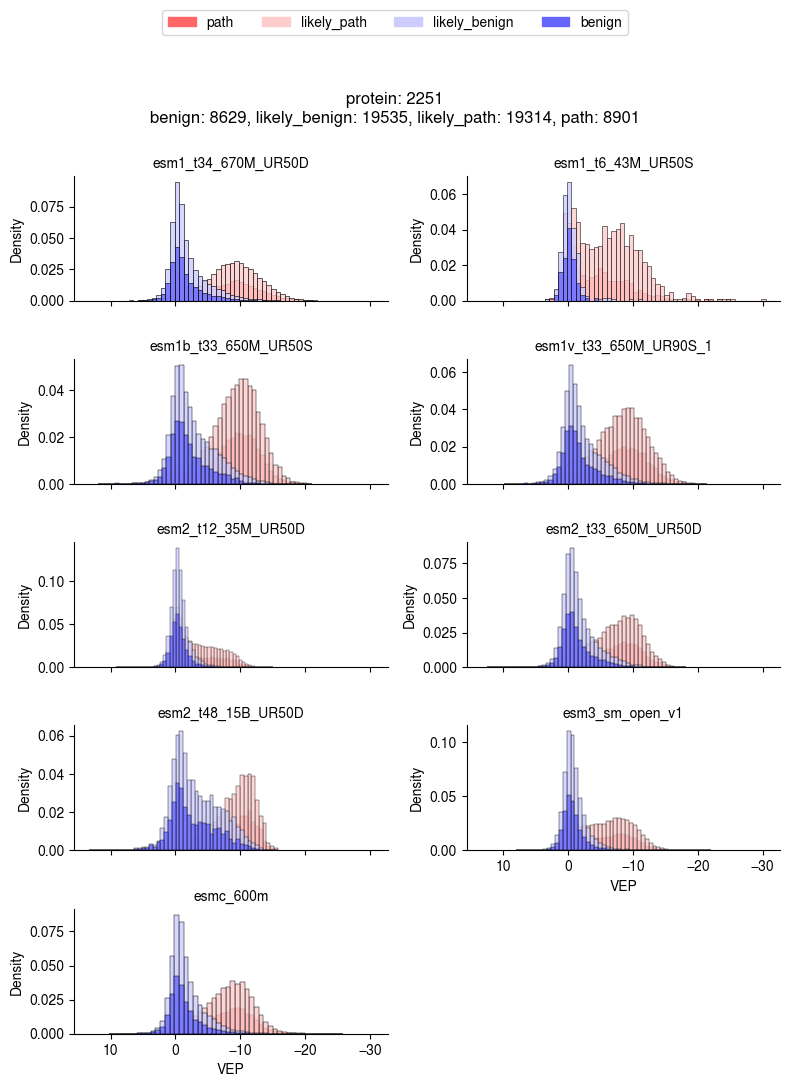

In [137]:
figS1 = va.plot_vep_density(vep_agg.sort_values(by='model_location'), 
                     multiple=['layer','stack','fill'][0],
                     row=None,
                     col='model_location',    
                    #  multiple="stack",
                     plot_func=sns.histplot,
                     stat='density',
                     bins=50,
                     facetgrid_kwargs={'col_wrap': 2}, 
                     height=2,
                     aspect=2,
                     flip_xaxis=True,
                     save_path="manuscript/fig/vep_PLM_distributions.pdf"
                     )

In [136]:
vep_diff_df, vep_diff_summary = db.test_vep_clinsig_separation(vep_agg)
vep_diff_summary

,pvalue,statistic
model_location,,
esmc_600m,1.939497e-08,1.507877e+08
esm2_t33_650M_UR50D,2.205292e-04,1.464150e+08
esm1_t34_670M_UR50D,9.101600e-07,1.448694e+08
esm3_sm_open_v1,3.546757e-05,1.418671e+08
esm2_t12_35M_UR50D,2.079269e-03,1.145610e+08
esm1b_t33_650M_UR50S,1.259272e-01,5.662216e+07
esm1v_t33_650M_UR90S_1,4.195902e-02,5.624953e+07
esm2_t48_15B_UR50D,5.156835e-02,3.089960e+06
esm1_t6_43M_UR50S,1.649432e-01,1.093967e+05


### DNA sequence models

Import Flashzoi VEP results.

In [337]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
) 
pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")

flashzoi_df = pd.read_parquet(pq_file)
if "VEP" not in flashzoi_df.columns:
    flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"] 
if "site" not in flashzoi_df.columns:
    flashzoi_df.rename(columns={"site_x": "site"}, inplace=True)
flashzoi_df["protein"] = flashzoi_df["GENE"] 

# Normalize the values before mapping
clnsig_map = {"likely_path": "likely pathogenic",
                    "path": "pathogenic", 
                    "benign": "benign",
                    "vus": "VUS",
                    "likely_benign": "likely benign"} 
flashzoi_df.rename(columns={"site_x":"site"}, inplace=True)
flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"]
flashzoi_df["clinsig"] = flashzoi_df["CLNSIG_simple"].map(clnsig_map)

Import SpliceAI VEP results.

In [336]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
spliceai_df = pd.read_parquet(spliceai_df_path)
spliceai_df["protein"] = spliceai_df["GENE"]

# Normalize the values before mapping
clinsig_map = {"benign": "benign",
               "pathogenic": "path",
               "vus": "VUS"}
spliceai_df["clinsig"] = (
    spliceai_df["CLNSIG_simplified"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(clinsig_map)
)

spliceai_df["clinsig"].unique()

array(['VUS', 'benign', 'path', nan], dtype=object)

## Supplementary Figure: Reference Representativeness

### Subfigure A

Reference rep violin: ESM2

Computing representativeness stats for VEP_percentile


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


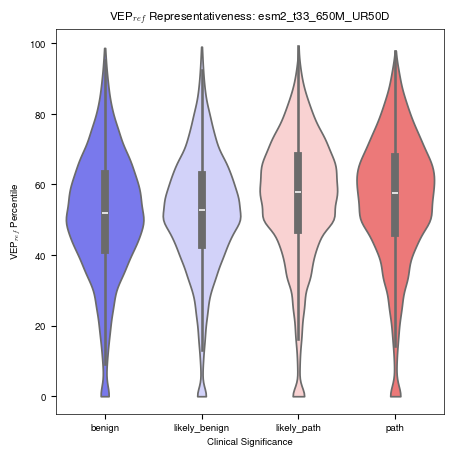

In [72]:
ref_rep_out_esm2 = va.plot_vep_ref_representativeness(vep_df, 
                groupby_cols=['model_location','protein','clinsig','mutant','scoring_strategy'], 
                title=r"VEP$_{ref}$ Representativeness"+f": {model_name}",
                hline_x=None,
                reverse_percentiles=True
                )
ref_rep_out_esm2["fig"].savefig("manuscript/fig/ref_rep_violin_esm2.pdf", **utils.FIG_SAVE_KWARGS)   

### Subfigure B

Reference rep violin: SpliceAI

In [73]:
ref_rep_out_spliceai = va.plot_vep_ref_representativeness(spliceai_df, 
                                groupby_cols=['site','clinsig'],
                                # clinsig_col="CLNSIG_simplified",
                                title=r"VEP$_{ref}$ Representativeness"+f": SpliceAI",
                                hline_x=None
                                )
ref_rep_out_spliceai["fig"].savefig("manuscript/fig/ref_rep_violin_spliceai.pdf", **utils.FIG_SAVE_KWARGS)   

NameError: name 'spliceai_df' is not defined

### Subfigure C

Reference rep violin: Flashzoi

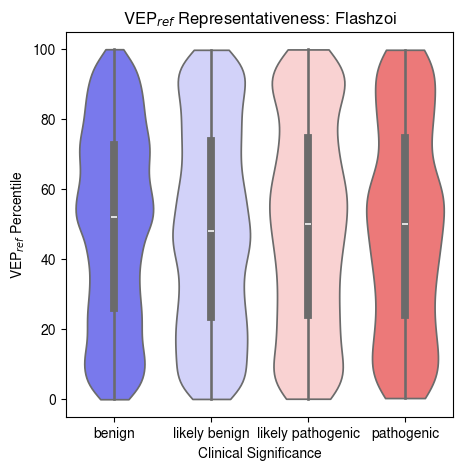

In [94]:
ref_rep_out_flashzoi = va.plot_vep_ref_representativeness(flashzoi_df, 
                                groupby_cols=['site','clinsig'],
                                title=r"VEP$_{ref}$ Representativeness"+f": Flashzoi",
                                hline_x=None,
                                reverse_percentiles=True)
ref_rep_out_flashzoi["fig"].savefig("manuscript/fig/ref_rep_violin_flashzoi.pdf", **utils.FIG_SAVE_KWARGS)   

### Subfigure D

Reference rep bar: ESM2

Computing representativeness stats for VEP_percentile


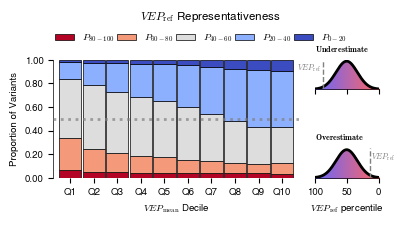

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [125]:
ref_rep_bar_esm2 = db.plot_ref_vep_percentile_stacked_bar(vep_df, 
                                                    title=r"$VEP_{\text{ref}}$ Representativeness",
                                                    x_label=r"$VEP_{\text{mean}}$ Decile",
                                                    figsize=(4.2, 2), 
                                                    barplot_width_ratio=5, 
                                                    n_ref_pct_bins=5, 
                                                    
                                                    legend_loc="upper center",
                                                    legend_columnspacing=0.25,

                                                    legend_upper_center_y=1.1,  # Y position (figure coordinates) for legend when legend_loc="upper center"
                                                    legend_upper_center_x=0.6, 
                                                    title_upper_center_y=0.95,  # Y position (figure coordinates) for suptitle when legend_loc="upper center"
                                                    layout_top_upper_center=0.70,  # Top margin (0-1) for subplots_adjust when legend_loc="upper center"
                                                    
                                                    legend_on_right=False,
                                                    legend_frame=False,
                                                    reverse_legend=False,
                                                    show_schematic_xlabel=(False, True), 
                                                    show_schematic_ylabel=[False, False],
                                                    show_vertical_arrows=False,   
                                                    schematic_width_ratio=1.3,
                                                    schematic_padding_left = .1,
                                                    schematic_padding_top=0,
                                                    schematic_heights=[0.25, 1-0.25*2, 0.25],
                                                    
                                                    flip_xaxis=True
                                                    )
ref_rep_bar_esm2["fig"].savefig("manuscript/fig/ref_rep_bar_esm2.pdf", **utils.FIG_SAVE_KWARGS)   
 

### Subfigure E

Reference rep bar: SpliceAI

Computing representativeness stats for VEP_percentile


/home/schilder/projects/VEP_protein/src/analysis/distributions.py:1752: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stacked = data.groupby(['VEP_binned_label', 'VEP_percentile_decile']).size().unstack(fill_value=0)
/home/schilder/projects/VEP_protein/src/analysis/distributions.py:1927: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 176, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


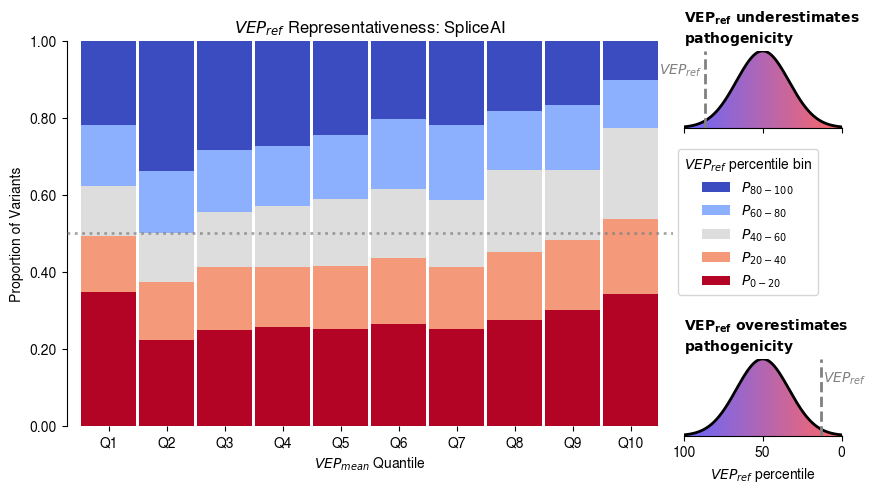

In [ ]:
ref_rep_bar_spliceai = db.plot_ref_vep_percentile_stacked_bar(spliceai_df,
                                                    groupby_cols=['site','clinsig'],
                                                     title=r"$VEP_{\text{ref}}$ Representativeness: SpliceAI",
                                                    figsize=(10, 5), 
                                                    barplot_width_ratio=5, 
                                                    n_ref_pct_bins=5,
                                                    legend_on_right=True,
                                                    show_schematic_xlabel=(False, True), 
                                                    show_schematic_ylabel=[False, False],
                                                    show_vertical_arrows=False,   
                                                    schematic_width_ratio=1.3,
                                                    schematic_padding_left = -0.15,
                                                    schematic_padding_top=0.02,
                                                    schematic_heights=[0.2, 0.6, 0.2]
                                                    )
ref_rep_bar_spliceai["fig"].savefig("manuscript/fig/ref_rep_bar_spliceai.pdf", **utils.FIG_SAVE_KWARGS)   

### Subfigure F

Reference rep bar: Flashzoi

Computing representativeness stats for VEP_percentile


<string>:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


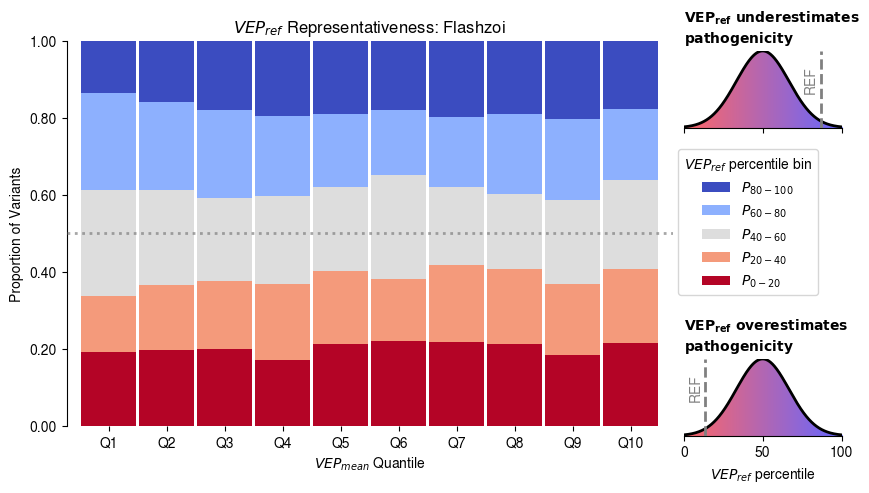

In [ ]:
ref_rep_bar_flashzoi = db.plot_ref_vep_percentile_stacked_bar(flashzoi_df,
                                                    groupby_cols=['site','clinsig'],
                                                     title=r"$VEP_{\text{ref}}$ Representativeness: Flashzoi",
                                                    figsize=(10, 5), 
                                                    barplot_width_ratio=5, 
                                                    n_ref_pct_bins=5,
                                                    legend_on_right=True,
                                                    show_schematic_xlabel=(False, True), 
                                                    show_schematic_ylabel=[False, False],
                                                    show_vertical_arrows=False,   
                                                    schematic_width_ratio=1.3,
                                                    schematic_padding_left = -0.15,
                                                    schematic_padding_top=0.02,
                                                    schematic_heights=[0.2, 0.6, 0.2]
                                                    )
ref_rep_bar_flashzoi["fig"].savefig("manuscript/fig/ref_rep_bar_flashzoi.pdf", **utils.FIG_SAVE_KWARGS)   
 

In [57]:
#### Violin plot version ####
# fig1f_vio = db.plot_vep_percentiles(vep_df, row=None, col=None, height=5, aspect=1.5, x_rotation=0, x_ha='center')

### Subfigure G

In [ ]:
from statsmodels import robust

tqdm.pandas()
mad_df = vep_df.groupby(["model_location", "scoring_strategy", "protein","Gene", "mutant", "site","clinsig"], observed=True).progress_apply(
    lambda x: robust.mad(x["VEP"], c=1)
).reset_index().rename(columns={0:"MAD"}).sort_values(by="MAD", ascending=False)

 99%|█████████▉| 55709/56364 [00:08<00:00, 9441.52it/s]/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 56364/56364 [00:08<00:00, 6753.06it/s]


In [87]:
n_facets_final = 16
n_facets_init = n_facets_final*2
top_n_mad_genes = 100
gene_col = "protein"

# Add number of haplotypes per protein/mutant
if "n_haplotypes" not in vep_df.columns:
    vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy","protein", "mutant"])["haplotype"].transform("nunique")

# Exclude genes included in main figure already
no_no_genes  = ["VHL","ALDH5A1", "IL7R", "COX10"] 
vep_df["GENE"] = vep_df["GENEINFO"].str.split(":").str[0]
pos_diff_sites = vep_df.loc[(vep_df["n_haplotypes"] > 10) & (~vep_df["GENE"].isin(no_no_genes)), 'site'].unique()

# Subset mad_df to those sites
filtered_mad_df = mad_df.loc[(mad_df["site"].isin(pos_diff_sites))]

# For each gene, select the variant (site) with the highest MAD
top_mad_per_gene = (
    filtered_mad_df.sort_values("MAD", ascending=False)
    .drop_duplicates(subset=gene_col, keep="first")
)
top_genes = top_mad_per_gene[gene_col][:top_n_mad_genes]

# Select up to n_facets top variants (one per gene)
target_sites = top_mad_per_gene.iloc[:n_facets_init]["site"]
plot_df = vep_df.loc[vep_df[gene_col].isin(top_genes)].copy()

if "VEP_REF" not in plot_df.columns:
    plot_df["is_ref"] = plot_df["haplotype"].str.endswith(":REF")
    plot_df = va.compute_representativeness_stats(plot_df, is_ref=False)

### Compute decision boundaries
import src.analysis.vep_gmm as gmm
gmm_df = gmm.train_vep_gmm(plot_df)
boundary_crossing_df = gmm.get_decision_boundaries(gmm_df, plot_df, plot=False)
boundary_crossing_df["site"] = boundary_crossing_df["protein"]+":"+boundary_crossing_df["mutant"]

plot_df = plot_df.loc[plot_df[gene_col].isin(boundary_crossing_df[gene_col].unique())]
plot_df = plot_df.loc[plot_df["site"].isin(top_mad_per_gene["site"].unique())]

final_site_selection = plot_df["site"].unique()[:n_facets_final]
final_site_selection

Computing representativeness stats for VEP_percentile


Training GMMs: 100%|██████████| 100/100 [00:02<00:00, 44.28it/s]


Total model-protein-scoring combinations with GMM models: 100
Average accuracy: 0.2337
Average AUC: 0.8711
Error plotting ('esm2_t33_650M_UR50D', 'NP_998885.1', 'masked-marginals'): 'model'


Finding boundary-crossing variants: 100%|██████████| 2432/2432 [00:00<00:00, 9899.15it/s]


Adding crossing proportion
No variants found that cross decision boundaries in different haplotypes


array(['NP_000509.1:E8G', 'NP_001287829.1:E13K', 'NP_077006.1:R139W',
       'NP_000313.2:Q304E', 'NP_073563.1:W246G', 'NP_004067.1:I131R',
       'NP_000533.4:C49Y', 'NP_665859.1:I131S', 'NP_004741.1:N104S',
       'NP_000068.1:V126D', 'NP_001094832.1:A20P', 'NP_001605.1:E93K',
       'NP_077288.2:W81L', 'NP_000476.1:K88N', 'NP_055112.2:R163Q',
       'NP_000412.4:Y499H'], dtype=object)

Adding haplotype frequencies to extract superpopulation data...


Getting haplotypes:   0%|          | 0/14 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/14 [00:00<?, ?it/s]

Using all 3 cohorts.
Using 38 populations
Adding haplotype frequencies per population
Adding top superpopulation
0 samples are missing superpopulation metadata
0 samples are missing superpopulation metadata

Number of variants specific to each population:
specific_population
1000GENOMES:phase_3:JPT    19
1000GENOMES:phase_3:BEB    18
1000GENOMES:phase_3:YRI    17
1000GENOMES:phase_3:LWK    17
1000GENOMES:phase_3:ASW    16
1000GENOMES:phase_3:GIH    16
1000GENOMES:phase_3:TSI    16
1000GENOMES:phase_3:CHB    15
1000GENOMES:phase_3:PEL    14
GGVP:GWD                   14
1000GENOMES:phase_3:CHS    13
1000GENOMES:phase_3:KHV    13
1000GENOMES:phase_3:MSL    13
1000GENOMES:phase_3:STU    13
1000GENOMES:phase_3:ACB    13
1000GENOMES:phase_3:CEU    12
GGVP:GWW                   11
1000GENOMES:phase_3:CLM    11
1000GENOMES:phase_3:CDX    11
1000GENOMES:phase_3:ESN    11
1000GENOMES:phase_3:ITU    11
1000GENOMES:phase_3:GBR    10
1000GENOMES:phase_3:IBS    10
1000GENOMES:phase_3:PJL     9
1000

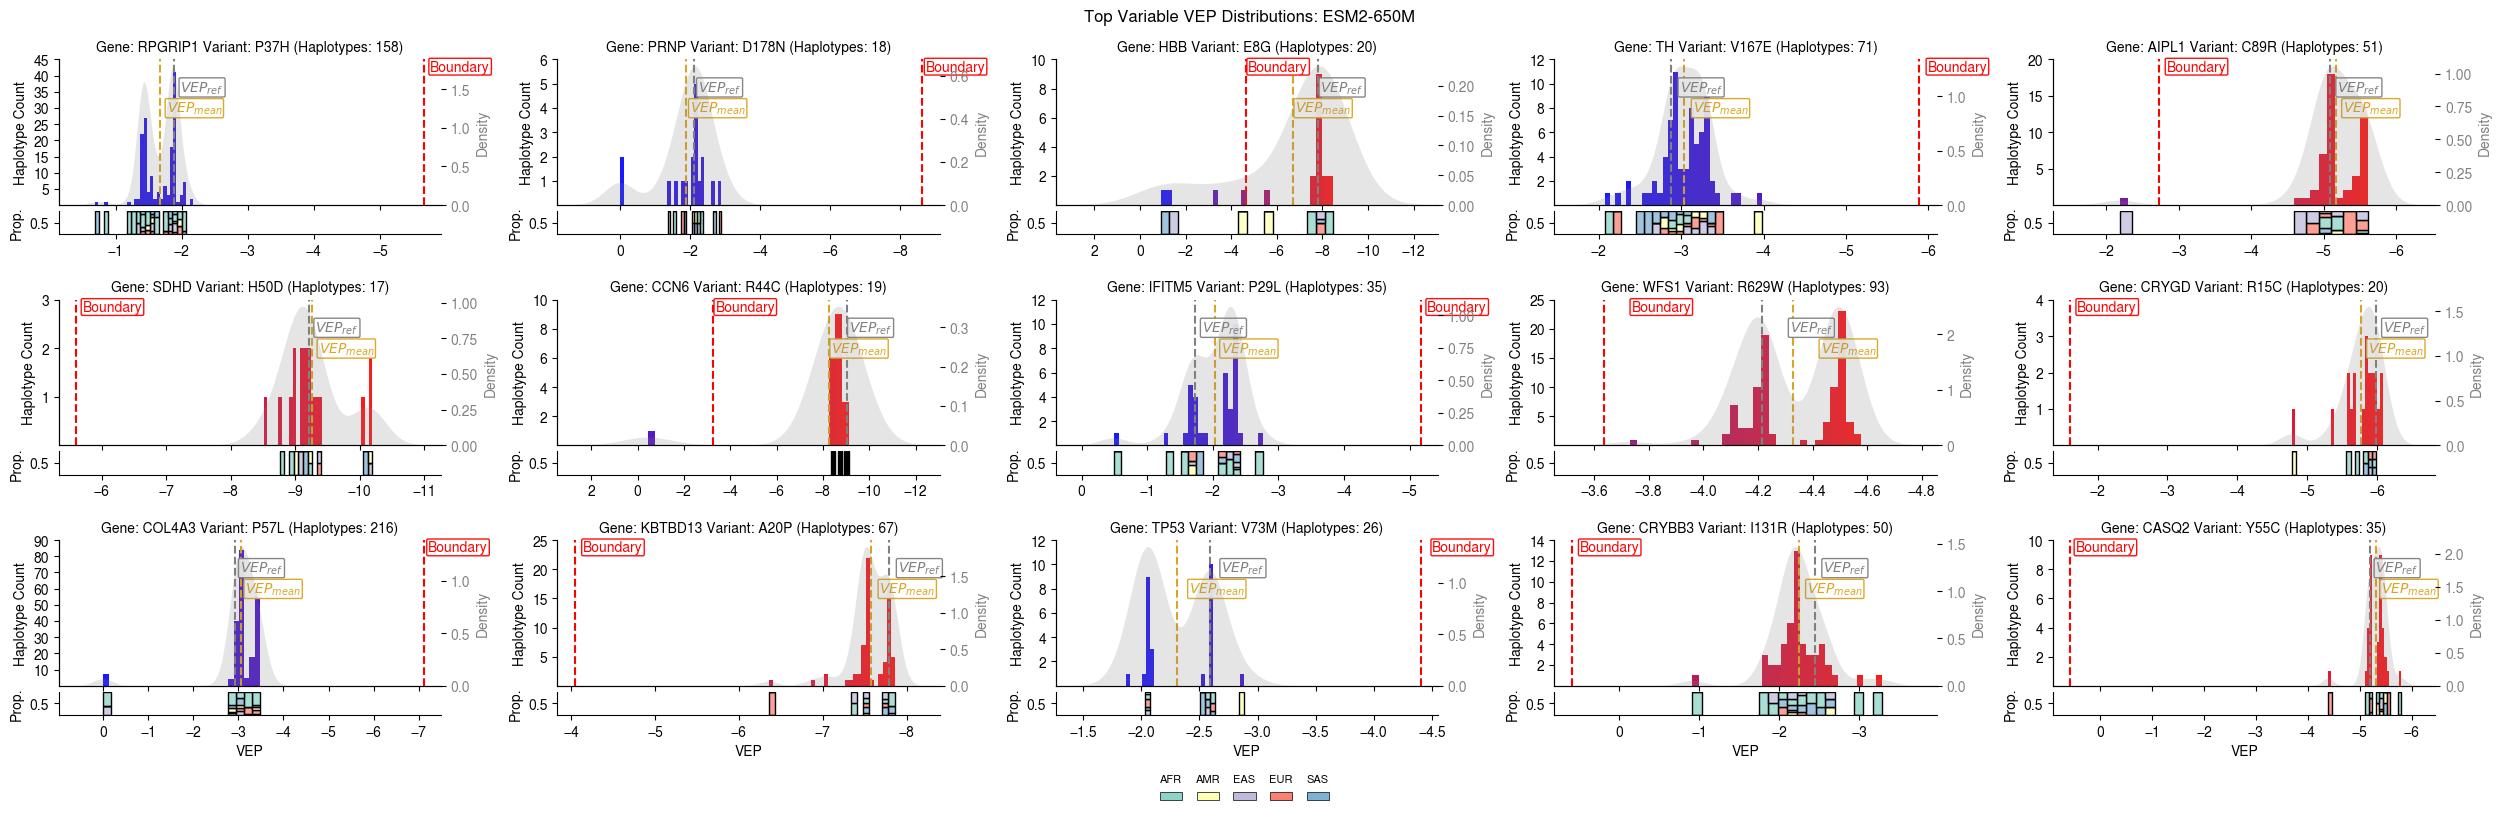

In [92]:
top_mad_sites = gmm.plot_vep_histograms_with_boundaries(vep_df=plot_df,
                                                        boundary_crossing_df=boundary_crossing_df,
                                                        target_sites=target_sites[:25],  
                                                        title="Top Variable VEP Distributions: ESM2-650M",

                                                        show_superpops=True,
                                                        superpop_height_ratio=0.2,
                                                        superpop_default_bins=20,
                                                        facet_row_spacing=0.65,


                                                        sharex=False,
                                                        sharey=False,
                                                          col_wrap=5,
                                                          facet_aspect=2, 
                                                          flip_xaxis=True,
                                                          palette=["red","blue"],
                                                        bins=30
                                                        )
top_mad_sites["fig"].savefig("manuscript/fig/esm2_boundaries_top_mad_extended.pdf", **utils.FIG_SAVE_KWARGS)

## Supp Figure: VEP normality/modality

### Subfigure C

Reference representativeness: VEP standard deviation.

Computing representativeness stats for VEP_percentile


<string>:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


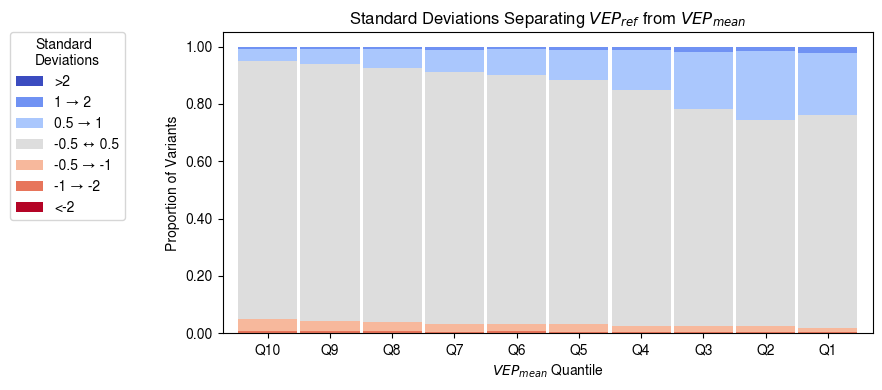

In [162]:
#### Standard Deviation version ####

# Limit to variants with normal VEP distributions
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
vep_sub = vep_df.merge(
    normality_results.loc[normality_results["pvalue"] >= 0.05],
    on=groupby_cols,
    how="left"
) 
fig_std = db.plot_ref_vep_std_stacked_bar(vep_sub, flip_xaxis=True, add_arrows=False)
fig_std['fig'].savefig("manuscript/fig/ref_rep_bar_std_esm2.pdf", **utils.FIG_SAVE_KWARGS)

In [128]:
fig_std['data'].groupby('VEP_pct_group_cat').size() / fig_std['data'].groupby('VEP_pct_group_cat').size().sum()*100

/tmp/ipykernel_500173/94682268.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fig_std['data'].groupby('VEP_pct_group_cat').size() / fig_std['data'].groupby('VEP_pct_group_cat').size().sum()*100
/tmp/ipykernel_500173/94682268.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fig_std['data'].groupby('VEP_pct_group_cat').size() / fig_std['data'].groupby('VEP_pct_group_cat').size().sum()*100


VEP_pct_group_cat
<-2            0.072744
-1 → -2        1.169227
-0.5 → -1     12.228097
-0.5 ↔ 0.5    83.291934
0.5 → 1        2.677336
1 → 2          0.455981
>2             0.104680
dtype: float64

### Subfigure D

VEP distribution UMAP.

In [129]:
ecdf_umap_df, vep_ecdf_pivot = db.ecdf_to_umap(vep_ecdf)

Running UMAP


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Mon Oct  6 22:27:35 2025 Construct fuzzy simplicial set
Mon Oct  6 22:27:35 2025 Finding Nearest Neighbors
Mon Oct  6 22:27:35 2025 Building RP forest with 16 trees
Mon Oct  6 22:27:39 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Mon Oct  6 22:27:49 2025 Finished Nearest Neighbor Search
Mon Oct  6 22:27:51 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Oct  6 22:28:10 2025 Finished embedding


Compute UMAP.

In [130]:
ecdf_umap_df, vep_ecdf_pivot =  db.cluster_and_annotate_umap(ecdf_umap_df, 
                                                             vep_ecdf_pivot,  
                                                             n_samples=None, 
                                                             method='kmeans',
                                                             n_clusters=20,
                                                            #  cluster_on_umap=True,
                                                            #  cluster_kwargs={'eps':.01, 'min_samples':100},
                                                             show_dendrogram=False)

Number of clusters (kmeans): 20
Cluster distribution:
cluster
1     3050
2     2437
3     1138
4     2293
5     1750
6     1977
7     2470
8     2052
9     1868
10    1694
11    2267
12    2417
13    2386
14    2106
15    2709
16    2756
17    2284
18    2715
19    2833
20    2580
Name: count, dtype: int64


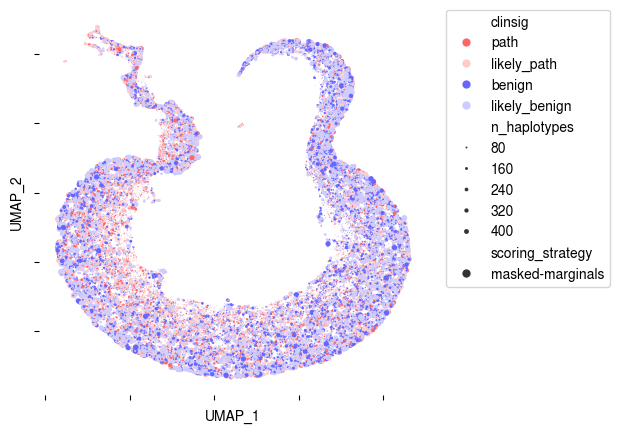

In [ ]:
fig_umap_clinsig = db.plot_cluster_umap(ecdf_umap_df,  
                     hue_var="clinsig",
                     palette=utils.get_clinsig_palette(),
                     figsize=(5, 5))
fig_umap_clinsig['fig'].savefig("manuscript/fig/ecdf_umap_by_clinsig.pdf", **utils.FIG_SAVE_KWARGS)                    

### Subfigure E

/home/schilder/projects/VEP_protein/src/analysis/distributions.py:890: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  linewidth=2.0


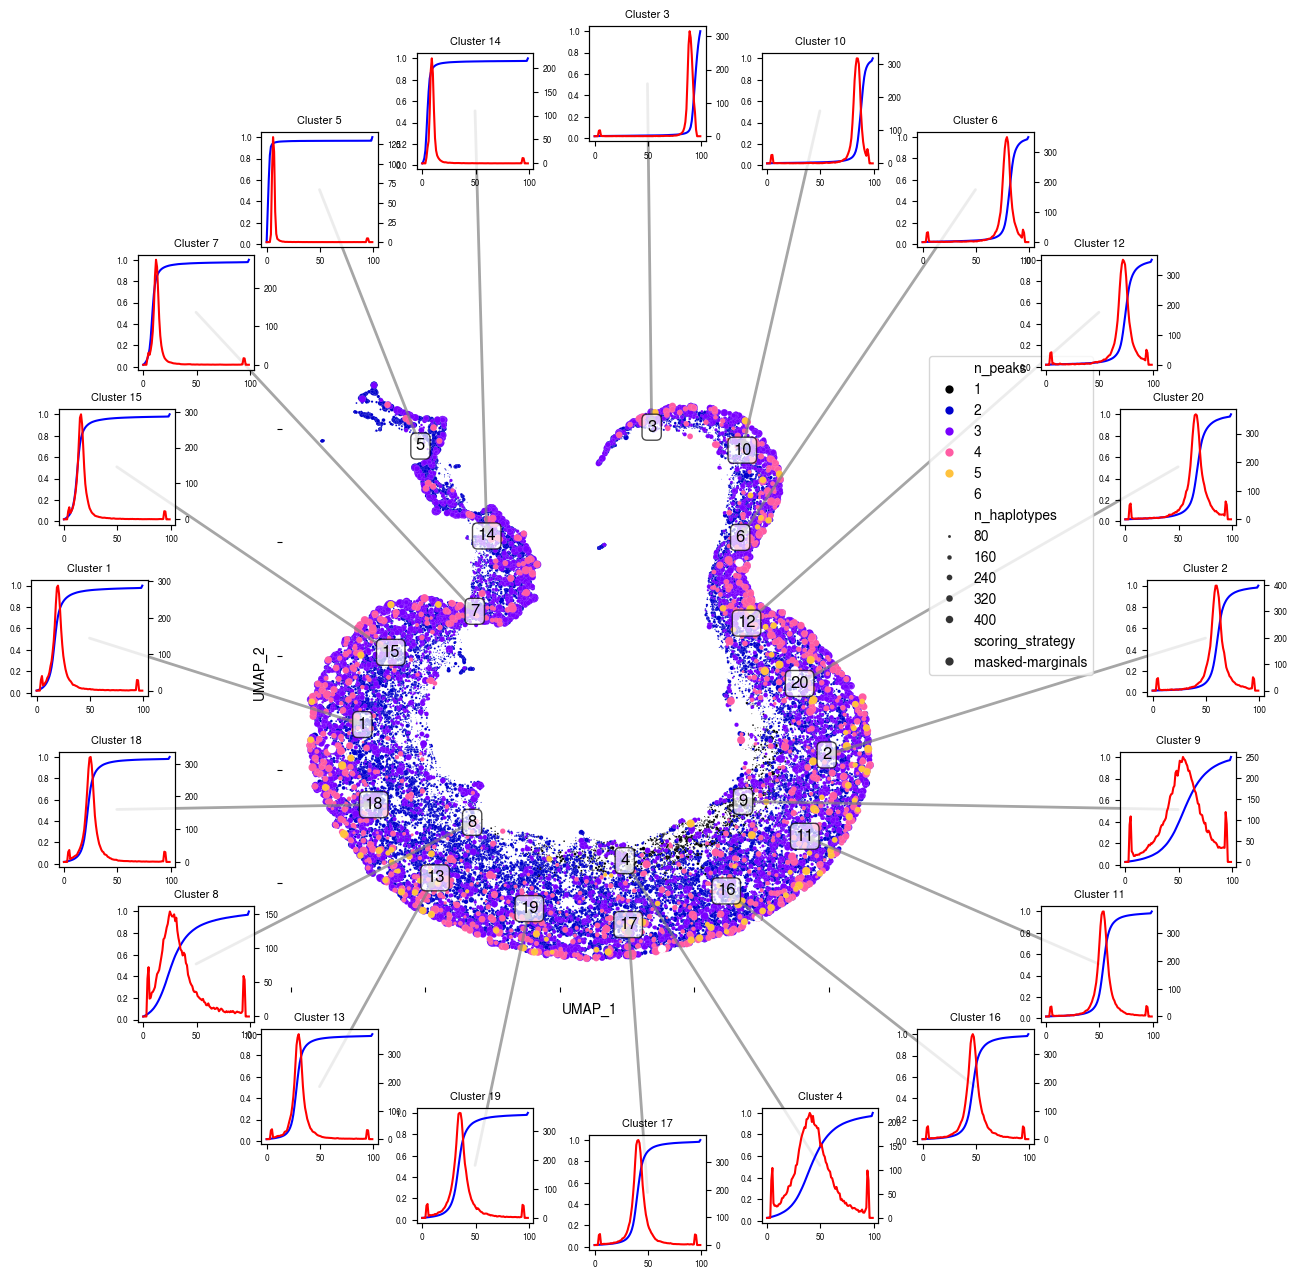

In [134]:
fig_umap_modality = db.plot_cluster_umap_with_distribution_plots(ecdf_umap_df.sort_values(by='n_peaks', ascending=True),
                                                       vep_ecdf, 
                                                       vep_ecdf_pivot, 
                                                      hue='n_peaks',
                                                      palette="gnuplot2",  
                                                      line_color="grey", 
                                                      figsize=(10, 10),
                                                       sizes=(.0001, 35), 
                                                        min_distance=0.8, 
                                                        connector_alpha=0.7)
fig_umap_modality['fig'].savefig("manuscript/fig/ecdf_umap_by_modality.pdf", **utils.FIG_SAVE_KWARGS)

## Supplementary Figure: 

In [320]:
if "VEP_REF" not in vep_df.columns:
    vep_df = va.compute_representativeness_stats(vep_df, is_ref=False)

if "freq_df" not in globals():
    haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                            as_df=True,
                                            add_sample_metadata=True,
                                            return_seqs=False, 
                                            add_ref=False, 
                                            duplicate_ref=False,
                                            verbose=True,
                                            )

    freq_df = hs.calculate_haplotype_frequency_per_superpop(
        haps_to_samples,
        cast=True, 
        verbose=True,
        add_specificity_cols=True
    )

Computing representativeness stats for VEP_percentile


In [321]:
max_rows=20
sample_head_and_tail=True
is_ref_filter=True
abs_diff_threshold=1
x="VEP_mean_diff" 



if "n_haplotypes" not in vep_df.columns:
    vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy","protein", "mutant"])["haplotype"].transform("nunique")
vep_df["Gene"] = vep_df["GENEINFO"].str.split(":").str[0]

diff_df = vep_df.copy()

if is_ref_filter is not None:
    diff_df = diff_df.loc[diff_df["is_ref"] ==is_ref_filter]

# Find variants where the REF was +/- 1 VEP unit from the mean
# (If x is not "VEP_mean_diff", still filter by VEP_mean_diff for consistency)
if abs_diff_threshold is not None:
    diff_df = diff_df.loc[((diff_df[x] > abs_diff_threshold) | (diff_df[x] < -abs_diff_threshold))]

# Merge in mean_freq if freq_df is provided
if freq_df is not None:
    freq_cols = [col for col in freq_df.columns if col.endswith("_freq") and col != "top_superpopulation_freq"]
    total_hap_freqs = freq_df.set_index("haplotype")[freq_cols].mean(axis=1).reset_index().rename(columns={0: "mean_freq"})
    diff_df = diff_df.merge(total_hap_freqs, on=["haplotype"], how="left")


diff_df = utils.sort_by_clinsig(diff_df)
diff_df[x+"_abs"] = diff_df[x].abs()
diff_df.sort_values(by=x, ascending=False, inplace=True)

if max_rows is not None: 
    if sample_head_and_tail:
        diff_df = pd.concat([diff_df.head(max_rows//2), 
                                diff_df.tail(max_rows//2)])
    else:
        diff_df = diff_df.head(max_rows)

print(diff_df.groupby(["model_location", "scoring_strategy"], observed=True).agg({"mutant": pd.Series.nunique, "protein": pd.Series.nunique}))

diff_df["Gene"] = diff_df["GENEINFO"].str.split(":").str[0]
diff_df.head()

                                      mutant  protein
model_location      scoring_strategy                 
esm2_t33_650M_UR50D masked-marginals      20        9


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,VEP_percentile,VEP_std,VEP_mean,VEP_mean_diff,VEP_REF,VEP_ref_diff,n_haplotypes,mean_freq,VEP_mean_diff_abs
132,ENSP00000344757:REF,NP_937799.1,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,C121F,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,Pathogenic,-0.743655,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000344757,ENST00000345392,False,NP_937799.1:C121F,3,10149808,43604,G,T,.,PASS,43604,3:10149808,T,VHL,NM_198156.3,Transcript,missense_variant,432,362,121,C/F,tGc/tTc,-,MODERATE,-,1,-,-,-,G,G,-,NM_198156.3:c.362G>T,NP_937799.1:p.Cys121Phe,-,NaN,0.00001,52773,"MONDO:MONDO:0008667,MedGen:C0019562,OMIM:19330...",Von_Hippel-Lindau_syndrome|Chuvash_polycythemia,NC_000003.12:g.10149808G>T,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,VHL:7428|LOC107303340:107303340,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,397516444,NaN,ClinGen:CA020418|UniProtKB:P40337#VAR_005754,None,None,None,-5.868242,-5.022188,0.670082,-0.096898,4,path,73.333333,3.447009,-3.365415,2.621759,-0.743655,0.0,15,NaN,2.621759
133,ENSP00000344757:REF,NP_937799.1,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,C121W,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,Pathogenic,-0.874693,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000344757,ENST00000345392,False,NP_937799.1:C121W,3,10149809,223227,C,G,.,PASS,223227,3:10149809,G,VHL,NM_198156.3,Transcript,missense_variant,433,363,121,C/W,tgC/tgG,-,MODERATE,-,1,-,-,-,C,C,-,NM_198156.3:c.363C>G,NP_937799.1:p.Cys121Trp,-,NaN,NaN,224957,"MONDO:MONDO:0009892,MedGen:C1837915,OMIM:26340...",Chuvash_polycythemia|Von_Hippel-Lindau_syndrom...,NC_000003.12:g.10149809C>G,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,VHL:7428|LOC107303340:107303340,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,5030622,NaN,ClinGen:CA357016|UniProtKB:P40337#VAR_005756,None,None,None,-5.868242,-5.022188,-0.620578,-0.139289,4,path,73.333333,2.816355,-3.149899,2.275206,-0.874693,0.0,15,NaN,2.275206
131,ENSP00000344757:REF,NP_937799.1,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,C121Y,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,Pathogenic,-0.542314,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000344757,ENST00000345392,False,NP_937799.1:C121Y,3,10149808,223225,G,A,.,PASS,223225,3:10149808,A,VHL,NM_198156.3,Transcript,missense_variant,432,362,121,C/Y,tGc/tAc,-,MODERATE,-,1,-,-,-,G,G,-,NM_198156.3:c.362G>A,NP_937799.1:p.Cys121Tyr,-,NaN,NaN,224955,"MONDO:MONDO:0008667,MedGen:C0019562,OMIM:19330...",Von_Hippel-Lindau_syndrome,NC_000003.12:g.10149808G>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,VHL:7428|LOC107303340:107303340,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,397516444,NaN,ClinGen:CA357010|UniProtKB:P40337#VAR_005757,None,None,None,-5.868242,-5.022188,0.618526,-0.116856,4,likely_path,73.333333,2.921206,-2.753346,2.211033,-0.542314,0.0,15,NaN,2.211033
130,ENSP00000344757:REF,NP_937799.1,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,C121R,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,Pathogenic,-0.715974,masked-marginals,True,esm2_

### Median Absolute Variance ranking

In [322]:
from statsmodels import robust

tqdm.pandas()
mad_df = vep_df.groupby(["model_location", "scoring_strategy", "protein","Gene", "mutant", "site","clinsig"], observed=True).progress_apply(
    lambda x: robust.mad(x["VEP"], c=1)
).reset_index().rename(columns={0:"MAD"}).sort_values(by="MAD", ascending=False)


 99%|█████████▉| 55780/56364 [00:09<00:00, 9211.14it/s]/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 56364/56364 [00:09<00:00, 6067.58it/s]


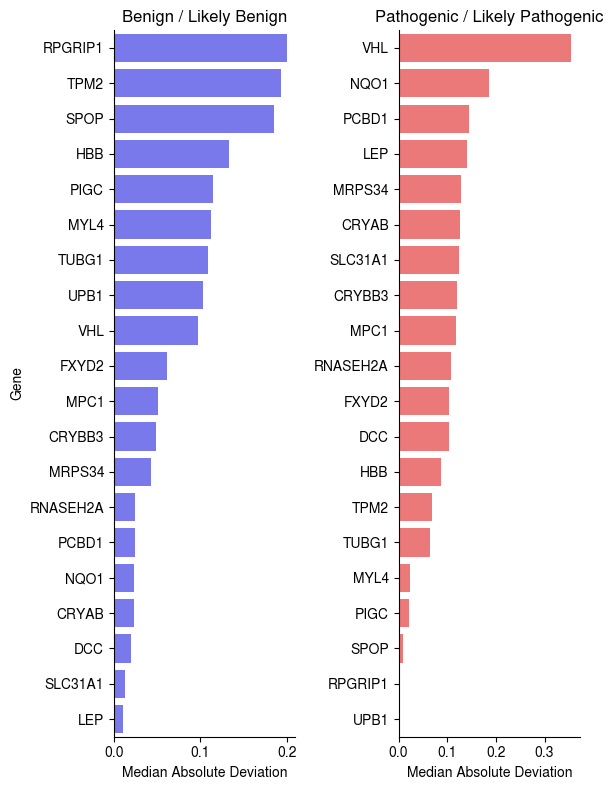

In [323]:
# Compute mean MAD per gene and clinsig
# Reassign "likely_benign" to "benign" and "likely_path" to "path" in the "clinsig" column
mad_df["clinsig"] = mad_df["clinsig"].replace({"likely_benign": "benign", "likely_path": "path"})

mad_plot_df = mad_df.groupby(["Gene", "clinsig"])["MAD"].mean().reset_index()

# Select top N genes by MAD in any clinsig category
top_n = 20
top_genes = (
    mad_plot_df.groupby("Gene")["MAD"].max()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)
mad_plot_df = mad_plot_df[mad_plot_df["Gene"].isin(top_genes)]

# Get clinsig categories in desired order
clinsig_order = utils.get_clinsig_order()
clinsig_present = [c for c in clinsig_order if c in mad_plot_df["clinsig"].unique()]
n_clinsig = len(clinsig_present)

# Create subfigures (one column per clinsig)
fig, axes = plt.subplots(1, n_clinsig, figsize=(3*n_clinsig, 8), sharey=False)
if n_clinsig == 1:
    axes = [axes]

for ax, clinsig in zip(axes, clinsig_present):
    data = mad_plot_df[mad_plot_df["clinsig"] == clinsig].sort_values("MAD", ascending=False)
    sns.barplot(
        data=data,
        x="MAD",
        y="Gene",
        hue="clinsig",
        palette=utils.get_clinsig_palette(),
        orient="h",
        ax=ax
    )
    ax.set_title("Benign / Likely Benign" if clinsig == "benign" else "Pathogenic / Likely Pathogenic")
    ax.set_xlabel("Median Absolute Deviation")
    if ax != axes[0]:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Gene")
    ax.legend().remove()
    # Remove top and right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



plt.tight_layout()


In [324]:
# plot_top_diff_variants_out2 = va.plot_top_diff_variants(vep_df, 
#                           freq_df, 
#                           x="VEP_ref_diff", 
#                           title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{hap}}$",
#                           max_rows=10,
#                           figsize=(14, None),
#                           sample_head_and_tail=True,
#                           arrow_bottom_margin=0.15,
#                           arrow_text_padding=0.025,
#                           table_width_ratio=2,
#                           is_ref_filter=None)
# plot_top_diff_variants_out2["fig"].savefig("manuscript/fig/top_diff_variants_VEPhap_diff.pdf", **utils.FIG_SAVE_KWARGS)

## Supplementary Figure: binary pathogenicity classifiers

Binary pathogenic/benign classifier results.

In [325]:
lr_dict = {} 
lr_gene_dict = {}
min_values_per_label= 10

ESM

In [326]:
# Gather data from each model and compute logreg results

#### Run for all models ####
from IPython.display import clear_output
force = False

for model_location in va.list_all_models():
    print(f"Processing {model_location}") 
    save_path = os.path.join("results/data/","vep_df_"+model_location+".parquet")
    
    if os.path.exists(save_path) and not force:
        print(f"Loading {save_path}")
        vep_tmp = pd.read_parquet(save_path)
    else:
        vep_files_model = va.list_vep_files(model_location=model_location, as_df=True)
        vep_tmp = va.merge_vep(add_metadata=True, 
                                scoring_strategy=["masked-marginals"], 
                                vep_files=vep_files_model
                                )
        print(f"Saving {save_path}")
        vep_tmp.to_parquet(save_path)

    # Run logreg analysis
    lr_dict[model_location] = bcv.run_clinvar_logreg_analysis(vep_tmp, 
                                                                clinsig_col="clinsig",
                                                                site_col="site") 

    lr_gene_dict[model_location] = bcv.run_clinvar_logreg_analysis_by_group(vep_tmp, 
                                                group_by="protein",
                                                vep_col="VEP",
                                                clinsig_col="clinsig",
                                                min_values_per_label=min_values_per_label,
                                                site_col="site" ) 
    clear_output()
del vep_tmp

#### Run for just the main ESM model ####
# lr_dict[model_name] = bcv.run_clinvar_logreg_analysis(vep_df, 
#                                             clinsig_col="clinsig",
#                                             site_col="site") 
# lr_gene_dict[model_name] = bcv.run_clinvar_logreg_analysis_by_group(vep_df, 
#                                                 group_by="protein",
#                                                 vep_col="VEP",
#                                                 clinsig_col="clinsig",
#                                                 min_values_per_label=min_values_per_label,
#                                                 site_col="site" )
    

SpliceAI

In [330]:
lr_dict['SpliceAI'] = bcv.run_clinvar_logreg_analysis(spliceai_df, 
                                                        clinsig_col="CLNSIG_simplified",
                                                        site_col="site")  

Running logistic regression for REF
Running logistic regression for non-REF


In [338]:
lr_gene_dict['SpliceAI']= bcv.run_clinvar_logreg_analysis_by_group(spliceai_df, 
                                                                    group_by="protein",
                                                                    vep_col="VEP",
                                                                    clinsig_col="CLNSIG_simplified",
                                                                    min_values_per_label=min_values_per_label)

Groups:   0%|          | 0/1836 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Flashzoi

In [339]:
lr_dict['Flashzoi'] = bcv.run_clinvar_logreg_analysis(flashzoi_df, 
                                                        clinsig_col="CLNSIG_simple",
                                                        site_col="site") 

Running logistic regression for REF
Running logistic regression for non-REF


In [340]:
lr_gene_dict['Flashzoi'] = bcv.run_clinvar_logreg_analysis_by_group(flashzoi_df, 
                                                                    group_by="protein",
                                                                    vep_col="VEP",
                                                                    clinsig_col="CLNSIG_simple",
                                                                    min_values_per_label=min_values_per_label)

Groups:   0%|          | 0/1464 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Uncorrected for gene bias.

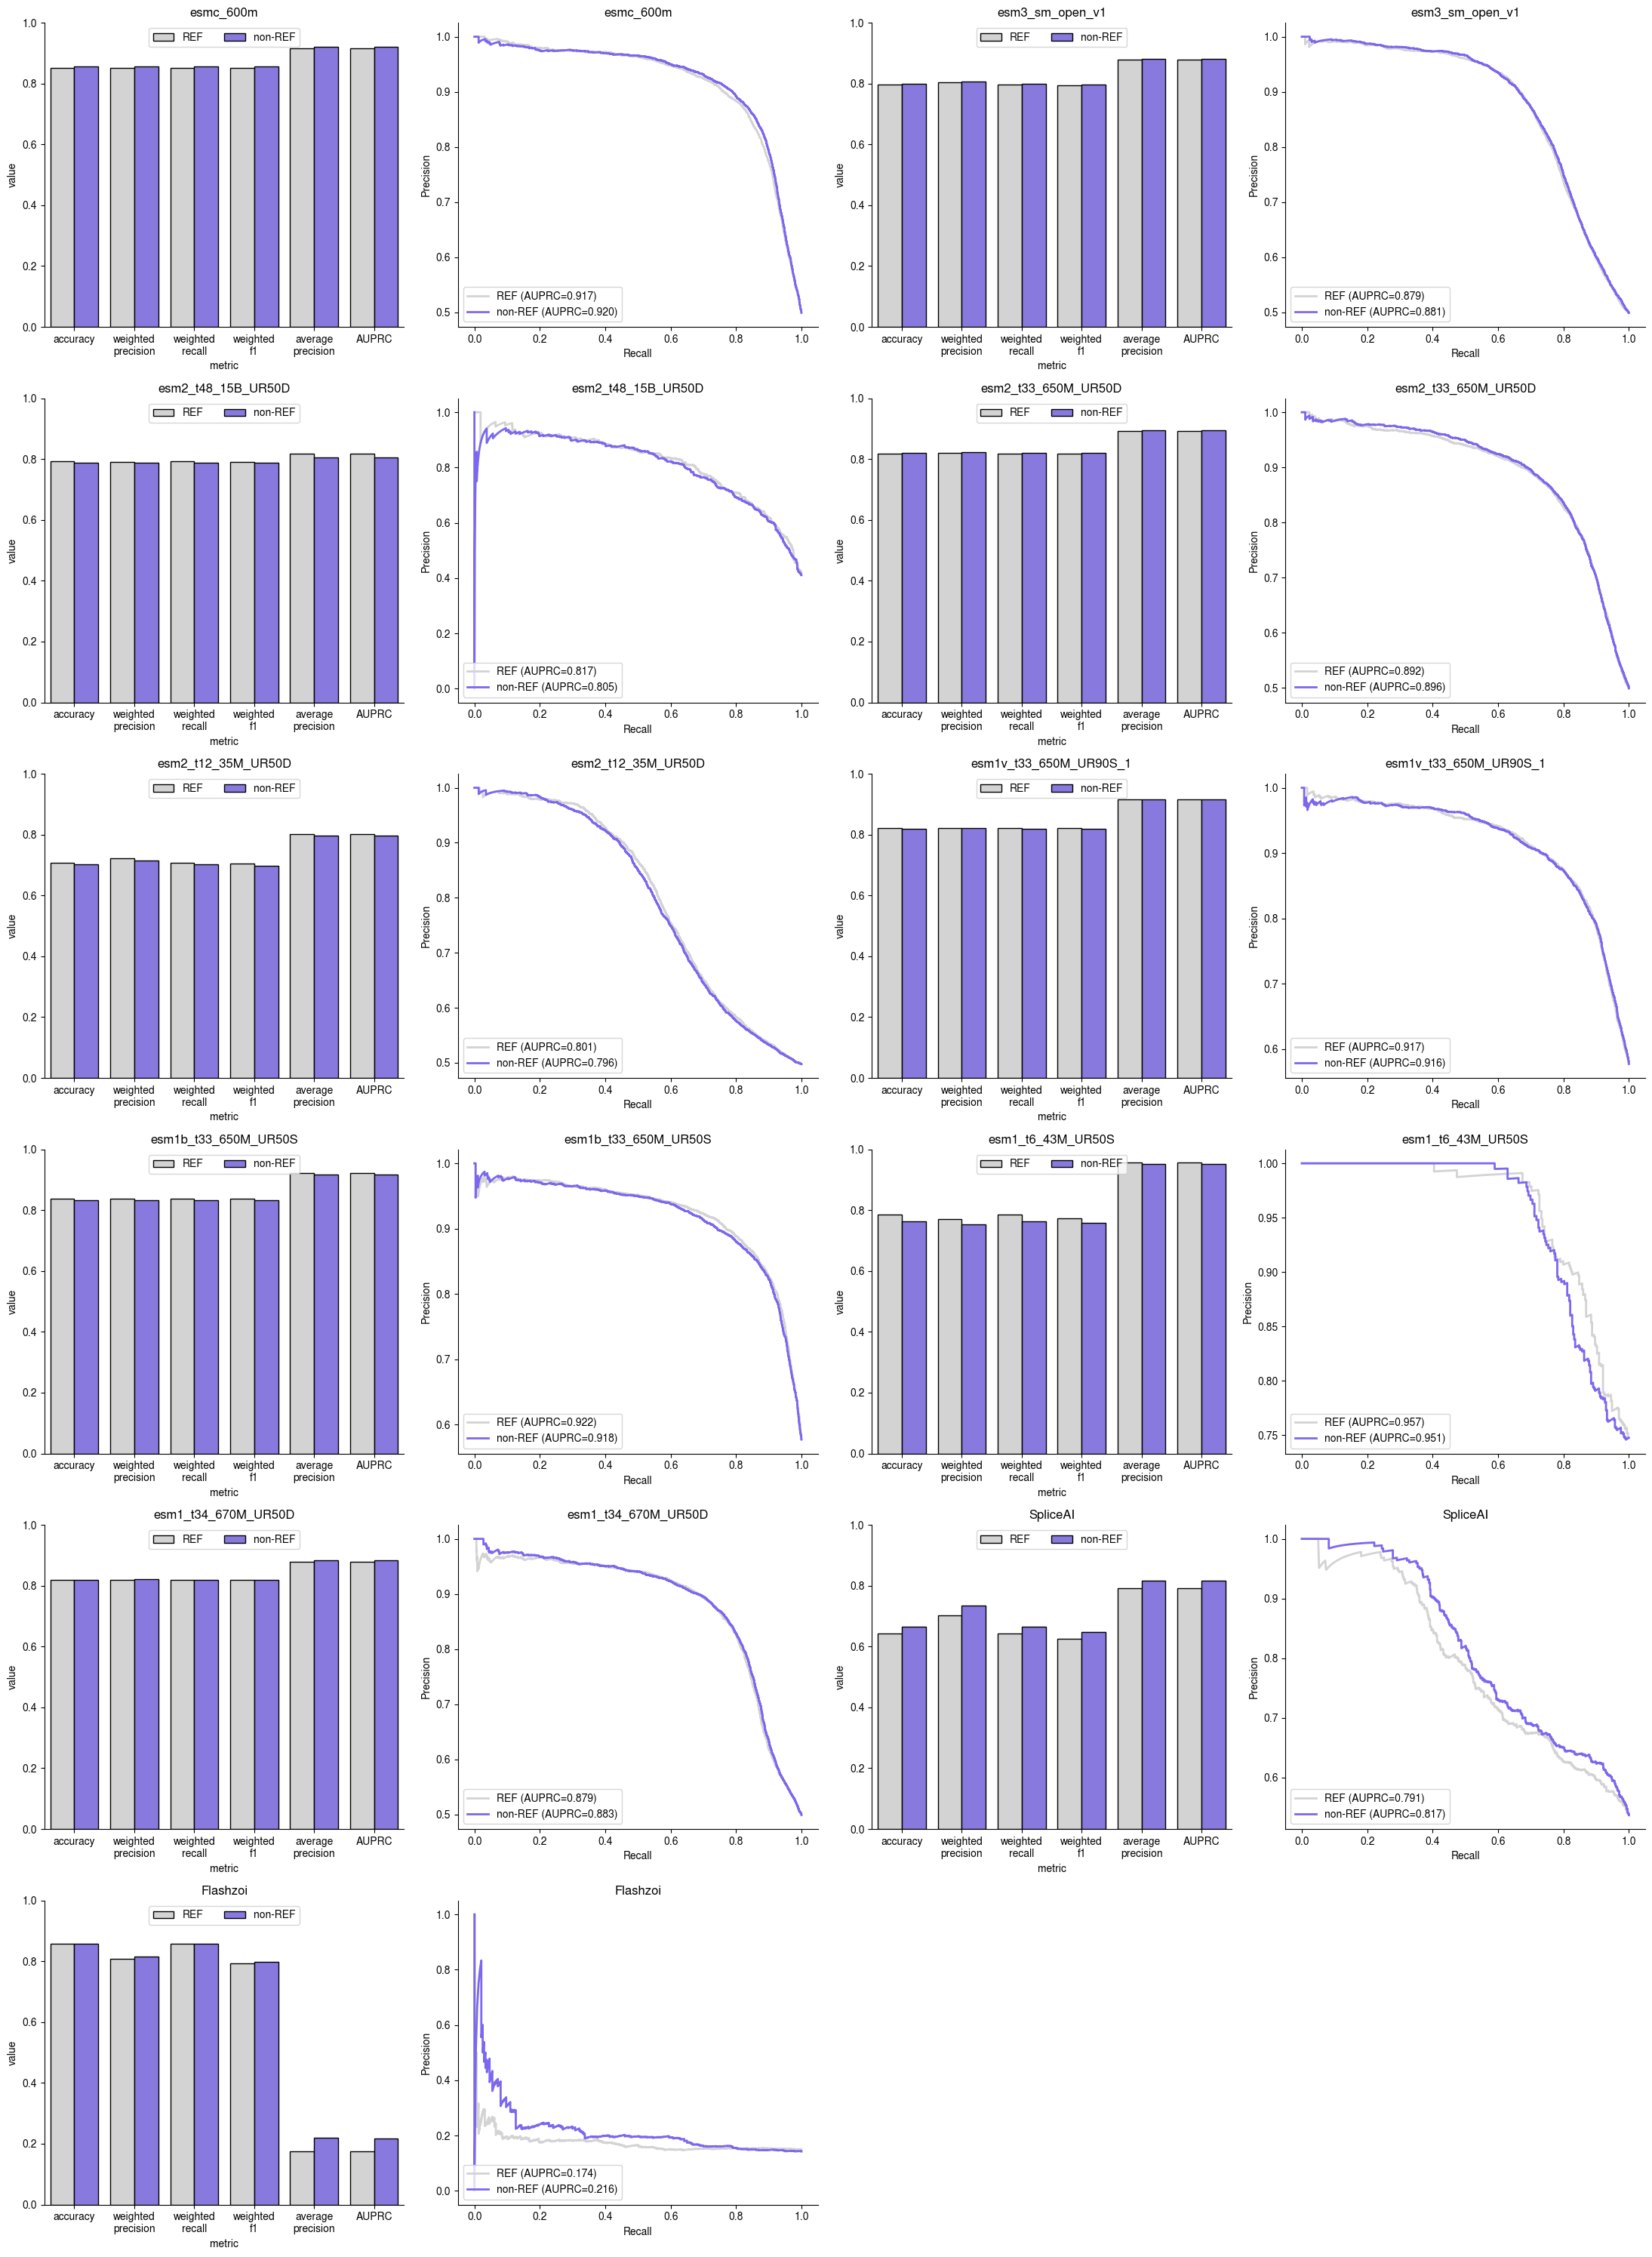

In [344]:
plot_logreg_results_subplots_out = bcv.plot_logreg_results_subplots(
      palette=utils.get_ref_nonref_palette(),
    data_dict = lr_dict,
    figsize = (11, 5),
    colwrap=2
)
plot_logreg_results_subplots_out["fig"].savefig("manuscript/fig/logreg_subplots.pdf", **utils.FIG_SAVE_KWARGS)

In [342]:
# Determine if non-REF beats REF for each model/metric
pivot_df = plot_logreg_results_subplots_out["data"]["barplot_df"].pivot_table(
    index=["model", "metric"],
    columns="group_id",
    values="value"
).reset_index()
pivot_df["nonREF_beats_REF"] = pivot_df["non-REF"] > pivot_df["REF"] 
print("Proportion of models/metrics where non-REF beats REF:",pivot_df["nonREF_beats_REF"].sum() / pivot_df.shape[0] * 100)

Proportion of models/metrics where non-REF beats REF: 54.54545454545454


Corrected for gene bias.

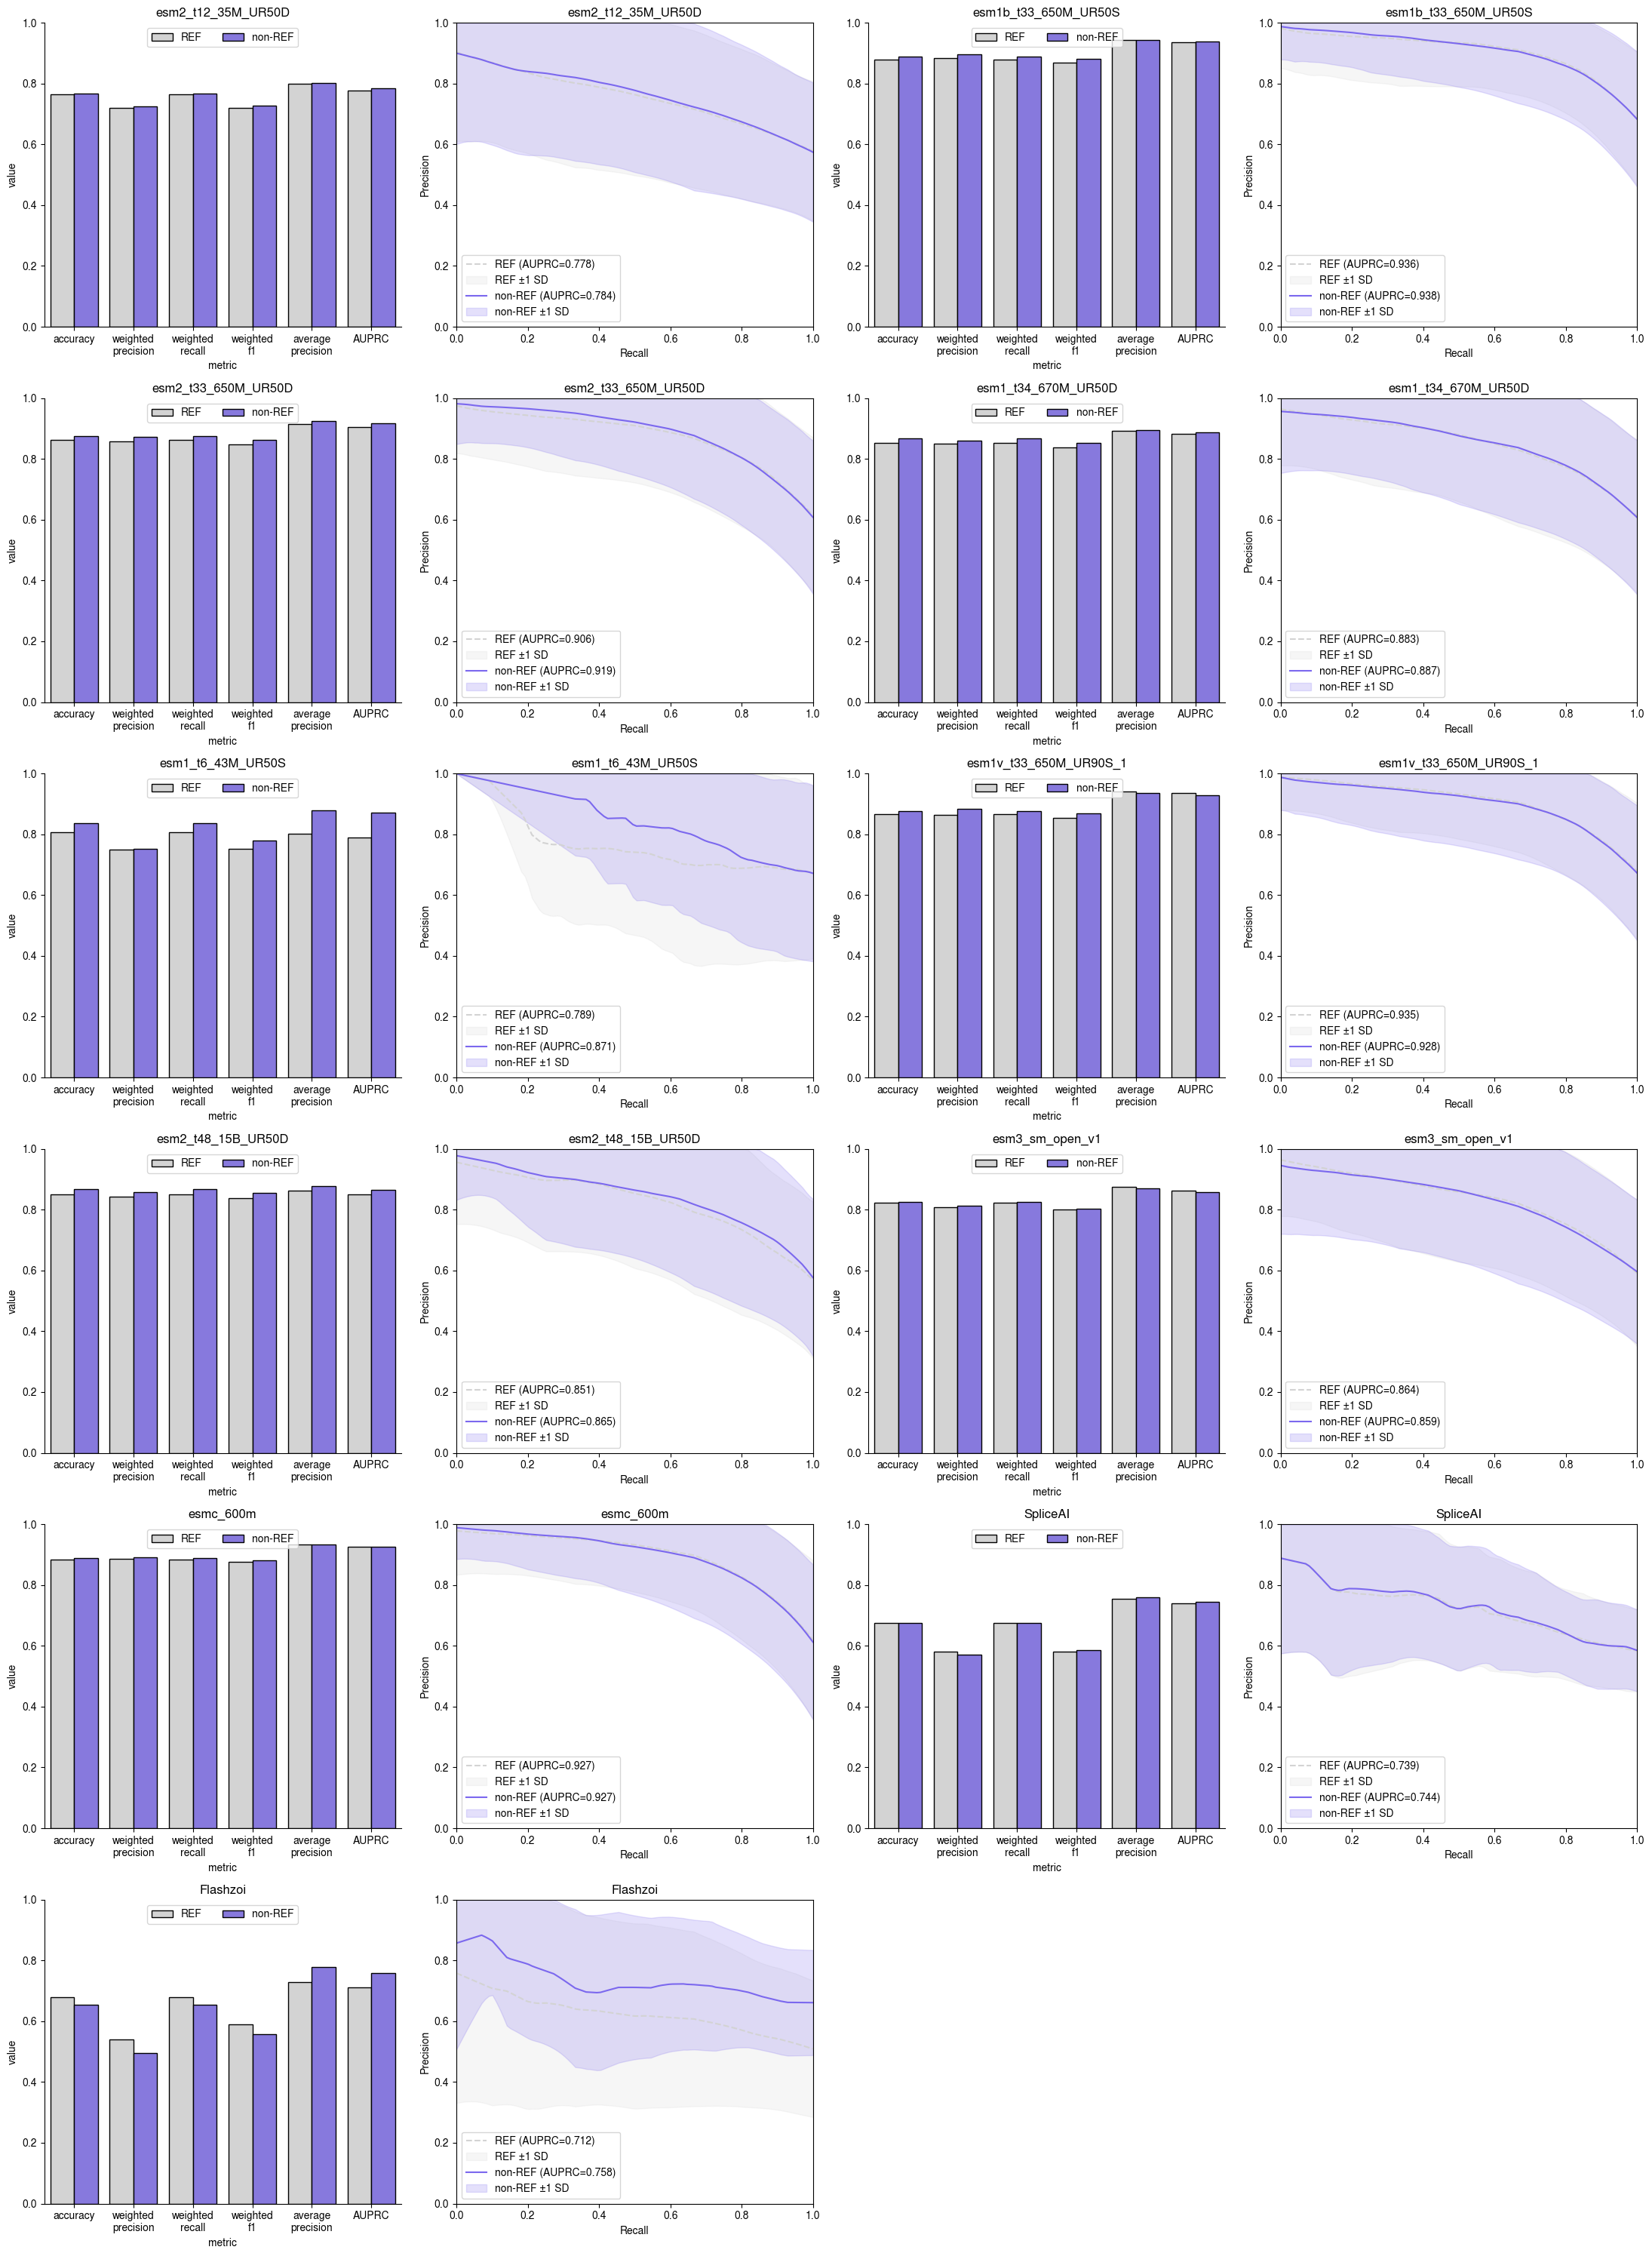

In [345]:
plot_logreg_gene_subplots_out = bcv.plot_logreg_gene_subplots(
    palette=utils.get_ref_nonref_palette(),
    data_dict = lr_gene_dict,
    figsize = (11, 5),
    colwrap=2
)
plot_logreg_gene_subplots_out["fig"].savefig("manuscript/fig/logreg_gene_subplots.pdf", **utils.FIG_SAVE_KWARGS)

In [ ]:
# Determine if non-REF beats REF for each model/metric
pivot_df = plot_logreg_gene_subplots_out["data"]["barplot_df"].pivot_table(
    index=["model", "metric"],
    columns="group_id",
    values="value"
).reset_index()
pivot_df["nonREF_beats_REF"] = pivot_df["non-REF"] > pivot_df["REF"] 
print("Proportion of models/metrics where non-REF beats REF:",pivot_df["nonREF_beats_REF"].sum() / pivot_df.shape[0] * 100)

Proportion of models/metrics where non-REF beats REF:  80.3030303030303


## Supplementary Figure: BRCA1 protein

#### Subfigure A

BRCA1 inter-haplotype variance 

In [143]:
uniprot_ids = {"BRCA1":"P38398", 
               "DYPD":"Q12882"}
tx_ids = {"BRCA1":"ENST00000357654", 
          "DYPD":"ENST00000370192"}
refseq_ids = {"BRCA1": 'NP_009225.1',
              "DYPD": 'NP_000101.2'}

# Get specific instance of the protein
target_gene = "BRCA1" # DYPD
uniprot_id = uniprot_ids[target_gene]
refseq_id = refseq_ids[target_gene]
tx_id = tx_ids[target_gene] 

base_dir = os.path.expanduser("~/projects/data/colabfold")

pdb_files = cf.search_files(base_dir = base_dir,
                         tx_id = tx_id,
                         subdir = "af2_sameMSA",
                         suffix = ".pdb*",
                         model_number = 1) 
contact_maps = cf.import_contact_maps(pdb_files,
                                      return_distance_map=True,
                                      continuous=True)
# # Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
# msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
# contact_maps = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps, 
#                                                      msa=msa) 


126 PDB files found


100%|██████████| 126/126 [00:24<00:00,  5.20it/s]


Variance map shape: (1863, 1863)
Variance range: 1.551201 to 26.413010


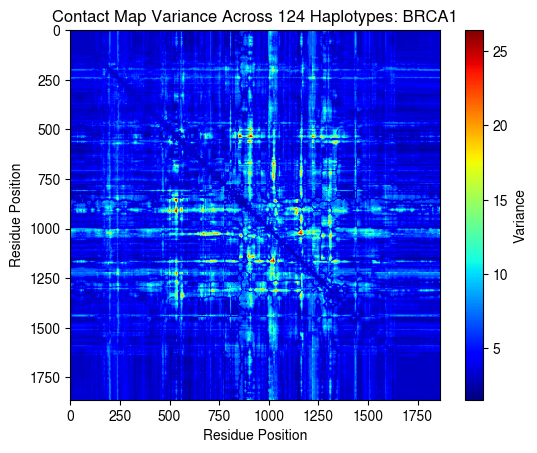

In [210]:
# Compute variance across all contact maps to find maximally variable regions
import numpy as np

# Stack all contact maps into a 3D array
ref_len = len(contact_maps[cf.get_ref_key(contact_maps)])
contact_maps_array = np.stack([x for x in contact_maps.values() if len(x) == ref_len])

# Compute variance across the first dimension (across all contact maps)
variance_map = np.var(contact_maps_array, axis=0)

print(f"Variance map shape: {variance_map.shape}")
print(f"Variance range: {np.nanmin(variance_map):.6f} to {np.nanmax(variance_map):.6f}")


# Plot the variance map to visualize regions of high variability
fig = plt.figure()

variance_map_binned = cf.mc.bin_matrix(variance_map, bin_size=1)
plt.imshow(variance_map_binned, cmap='jet', interpolation='nearest')
plt.colorbar(label='Variance')
plt.title(f'Contact Map Variance Across {contact_maps_array.shape[0]} Haplotypes: {target_gene}')
plt.xlabel('Residue Position')
plt.ylabel('Residue Position')
plt.show()

fig.figure.savefig("manuscript/fig/brca1_contact_map_variance.pdf", **utils.FIG_SAVE_KWARGS)

### Get Predicted Aligned Error (PAE)

📘 What is PAE?
- predicted_aligned_error[i, j] = expected positional error in Ångströms at residue i when the predicted and true structures are aligned on residue j

- Asymmetric matrix: PAE[i,j] ≠ PAE[j,i]

- Useful for identifying flexible domains or low-confidence interdomain contacts

In [ ]:
import glob

base_dir = os.path.expanduser("~/projects/data/colabfold")
pae_files = glob.glob(os.path.join(base_dir,
                                   tx_id,
                                   "**", 
                                "af2_sameMSA/*_predicted_aligned_error_v1.json*"
                                   ),
                       recursive=True)
if len(pae_files) == 0:
    raise ValueError(f"No PAE files found for {tx_id}")

# Load PAE data from JSON file
pae_matrices = {}
for pae_file in tqdm(pae_files, desc="Loading PAE matrices"):
    pae_data = utils.load_json(pae_file, verbose=False)

    # Extract PAE matrix from the JSON structure
    # The exact structure depends on the JSON format, but typically it contains a 2D array
    if 'predicted_aligned_error' in pae_data:
        pae_matrices[pae_file] = np.array(pae_data['predicted_aligned_error']) 
    

Loading PAE matrices:   0%|          | 0/123 [00:00<?, ?it/s]

Loading PAE matrices: 100%|██████████| 123/123 [01:03<00:00,  1.94it/s]


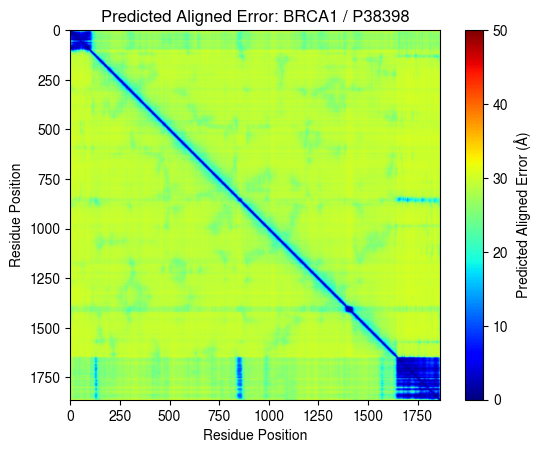

In [190]:
pae_matrix = np.mean(np.array(list(pae_matrices.values())), axis=0)
     
fig = plt.figure()
from matplotlib import colors
plt.imshow(pae_matrix, cmap="jet", vmin=0, vmax=50
             #  norm=colors.PowerNorm(gamma=10)
             )
plt.colorbar(label="Predicted Aligned Error (Å)")
plt.title(f"Predicted Aligned Error: {target_gene} / {uniprot_id}")
plt.xlabel("Residue Position")
plt.ylabel("Residue Position")
plt.show()

fig.savefig("manuscript/fig/brca1_predicted_aligned_error.pdf", **utils.FIG_SAVE_KWARGS)

Pearson correlation: 0.0962 (p-value: 6.1992e-72)
Spearman correlation: 0.0422 (p-value: 4.1985e-15)
Linear fit R2: 0.0093

Interpretation: There is a weak positive correlation between PAE matrix and variance map values.


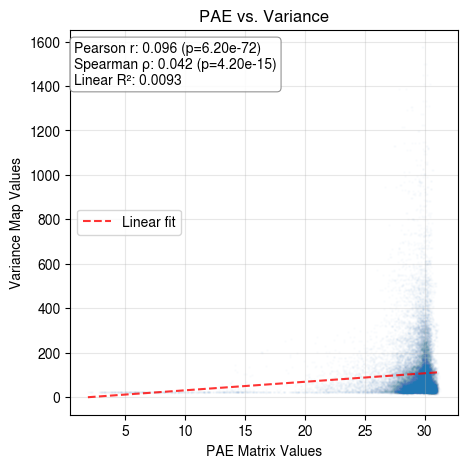

In [200]:
test_pae_variance_correlation_out = cf.test_pae_variance_correlation(
    pae_matrix, 
    variance_map, 
    rasterize_points=True,
    fit_exponential=False, 
    bin_size=10,
    log_x=False,   # Set to True to log-transform x (PAE)
    log_y=False    # Set to True to log-transform y (variance)
)
test_pae_variance_correlation_out["fig"].savefig("manuscript/fig/brca1_pae_variance_correlation.pdf", **utils.FIG_SAVE_KWARGS)

ValueError: too many values to unpack (expected 2)

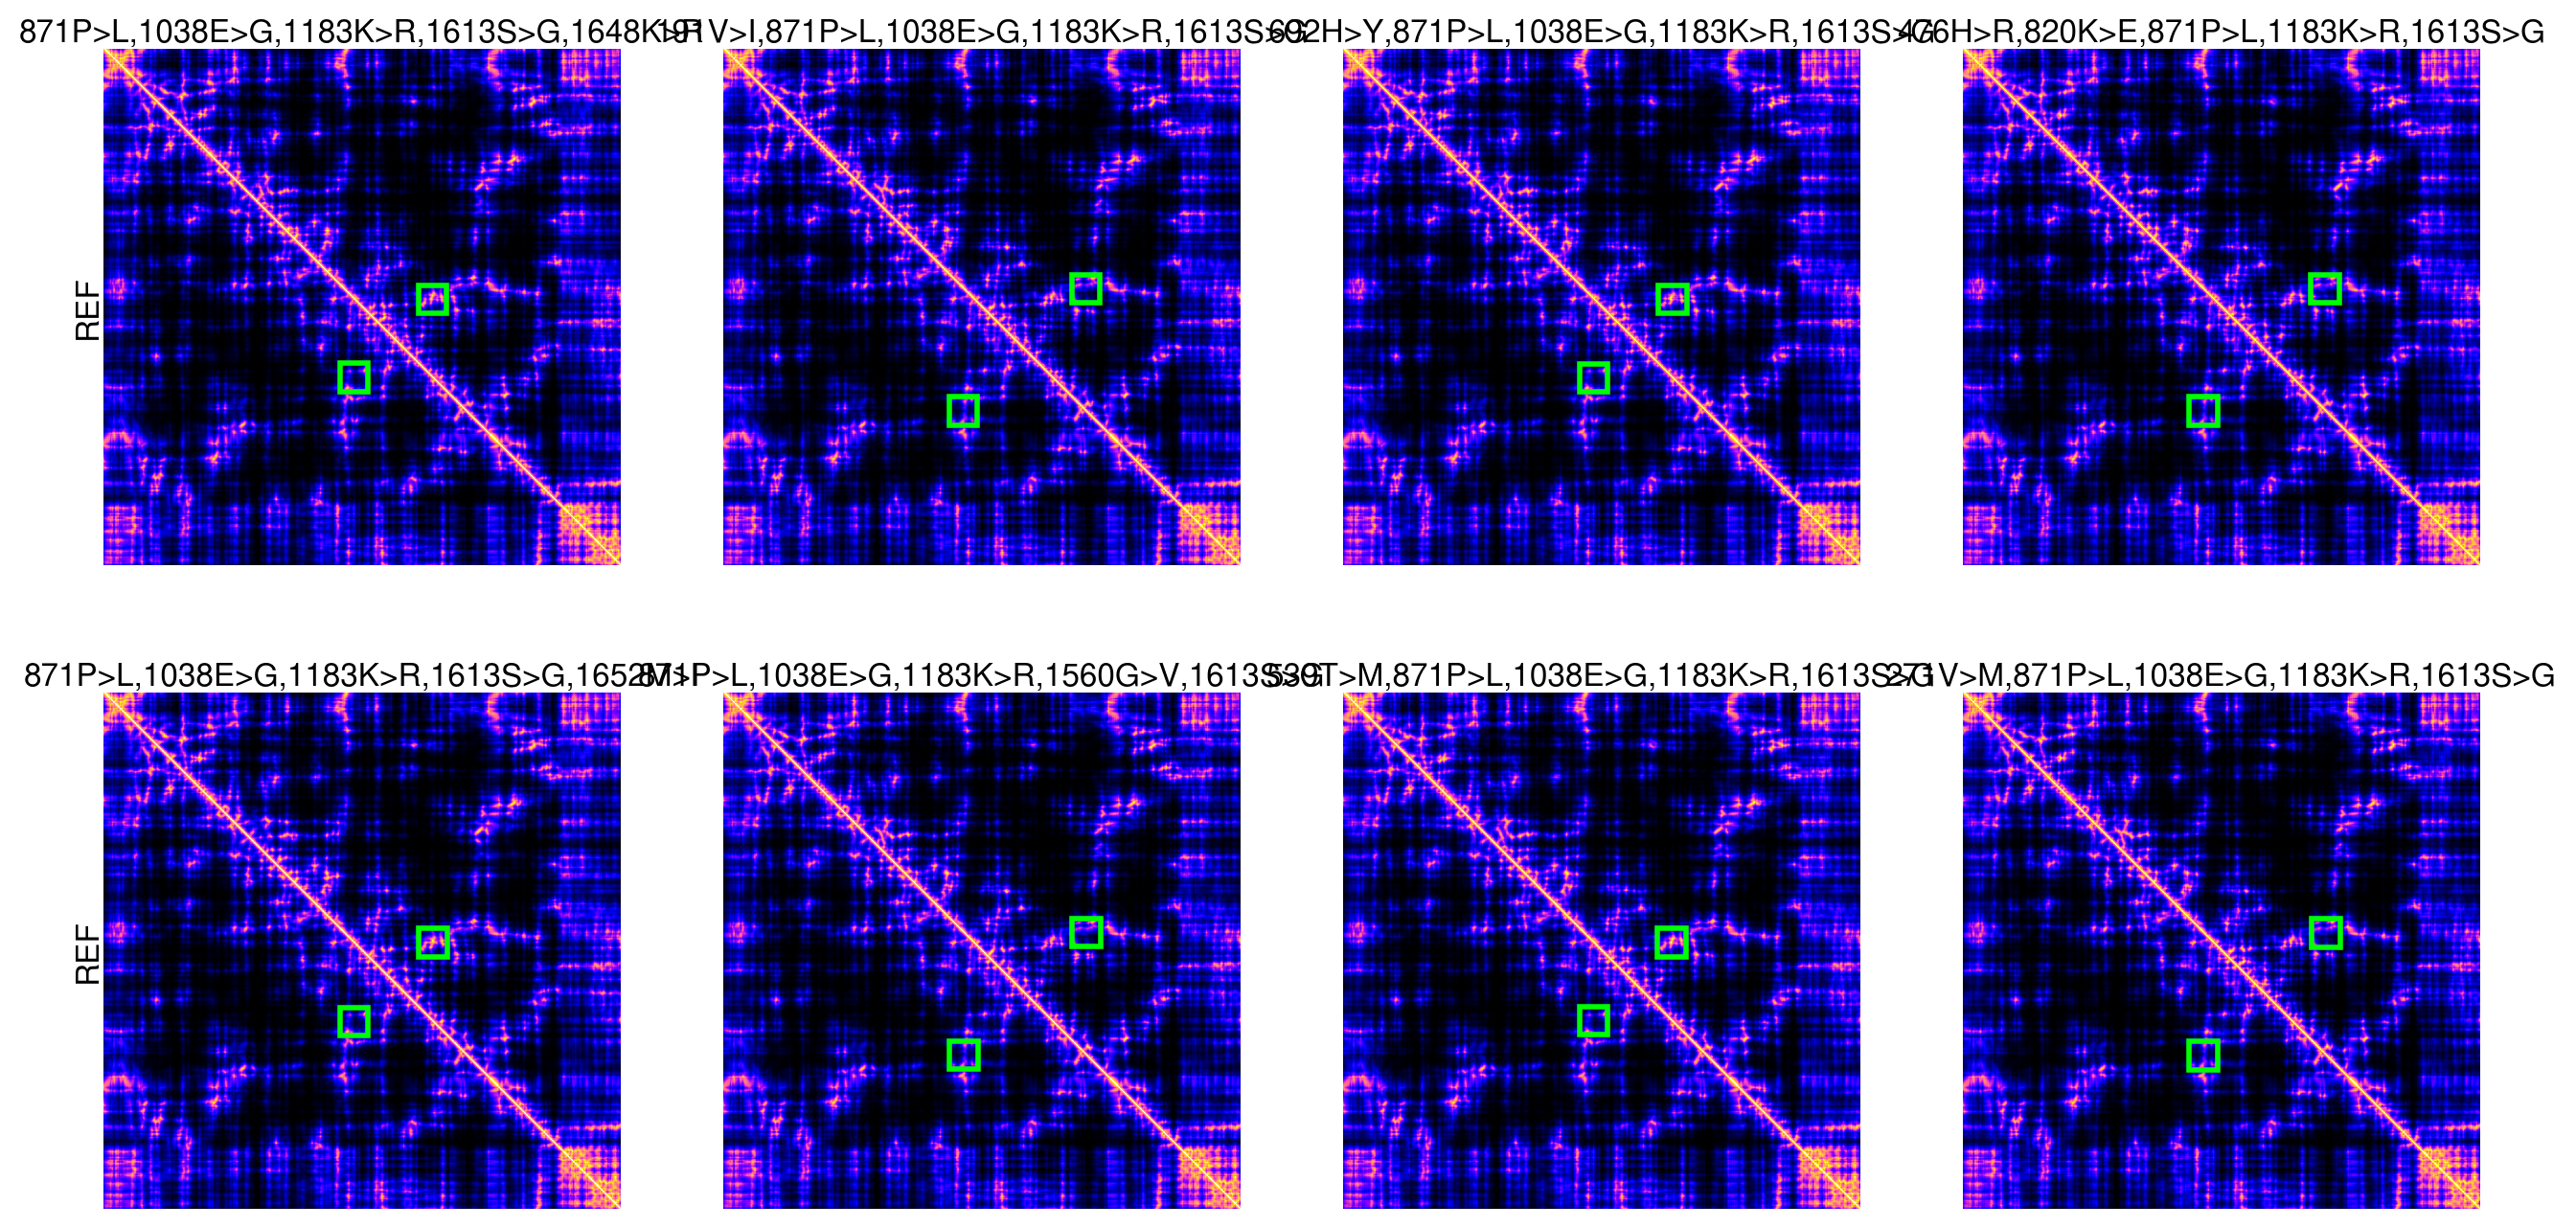

In [204]:
cf.plot_most_different_contact_maps(contact_maps, 
                                    max_subplots=9, 
                                    pow=4, 
                                    device="cuda:2",
                                    diff_mode="local",
                                    max_per_mutation=1,
                                    max_mutations=1,
                                    bin_size=1, 
                                    dpi=200,
                                    conv_window=100,
                                    # normalize=False,
                                    # agg_func=cf.nonzero_mean, 
                                    show_zoom_in=True,
                                    # highlight_min_size=100,
                                    highlight_postprocessed=True,
                                    highlight_n_regions=1,
                                    highlight_color="lime",
                                    highlight_linewidth=2, 
                                    highlight_box_offset=10,
                                    axis_title_fontsize=12,
                                    hspace=0.07, 
                                    split_ref_haplotype=True, 
                                    split_divider_params=None,
                                    highlight_diff_regions=True)

Weighted by haplotype frequency.

In [159]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

100%|██████████| 126/126 [00:45<00:00,  2.79it/s]


In [205]:
# Get the pdb file for each haplotype
hap_id_dict = cf.get_haplotype_ids(contact_maps.keys(), as_dict=-1)
freq_df["pdb_file"] = freq_df['haplotype'].str.split(":").str[1].map(hap_id_dict)
freq_df_pdb = freq_df.set_index("pdb_file")
freq_df_pdb = freq_df_pdb[freq_df_pdb.index.notna()] 
# reorder freq_df_pdb to match contact_maps
freq_df_pdb.loc[[k for k in contact_maps.keys() if k in freq_df_pdb.index]]

freq_cols = [col for col in freq_df.columns if "freq" in col if col!="top_superpopulation_freq"]
specific_maps = {}
specific_diff_maps = {}
specific_binary_diff_maps = {}
specific_binary_diff_figs = {}

ref_key =  cf.get_ref_key(contact_maps)

for col in tqdm(freq_cols):
    pop = col.split("_")[0] 
    df = freq_df_pdb.loc[freq_df_pdb["specific_superpopulation"]==pop]
    pop_maps = [v for k,v in contact_maps.items() if k in df.index]
    specific_maps[pop] = cf.mc.average_matrices(pop_maps, 
                                         weights=df[col].values,
                                         normalize_scale=False)  
    # Compute absolute difference, then mean
    # Take the diff of each map and then average the diffs
    # Stack the maps into a 3D array and use numpy for vectorized computation
    if pop_maps:
        diffs = np.stack(pop_maps) - contact_maps[ref_key]
        mean_div = np.mean(diffs, axis=0)
    else:
        mean_div = 0
    specific_diff_maps[pop] = mean_div 

    # Compute binary gain/loss maps 

    dplot_contact_map_diff_out = cf.plot_contact_map_diff({k:v for k,v in contact_maps_binary.items() if k in df.index or k==ref_key}, 
                                                              ref_key=ref_key,
                                                              show_plot=False,
                                                              verbose=False
                                                              )  
    specific_binary_diff_maps[pop] = dplot_contact_map_diff_out["data"] 
    specific_binary_diff_figs[pop] = dplot_contact_map_diff_out["fig"]
    

100%|██████████| 8/8 [00:02<00:00,  2.93it/s]


In [206]:
# Get the pdb file for each haplotype
hap_id_dict = cf.get_haplotype_ids(contact_maps.keys(), as_dict=-1)
freq_df["pdb_file"] = freq_df['haplotype'].str.split(":").str[1].map(hap_id_dict)
freq_df_pdb = freq_df.set_index("pdb_file")
freq_df_pdb = freq_df_pdb[freq_df_pdb.index.notna()] 
# reorder freq_df_pdb to match contact_maps
freq_df_pdb.loc[[k for k in contact_maps.keys() if k in freq_df_pdb.index]]

ref_key = cf.get_ref_key(contact_maps)

# For each superpopulation, average the contact maps weighted by the frequency of the haplotype in the superpopulation
freq_cols = [col for col in freq_df.columns if "freq" in col if col!="top_superpopulation_freq"]
avg_maps = {}
avg_binary_diff_maps = {}
avg_binary_diff_figs = {}

for col in tqdm(freq_cols):
    pop = col.split("_")[0] 
    pop_maps = [v for k,v in contact_maps.items() if k in freq_df_pdb.index]
    avg_maps[pop] = cf.mc.average_matrices(pop_maps, 
                                         weights=freq_df_pdb[col].values,
                                         normalize_scale=False,
                                         use_max=True)
    # Stack the maps into a 3D array and use numpy for vectorized computation
    if pop_maps:
        diffs = np.stack(pop_maps) - contact_maps[ref_key]
        mean_div = np.mean(diffs, axis=0)
    else:
        mean_div = 0
    specific_diff_maps[pop] = mean_div 

    # Compute binary gain/loss maps
    diff_fig, diff_map = cf.plot_contact_map_diff({k:v for k,v in contact_maps.items() if k in freq_df_pdb.index or k==ref_key}, 
                                                weights=freq_df_pdb.loc[~freq_df_pdb["haplotype"].str.endswith(":REF")][col].values,
                                                ref_key=ref_key,
                                                bin_size=30,
                                                show_plot=False,
                                                verbose=False
                                                )  
    avg_binary_diff_maps[pop] = diff_map 
    avg_binary_diff_figs[pop] = diff_fig
    

  0%|          | 0/8 [00:02<?, ?it/s]


ValueError: weights must have length 123 (number of non-ref contact maps)

In [ ]:
cf.plot_superpopulation_contact_diff(
    avg_binary_diff_figs,
    avg_binary_diff_maps, 
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True
)

## Supplementary Figure: TP53 protein

In [131]:
pg_df = pg.merge_resources()
pg_df.loc[pg_df["genename"]=="TP53"]

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP
1374,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000269305,ENSP00000269305
1375,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000359597,ENSP00000352610
1376,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000413465,ENSP00000410739
3466,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000269305,ENSP00000269305
3467,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000359597,ENSP00000352610
3468,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000413465,ENSP00000410739


In [48]:
uniprot_ids = {"BRCA1":"P38398", 
               "DYPD":"Q12882",
               "TP53":"P04637"}
tx_ids = {"BRCA1":"ENST00000357654", 
          "DYPD":"ENST00000370192",
          "TP53":"ENST00000269305"}  # ENST00000269305, ENST00000359597, ENST00000413465
refseq_ids = {"BRCA1": 'NP_009225.1',
              "DYPD": 'NP_000101.2',
              "TP53": 'NP_000537.3'}

# Get specific instance of the protein
target_gene = "TP53"
uniprot_id = uniprot_ids[target_gene]
refseq_id = refseq_ids[target_gene]
tx_id = tx_ids[target_gene] 

In [49]:

#### Import directly from AlphaFoldDB ####
# structure = cf.import_mmcif(protein_id = uniprot_id)[0]
# contact_map = cf.get_contact_map(structure, 
#                                  max_distance=8.0, 
#                                  continuous=True, 
#                                  return_distance_map=True )


#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1,
                            ref_only = True) 

contact_map_ref = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True,
                                        as_dict=False)  


distance_map_ref = cf.import_contact_maps(pdb_files,
                                            return_raw_distance_map=True,
                                            as_dict=False)  


1 PDB files found


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 48.45it/s]


Contact enrichment for BRCA1 WT vs. Clinical variant interactions.

In [50]:
model_name = "esm2_t33_650M_UR50D"
force = False

if 'vep_files' not in globals() or force:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)

vep_prot = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']==model_name) & 
                            (vep_files['protein']==refseq_id)]
    )
print("n_haplotypes: ", vep_prot["haplotype"].nunique())
vep_prot["HGNC"] = vep_prot["GENEINFO"].str.split(":").str[0]  


No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 26 masked-marginals parquet files


Reading files:   0%|          | 0/26 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 8.83GB/s]


VEP dataframe shape: (7046, 73)
n_haplotypes:  26


Use ridge regression to find WT-Clinical variant interactions.

In [51]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(vep_df=vep_prot,
                                                                       alpha=1)  
utils.save_pickle(wtvariants_to_vep_linear_model_out, 
        f"results/data/wtvariants_to_vep_linear_model_out_{target_gene}.pkl")
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]

vep_matrix shape:  (26, 271)
wt_matrix shape:  (26, 26)
Saving ==> results/data/wtvariants_to_vep_linear_model_out_TP53.pkl


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


### Subfigure A

AlphaFold contact map (reference sequence).

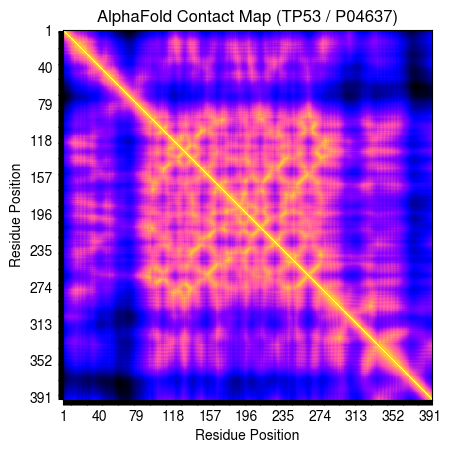

In [52]:
tp53_contact_map_out = cf.plot_contact_map(contact_map=distance_map_ref, 
                            title=f"AlphaFold Contact Map ({target_gene} / {uniprot_id})",  
                            bin_size=1,   
                            cmap="gnuplot2_r", 
                            pow=1/2, 
                            agg_func=np.nanmax)
contact_map_ref  = tp53_contact_map_out["data"]["contact_map"]
contact_map_ref_binned = tp53_contact_map_out["data"]["contact_map_binned"]
tp53_contact_map_out['fig'].savefig("manuscript/fig/tp53_contact_map.pdf", **utils.FIG_SAVE_KWARGS)

### Subfigure B

DYPD sensitization map (aligned) +  DYPD AlphaFold contact map (reference sequence).

Choose a threshold for the interaction strength and compute the contact enrichment at that specific threshold.  
Then plot the contact map and the sensitization map.

In [53]:
interaction_threshold = 0.05

top_interactions = ridge_df.loc[ridge_df["interaction_strength"] > interaction_threshold]    

ridge_enrichment_at_threshold = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[interaction_threshold],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

print()
print(f"Number of top interactions: {top_interactions.shape[0]}" + \
      f" ({top_interactions.shape[0] / ridge_df.shape[0]*100:.2f}% of all WT-Clinical variant pairs)")
print(f"Enrichment at threshold {interaction_threshold}: {ridge_enrichment_at_threshold['enrichment'].values[0]:.2f}x" )

100%|██████████| 1/1 [00:00<00:00, 27.78it/s]


Number of top interactions: 578 (8.20% of all WT-Clinical variant pairs)
Enrichment at threshold 0.05: 39.90x


In [54]:
vep_prot.loc[(vep_prot["site"].isin(top_interactions["site"].head(10)))].groupby("site")["VEP"].mean().sort_values(ascending=False)
# vep_prot.loc[vep_prot["site"]=="NP_009225.1:V1687I"]["VEP"].hist(bins=50)

Series([], Name: VEP, dtype: float64)

In [55]:
top_interactions.head(20)

,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT
2354,215S>R,NP_000537.3:213R>P,2.445649,2.445649,more benign,1,1.563857,213R>P,215,S,R,213,R,P
2355,215S>R,NP_000537.3:213R>Q,1.092954,1.092954,more benign,1,1.045444,213R>Q,215,S,R,213,R,Q
3015,273R>H,NP_000537.3:281D>N,0.857769,0.857769,more benign,1,0.926158,281D>N,273,R,H,281,D,N
1447,175R>C,NP_000537.3:179H>Y,0.846658,0.846658,more benign,1,0.920140,179H>Y,175,R,C,179,H,Y
3016,273R>H,NP_000537.3:281D>V,0.840008,0.840008,more benign,1,0.916519,281D>V,273,R,H,281,D,V
3017,273R>H,NP_000537.3:281D>Y,0.821178,0.821178,more benign,1,0.906189,281D>Y,273,R,H,281,D,Y
1695,202R>C,NP_000537.3:199G>V,0.788605,0.788605,more benign,1,0.888035,199G>V,202,R,C,199,G,V
3014,273R>H,NP_000537.3:281D>G,0.673420,0.673420,more benign,1,0.820622,281D>G,273,R,H,281,D,G
2347,215S>R,NP_000537.3:158R>S,0.645741,0.645741,more benign,1,0.803580,158R>S,215,S,R,158,R,S
1446,175R>C,NP_000537.3:179H>Q,0.610163,0.610163,more benign,1,0.781129,179H>Q,175,R,C,179,H,Q


Adding rectangles


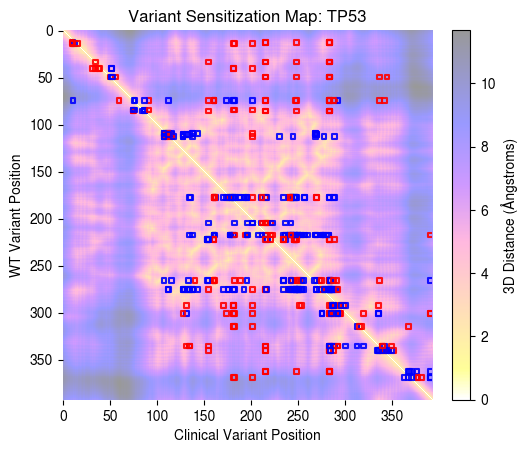

In [ ]:
fig2c = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=distance_map_ref,
    # contact_map_binned=(distance_map_ref_binned >= 8).astype(int),
    outlier_sig=top_interactions, 
    cmap=("gnuplot2_r", "gnuplot2_r"),
    height_width=5,
    pow2=1/2,
    heatmap_alpha=0.4,
     rectangles_alpha=.9,
     rectangles_linewidth=1.5,
    masking_percentile2=None,
    invert_mask=True,
    rectangles_cmap={"more pathogenic": "red", "more benign": "blue", "neutral": "grey"},
    title=f"Variant Sensitization Map: {target_gene}",
    show_plot=(False, True),
    # figsize=(10, 10)
)

fig2c["fig"]["subplot2"].savefig("manuscript/fig/tp53_sensitization_map.pdf", **utils.FIG_SAVE_KWARGS)

### Subfigure C

Contact enrichment: outlier detection method

In [62]:
ridge_enrichment = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    num_thresholds=50,
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

100%|██████████| 50/50 [00:01<00:00, 27.52it/s]


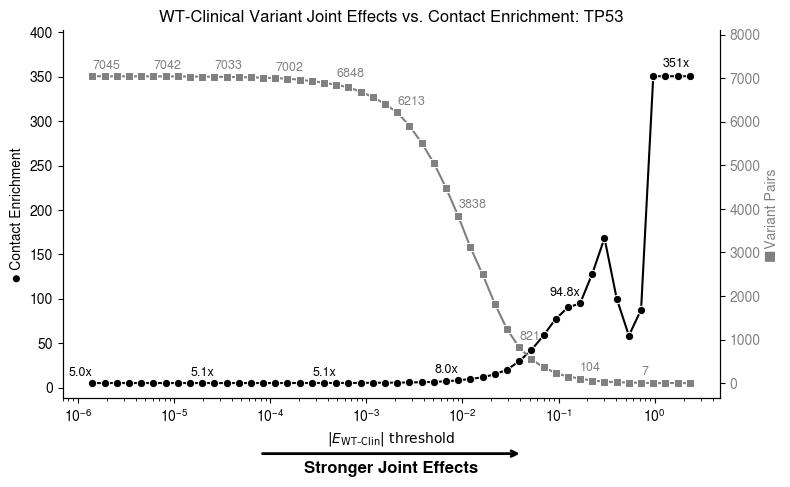

In [66]:
tp53_enrichment_vs_interactions_out = ab.plot_enrichment_vs_interactions(ridge_enrichment,   
                                           figsize=(8, 5),
                                           title=f"WT-Clinical Variant Joint Effects vs. Contact Enrichment: {target_gene}",
                                          log_x_axis=True, 
                                          x_axis_label=r"$|E_{\text{WT–Clin}}|\ \text{threshold}$",
                                          # log_y1_axis=True,
                                          # log_y2_axis=True,
                                          y1_first_label=False,
                                          y1_last_label=True,
                                          y2_first_label=True,
                                          y2_last_label=False, )
tp53_enrichment_vs_interactions_out["fig"].savefig("manuscript/fig/tp53_contact_map_enrichment.pdf", **utils.FIG_SAVE_KWARGS)

### Subfigure D

Mean interaction strength per clinical variant.

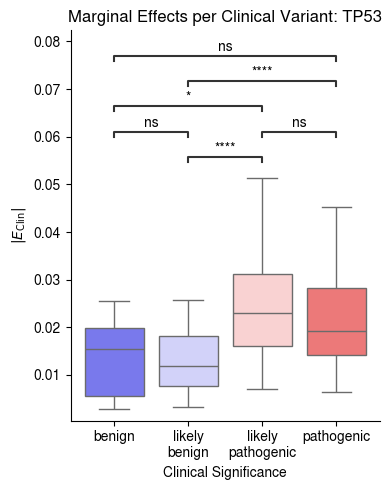

In [87]:
plot_clinsig_interaction_strength_out = ab.plot_clinsig_interaction_strength(
    ridge_df, vep_prot, 
    title=f"Marginal Effects per Clinical Variant: {target_gene}",
    xlabel="Clinical Significance",
    ylabel=r"$|E_{\text{Clin}}|$", 
    text_format="star",
    figsize=(4, 5),
)
plot_clinsig_interaction_strength_out["fig"].savefig("manuscript/fig/tp53_marginal_effects_per_clinical_variant.pdf", **utils.FIG_SAVE_KWARGS)

### Subfigure E

Interaction strength vs. Angstroms.

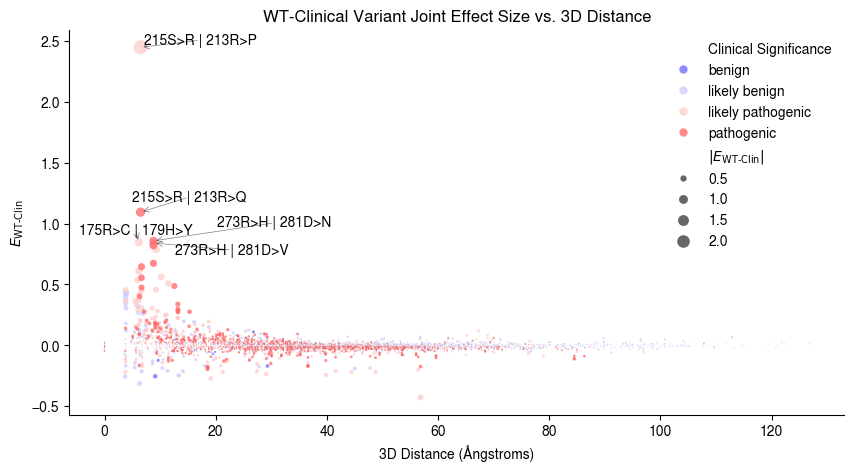

In [90]:
# Use a lambda to pass contact_map_ref as a closure variable, avoiding the error
ridge_df["position_distance"] = (ridge_df["wt_position"] - ridge_df["clinical_position"]).abs()
ridge_df["Angstroms"] = ridge_df.apply(lambda x: ab.get_contact_score(x, distance_map_ref), axis=1)
ridge_df["is_contact"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_binary_ref)==1, axis=1) 
ridge_df["clinical_variant_fmt"] = ridge_df["clinical_variant"].apply(
    lambda x: (
        f"{x[1:-1]}{x[0]}>{x[-1]}"
        if isinstance(x, str) and len(x) >= 3 and x[1:-1].isdigit()
        else x
    )
)
ridge_df['protein'] = ridge_df['site'].str.split(":").str[0]
ridge_df = utils.add_hgvsp_id(ridge_df)


tp53_wt_clinical_interaction_vs_angstroms = ab.plot_wt_clinical_interaction_vs_angstroms(
    ridge_df,
    vep_prot, 
      y_title=r"$E_{\text{WT-Clin}}$",
    N=5, style_var=None,
    adjust_text_kwargs={"min_arrow_len": 0}
)
# fig = utils.rasterize_figure(tp53_wt_clinical_interaction_vs_angstroms["fig"])
fig = tp53_wt_clinical_interaction_vs_angstroms["fig"]
fig.savefig("manuscript/fig/tp53_interaction_strength_vs_angstroms.pdf", **utils.FIG_SAVE_KWARGS)

Check the baseline enrichment of all interactions with the top WT variant.

In [91]:
#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1 ) 

contact_maps = cf.import_contact_maps(pdb_files,
                                        return_raw_distance_map=True
                                        )  

26 PDB files found


100%|██████████| 26/26 [00:01<00:00, 20.65it/s]


In [92]:
top_wt_variants = ridge_df.groupby("wt_variant")["interaction_strength"].mean().sort_values(ascending=False)
contact_maps_wt = {k:v for k,v in contact_maps.items() if top_wt_variants.index[0].replace(">","_") in k or k==cf.get_ref_key(contact_maps)}
top_wt_variants.head()

wt_variant
273R>H    0.057969
215S>R    0.055300
175R>C    0.047084
263N>D    0.029662
72P>R     0.026771
Name: interaction_strength, dtype: float64

In [93]:
ridge_enrichment_at_threshold_top1= ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df.loc[(ridge_df["wt_variant"]==top_wt_variants.index.tolist()[0])],
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[0,],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)
ridge_enrichment_at_threshold_top1

100%|██████████| 1/1 [00:00<00:00, 24.47it/s]


,observed_prob,expected_prob,binom_test,enrichment,interaction_threshold,n_interactions
0,0.012346,0.002852,"BinomTestResult(k=2, n=162, alternative='two-s...",4.328182,0,271


### Subfigure A
Personalized contact maps vs. REF contact map. 

,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT,position_distance,Angstroms,is_contact,clinical_variant_fmt,protein,wt_p.position,wt_p.REF,wt_p.ALT,wt_HGVSp
2354,215S>R,NP_000537.3:213R>P,2.445649,2.445649,more benign,1,1.563857,213R>P,215,S,R,213,R,P,2,6.484758,True,213R>P,NP_000537.3,215,S,R,NP_000537.3:p.Ser215Arg
2355,215S>R,NP_000537.3:213R>Q,1.092954,1.092954,more benign,1,1.045444,213R>Q,215,S,R,213,R,Q,2,6.484758,True,213R>Q,NP_000537.3,215,S,R,NP_000537.3:p.Ser215Arg
3015,273R>H,NP_000537.3:281D>N,0.857769,0.857769,more benign,1,0.926158,281D>N,273,R,H,281,D,N,8,8.795831,False,281D>N,NP_000537.3,273,R,H,NP_000537.3:p.Arg273His
1447,175R>C,NP_000537.3:179H>Y,0.846658,0.846658,more benign,1,0.920140,179H>Y,175,R,C,179,H,Y,4,6.169994,False,179H>Y,NP_000537.3,175,R,C,NP_000537.3:p.Arg175Cys
3016,273R>H,NP_000537.3:281D>V,0.840008,0.840008,more benign,1,0.916519,281D>V,273,R,H,281,D,V,8,8.795831,False,281D>V,NP_000537.3,273,R,H,NP_000537.3:p.Arg273His
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5861,47P>S,NP_000537.3:354Q>K,0.000009,-0.000009,more pathogenic,1,0.003026,354Q>K,47,P,S,354,Q,K,307,77.135674,False,354Q>K,NP_000537.3,47,P,S,NP_000537.3:p.Pro47Ser
1121,11E>Q,NP_000537.3:324D>E,0.000005,-0.000005,more pathogenic,1,0.002145,324D>E,11,E,Q,324,D,E,313,61.724640,False,324D>E,NP_000537.3,11,E,Q,NP_000537.3:p.Glu11Gln
3916,312T>S,NP_000537.3:265L>P,0.000003,-0.000003,more pathogenic,1,0.001582,265L>P,312,T,S,265,L,P,47,63.185787,False,265L>P,NP_000537.3,312,T,S,NP_000537.3:p.Thr312Ser
4056,312T>S,NP_000537.3:163Y>C,0.000002,0.000002,more benign,1,0.001515,163Y>C,312,T,S,163,Y,C,149,43.326866,False,163Y>C,NP_000537.3,312,T,S,NP_000537.3:p.Thr312Ser


/home/schilder/projects/VEP_protein/src/colabfold/colabfold.py:4168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


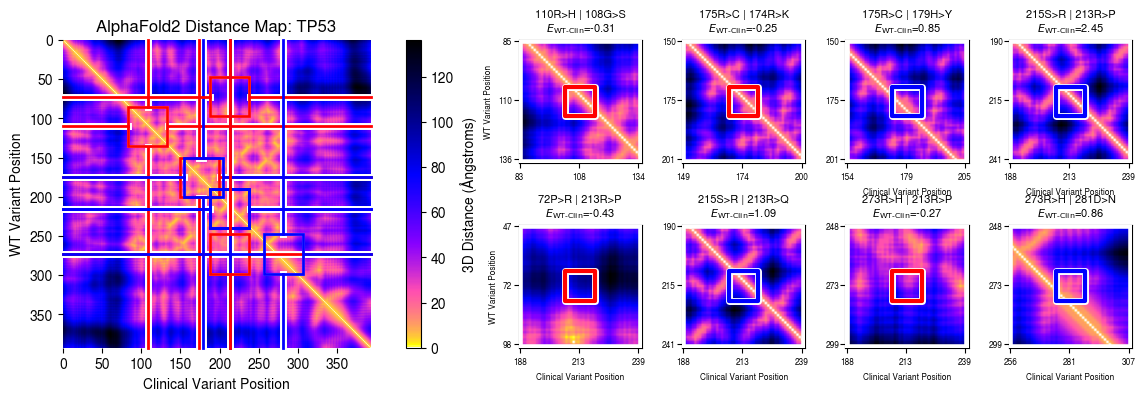

In [114]:
distance_map_zooms = cf.plot_contact_map_and_zooms(
    contact_maps_wt,
    ridge_df.groupby("outlier_type").head(4), 
    # highlight_colors="#50f96e",
    # palette="binary_r",
     zoom_highlight_marker_scale=1.5,           # NEW: scale factor for size of zoom highlight marker
    zoom_highlight_linewidth=3,                # NEW: color (non-border) marker linewidth in zoom
    zoom_highlight_white_linewidth=5,           # NEW: white border linewidth in zoom
    main_plot_above=False,
    zoom_hspace=0.5, 
    zoom_wspace=0.1, 
    main_padding_v=0.05,  # More vertical padding
    main_padding_h=0.3, 
    linewidth=2, 
    title=f"AlphaFold2 Distance Map: {target_gene}",
    
    max_highlights=8,
    highlight_size=50, 
    zoom_nrows = 2,
    zoom_ncols=None,
    zoom_subplot_size = 2,
    main_nrows = 2,
    main_ncols = 2,
    pow=1/2,
    zoom_show_xlabel=[False,False,True],
    zoom_show_ylabel=True,
    zoom_show_ticks=True,  # Enable tick labels
    zoom_tick_density=3,  # Show 5 ticks per axis
    white_border=True, 
    zoom_rect_white_outline=True, 
    
    save_path="manuscript/fig/tp53_distance_map_zooms.pdf"
)

### Figure F

Create population-weighted contact maps

For each superpopulation, weight the contacts maps according to their frequency in those populations.

In [115]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:00<00:00, 46.43it/s]


In [116]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

# Get a merged FASTA file
merged_fasta = hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                        tx_ids=[tx_id],
                        save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                        split_subdir="",
                        # force=True,
                        compress=False) 

# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps_binary = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps_binary, 
                                                     msa=msa) 


Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


...

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 26 haplotypes across 1 tx_ids.


Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Padding contact maps to MSA: 100%|██████████| 26/26 [00:00<00:00, 919.04it/s]


In [117]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )

freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
freq_df.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (7720, 16)
>> haplotype(s): 26
>> cohort(s): 3
>> cohort_sample(s): 3878
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
EAS    5
AFR    5
SAS    4
EUR    4
AMR    4
MID    1
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 88.46%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000269305:10V>I,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SAS,0.000992,1,SAS,1.0
1,"ENSP00000269305:11E>Q,72P>R",0.000000,0.0,0.0,0.001379,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,EAS,0.001379,1,EAS,2.0
2,ENSP00000269305:215S>R,0.000000,0.0,0.0,0.000000,0.000753,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,EUR,0.000753,1,EUR,1.0
3,ENSP00000269305:220Y>H,0.000418,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,0.000418,1,AFR,1.0
4,ENSP00000269305:263N>D,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SAS,0.000992,1,SAS,1.0


In [118]:
pop_contact_maps = cf.compute_population_specific_contact_maps(
    contact_maps=contact_maps,
    contact_maps_binary=contact_maps_binary,
    freq_df=freq_df, 
    superpopulation_specific_only=False,
    exclude_ref_from_weights=True,
    weight_binary_maps=True,
)
specific_maps = pop_contact_maps["specific_maps"]
specific_diff_maps = pop_contact_maps["specific_diff_maps"]
specific_binary_diff_maps = pop_contact_maps["specific_binary_diff_maps"]
specific_binary_diff_figs = pop_contact_maps["specific_binary_diff_figs"]

100%|██████████| 8/8 [00:01<00:00,  5.33it/s]


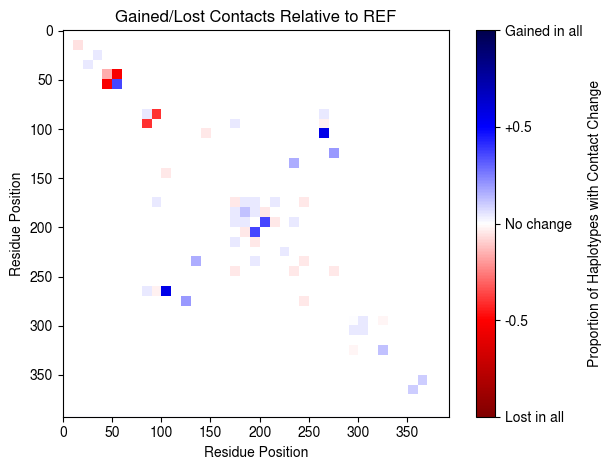

In [119]:
figS6g = cf.plot_contact_map_diff(contact_maps_binary,  
                                bin_size=10,
                                weights=None,
                                show_plot=True,
                                verbose=False)
figS6g["fig"].savefig("manuscript/fig/tp53_gained_lost_contact_proportions.pdf", **utils.FIG_SAVE_KWARGS)

### Subfigure G

In [120]:
%%capture

fig_superop_diff = cf.plot_superpopulation_contact_diff(
    specific_binary_diff_figs,
    specific_binary_diff_maps, 
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True,
    show_plot=False
)

array([[-1.11022302e-16, -1.11022302e-16, -1.11022302e-16, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.11022302e-16, -1.11022302e-16, -1.11022302e-16, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.11022302e-16, -1.11022302e-16, -1.11022302e-16, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.11022302e-16, -1.11022302e-16, -1.11022302e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.11022302e-16, -1.11022302e-16, -1.11022302e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.11022302e-16, -1.11022302e-16, -1.11022302e-16]],
      shape=(393, 393))

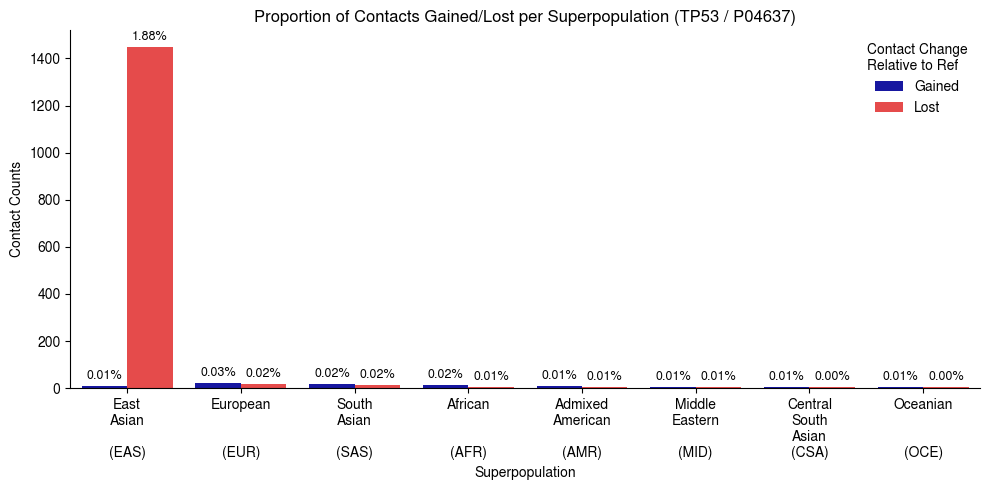

In [131]:
fig2h = cf.plot_contact_map_diff_barplot_grouped(
    bar_df=fig_superop_diff['data'],
    text_label_info=["percent"],
    group_by="superpopulation", 
    title=f"Proportion of Contacts Gained/Lost per Superpopulation ({target_gene} / {uniprot_id})",
    )
fig2h['fig'].savefig("manuscript/fig/tp53_superpopulation_contact_diff_barplot.pdf", **utils.FIG_SAVE_KWARGS)


In [159]:
analyze_target_group_contact_loss_out = cf.analyze_target_group_contact_loss( 
    fig_superop_diff['data'], target_group="EAS")


EAS lost contact %: 1.87853767
Other populations lost contact % (mean): 0.00964399
Fold-change (EAS/others): 194.79
EAS z-score (relative to others): 258.75
Outlier p-value (two-sided, normal): 2.23e-308
EAS lost contact % is a statistical outlier compared to the other superpopulations (p < 0.05).
EAS superpopulation has a higher percent of lost contacts compared to the mean of other superpopulations.


In [232]:
import numpy as np
import pandas as pd

arr = specific_binary_diff_maps['EAS']
x_idx, y_idx = np.meshgrid(np.arange(arr.shape[0]), np.arange(arr.shape[1]), indexing='ij')
df_all = pd.DataFrame({
    'x': x_idx.ravel(),
    'y': y_idx.ravel(),
    'proportion': arr.ravel()
})
df_nonzero = df_all[df_all['proportion'] != 0]
df_all


,x,y,proportion
0,0,0,-1.110223e-16
1,0,1,-1.110223e-16
2,0,2,-1.110223e-16
3,0,3,0.000000e+00
4,0,4,0.000000e+00
...,...,...,...
154444,392,388,0.000000e+00
154445,392,389,0.000000e+00
154446,392,390,-1.110223e-16
154447,392,391,-1.110223e-16


In [246]:
# Grab all x-y values, count frequency of each position, sort by frequency

from collections import Counter

# Flatten x and y positions together
all_positions = np.concatenate([df_nonzero['x'], df_nonzero['y']])

# Count how often each position appears
position_counts = Counter(all_positions)

# Convert to DataFrame, compute mean "value", and sort by count (descending)
mean_values = (
    pd.concat([
        df_all[['x', 'proportion']].rename(columns={'x': 'position'}),
        df_all[['y', 'proportion']].rename(columns={'y': 'position'})
    ])
    .groupby('position')['proportion'].mean()
)

position_counts_df = (
    pd.DataFrame(position_counts.items(), columns=['position', 'count'])
    .assign(proportion=lambda df: df['position'].map(mean_values))
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

position_counts_df

,position,count,proportion
0,108,36,-5.084991e-18
1,277,36,-5.084991e-18
2,245,36,-5.084991e-18
3,134,36,5.917510e-06
4,124,34,-4.802491e-18
...,...,...,...
388,388,10,-1.412497e-18
389,391,8,-1.129998e-18
390,1,8,-1.129998e-18
391,0,6,-8.474985e-19


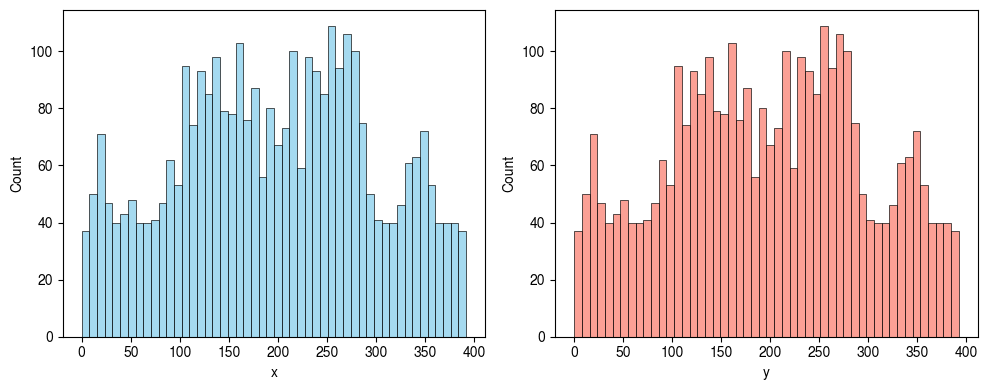

In [247]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df_nonzero['x'], bins=50, ax=axes[0], color='skyblue') 
sns.histplot(df_nonzero['y'], bins=50, ax=axes[1], color='salmon') 
plt.tight_layout()
plt.show()

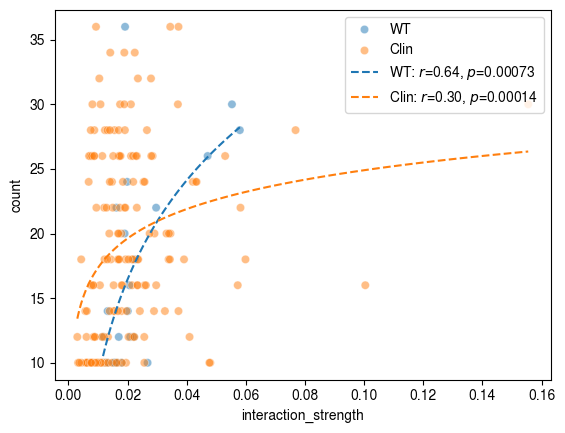

In [267]:
position_counts_df_sub = position_counts_df#.loc[position_counts_df["proportion"].abs() > 1e-16]

df_wt = (
    ridge_df.groupby("wt_position")["interaction_strength"].mean()
    .reset_index().rename(columns={"wt_position": "position"})
    .merge(position_counts_df_sub, on="position", how="inner")
)
df_wt["variant_type"] = "WT"

df_clin = (
    ridge_df.groupby("clinical_position")["interaction_strength"].mean()
    .reset_index().rename(columns={"clinical_position": "position"})
    .merge(position_counts_df_sub, on="position", how="inner")
)
df_clin["variant_type"] = "Clin"

df = pd.concat([df_wt, df_clin], ignore_index=True)

# Make scatterplot
x_var = "interaction_strength"
y_var = "count"
ax = sns.scatterplot(
    data=df,
    x=x_var,
    y=y_var,
    alpha=0.5,
    hue="variant_type",
    # size="count", 
)

# ax.set_xscale("log")
# ax.set_xscale("log")

# Add regression lines and display stats
import scipy.stats as stats

for type_name, color in zip(["WT", "Clin"], ["C0", "C1"]):
    subdf = df.loc[df["variant_type"] == type_name]
    # Linear regression (on log interaction_strength)
    # Filter nonzero & positive for log
    subdf_valid = subdf.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_var, y_var])
    subdf_valid = subdf_valid[subdf_valid[x_var] > 0]
    if len(subdf_valid) > 1:
        x = np.log10(subdf_valid[x_var])
        y = subdf_valid[y_var]

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        label = (
            f"{type_name}: $r$={r_value:.2f}, $p$={p_value:.2g}"
        )

        # Plot regression line
        x_vals = np.linspace(x.min(), x.max(), 100)
        y_vals = slope * x_vals + intercept
        ax.plot(10**x_vals, y_vals, label=label, color=sns.color_palette()[0 if type_name == "WT" else 1], linestyle="dashed")
       

ax.legend()

<Axes: xlabel='proportion_group', ylabel='count'>

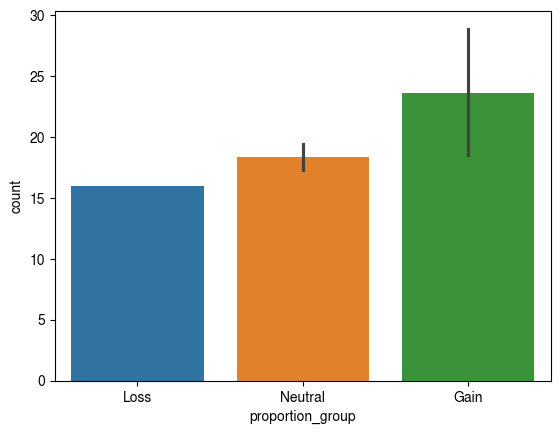

In [273]:
df["proportion_group"] = pd.cut(
    df["proportion"],
    bins=[-np.inf, -1e-12, 1e-12, np.inf],
    labels=["Loss", "Neutral", "Gain"]
)
sns.barplot(data=df, x="proportion_group", y="count", hue="proportion_group")